# Xora: smarter delivery planning for Waypoint Group

Waypoint Group delivers for three retail brands from two depots. Every evening a dispatcher drafts the next day's routes, and too often the plan is wrong: trucks reach stores after their windows close, festival weeks catch the fleet short, and on a bad day there are more orders than trucks. This notebook is our full answer, from the raw files to the decisions people make with it.

### Results at a glance

| Question | Waypoint today | Our approach | Result on data the models never saw |
|---|---|---|---|
| **Task 1.** How long will each delivery take? | published allowance table, off by 7.1 min a stop | LightGBM on cutoff-time features | **3.9 min** error a stop, **45% less** |
| **Task 1.** Will the truck arrive after the window closes? | slack on paper (log loss 0.287, AUC 0.86) | 1,000 replays of every route, blended with a direct classifier | **log loss 0.136, AUC 0.97**, calibrated |
| **Task 2A.** How much volume in the next 10 weeks? | same week last year | daily festival-aware models added up into ISO weeks | **5.2% error** on total, **3.6%** on chilled; **41 to 54% less error** than last year's pattern |
| **Task 2B.** Who gets served on a peak day? | dispatcher judgement | optimiser with a fixed, agreed order of priorities | **76 of 85 orders**, every repeat deferral served, chilled volume **within 0.2% of the proven maximum**, passes Waypoint's checker |
| **People.** What should each person do? | probabilities nobody reads | traffic lights, clock times and one-line reasons | the red stops are **21% of stops** but carry **over 80%** of expected late arrivals |

Part 11 recomputes every number in this table from the saved models and outputs.

### How this notebook is organised

It follows CRISP-DM, the standard industry process for data science projects. Every part starts with its purpose and ends with a short summary, so it can be read top to bottom or one part at a time.

| CRISP-DM phase | Part |
|---|---|
| Business understanding | 1. The problem and the solution at a glance |
| Data understanding | 2. Data understanding |
| Data preparation | 3. Data quality and cleaning; 4. Label construction; 5. Feature engineering |
| Modelling and evaluation | 6. Task 1: service time and late risk; 7. Task 2A: demand forecast; 8. Task 2B: peak-day allocation |
| Deployment | 9. The decision layer; 10. Deployment, impact and limits; 11. Reload the saved models and run inference |

**To run it:** follow the README to install the pinned requirements and unzip the data into `data/raw/`, then run all cells. A full run rebuilds every table, model and submission from the raw files and takes about an hour on a laptop, most of it in the Task 1 models and the Task 2B optimiser. Seeds are fixed, so results reproduce. The one exception is the last kilometre step of the Task 2B optimiser, which stops on a time limit and so can settle on a slightly different but equally valid route plan on a slower or faster machine.

In [1]:
import json
import subprocess
import sys
import warnings

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

from xora import allocation as al
from xora import checks as ck
from xora import decisions as dl
from xora import features as fe
from xora import forecast as fc
from xora.io import load_processed, load_raw, save_processed
from xora.paths import DATA_RAW, MODELS, REPO_ROOT, REPORTS, SUBMISSIONS, raw_file
from xora.plotting import apply_style, SERIES, INK, INK_SOFT
from xora.simulation import LGB_PARAMS, SEED, TRAVEL_FEATURES, DELAY_FEATURES, RouteSimulator, _fit_lgb
from xora.timeutils import hhmm_to_minutes

warnings.filterwarnings("ignore", category=UserWarning)
apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 110)

## Part 1. The problem and the solution at a glance

**The business.** Waypoint Group runs 60 vehicles from a distribution centre in Peliyagoda and a regional hub in Kandy, serving 120 outlets for three brands:
- **Fresh**, 80 supermarkets that must be stocked before they open at 8 AM, with chilled goods that only refrigerated trucks (reefers) can carry
- **Style**, 25 fashion stores, many in malls with fixed delivery windows
- **Tech**, 15 electronics stores with heavy, fragile, high-value orders

**Three questions, three decisions.**

| Task | Question | Decision it feeds | Who decides |
|---|---|---|---|
| 1 | How long will each stop take, and will the truck be late? | which routes to change before the trucks leave | dispatcher, driver |
| 2A | How much total and chilled volume will each depot and brand need over the next 10 weeks? | how many trucks and reefers to have ready, and when to service them | fleet manager |
| 2B | On a peak day with vehicles in the workshop, which orders ride on which truck, and which wait? | the day's allocation and what to tell each store | dispatcher |

**What made it hard, and how we handled it.**
- **Waiting is not working.** A truck that arrives before a store opens waits outside. Service time has to start at the later of arrival and window opening, or the labels are wrong (Part 4).
- **Lateness builds up along a route.** One slow stop delays every stop after it, so Task 1 replays whole routes instead of scoring stops one by one (Part 6).
- **Festivals move.** Vesak fell in ISO week 21, then 20, and is week 18 in 2026. Any method that copies last year's weeks puts the spike in the wrong place, so Task 2A forecasts days and adds them up into weeks (Part 7).
- **Some orders cannot ride at all.** One Task 2B order is bigger than any truck, and chilled demand is far above what the remaining reefers can carry, so the plan has to prove which deferrals are forced and price the ones that are choices (Part 8).
- **Nothing leaks from the future.** Every feature is something a planner knows at the 4 PM cutoff, and Part 5 proves it.

**The solution end to end.** The diagram is drawn from the pipeline itself and saved to `docs/figures/` for reuse.

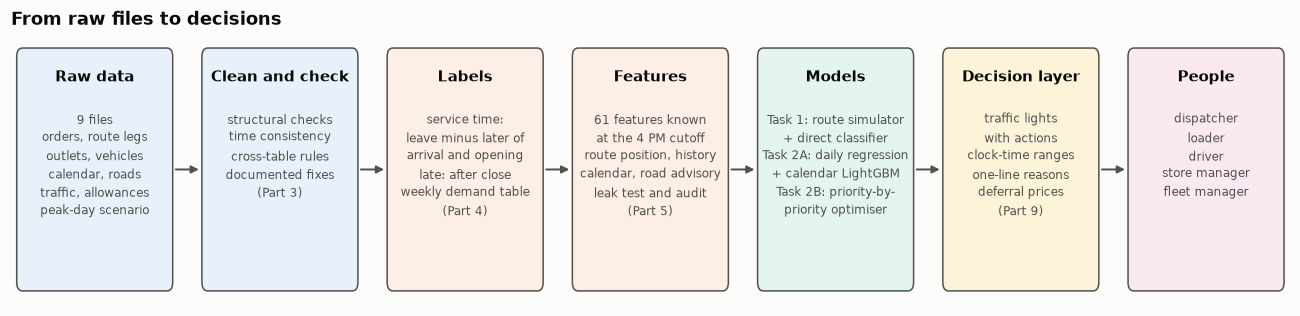

In [2]:
def box(ax, x, y, w, h, title, lines, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=color, edgecolor=INK_SOFT, linewidth=1))
    ax.text(x + w / 2, y + h - 0.18, title, ha="center", va="top", fontsize=10, fontweight="bold", color=INK)
    ax.text(x + w / 2, y + h - 0.55, "\n".join(lines), ha="center", va="top", fontsize=8, color=INK_SOFT, linespacing=1.5)

def arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="-|>", color=INK_SOFT, lw=1.3))

def flow(columns, height=2.2, figsize=(15, 3.2), title=None, loop=None):
    fig, ax = plt.subplots(figsize=figsize)
    w, gap = 2.15, 0.45
    for i, (head, items, color) in enumerate(columns):
        x = i * (w + gap)
        box(ax, x, 0, w, height, head, items, color)
        if i:
            arrow(ax, x - gap + 0.02, height / 2, x - 0.02, height / 2)
    bottom = -0.15
    if loop:
        # A feedback arrow under the boxes, from one column back to an earlier one
        src, dst, label = loop
        xs, xd = src * (w + gap) + w / 2, dst * (w + gap) + w / 2
        ax.annotate("", xy=(xd, -0.05), xytext=(xs, -0.05),
                    arrowprops=dict(arrowstyle="-|>", color=INK_SOFT, lw=1.3, connectionstyle="bar,fraction=-0.06"))
        ax.text((xs + xd) / 2, -0.5, label, ha="center", va="center", fontsize=8.5, color=INK_SOFT)
        bottom = -0.75
    ax.set_xlim(-0.1, len(columns) * (w + gap) - gap + 0.1)
    ax.set_ylim(bottom, height + 0.15)
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left")
    return fig

LIGHT = ["#e8f0fb", "#fdeee6", "#e3f5ee", "#fdf3d9", "#fbe9f1", "#e6f2e6"]
pipeline = flow([
    ("Raw data", ["9 files", "orders, route legs", "outlets, vehicles", "calendar, roads", "traffic, allowances", "peak-day scenario"], LIGHT[0]),
    ("Clean and check", ["structural checks", "time consistency", "cross-table rules", "documented fixes", "(Part 3)"], LIGHT[0]),
    ("Labels", ["service time:", "leave minus later of", "arrival and opening", "late: after close", "weekly demand table", "(Part 4)"], LIGHT[1]),
    ("Features", ["61 features known", "at the 4 PM cutoff", "route position, history", "calendar, road advisory", "leak test and audit", "(Part 5)"], LIGHT[1]),
    ("Models", ["Task 1: route simulator", "+ direct classifier", "Task 2A: daily regression", "+ calendar LightGBM", "Task 2B: priority-by-", "priority optimiser"], LIGHT[2]),
    ("Decision layer", ["traffic lights", "with actions", "clock-time ranges", "one-line reasons", "deferral prices", "(Part 9)"], LIGHT[3]),
    ("People", ["dispatcher", "loader", "driver", "store manager", "fleet manager"], LIGHT[4]),
], title="From raw files to decisions")
(REPO_ROOT / "docs" / "figures").mkdir(parents=True, exist_ok=True)
pipeline.savefig(REPO_ROOT / "docs" / "figures" / "architecture_pipeline.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 2. Data understanding

**Purpose:** get to know every file before changing anything. This part only reads and describes the data. Cleaning happens in Part 3, and labels are built in Part 4.

**Inputs:** the raw data files in `data/raw/`.

**Outputs:** none. The findings here shape the decisions in the later parts, and they are summarised at the end.

**Questions this part answers**
1. What is in each file, and how do the files connect?
2. What does the delivery network look like (outlets, vehicles, depots)?
3. How do orders and route legs relate, and what period do train and test cover?
4. How often are deliveries late, and what seems to drive it?
5. How does weekly demand move, especially around festivals?
6. How tight is the Task 2B peak day?

### 2.1 File inventory

The data zip has four folders. Here is every CSV with its size and shape.

In [3]:
inventory = []
for path in sorted(DATA_RAW.rglob("*.csv")):
    df = pd.read_csv(path)
    inventory.append({
        "folder": path.parent.name,
        "file": path.name,
        "rows": len(df),
        "columns": df.shape[1],
    })
pd.DataFrame(inventory)

,folder,file,rows,columns
0,General Data,calendar.csv,910,12
1,General Data,district_travel.csv,12,8
2,General Data,outlets.csv,120,9
3,General Data,road_conditions.csv,10920,3
4,General Data,service_allowance.csv,9,3
5,General Data,traffic_speed.csv,576,4
6,General Data,vehicles.csv,60,9
7,Submission Templates,submission_task1.csv,5014,3
8,Submission Templates,submission_task2a.csv,60,3
9,Submission Templates,submission_task2b.csv,85,6


In [4]:
orders = load_raw("deliveries_train.csv")
legs = load_raw("route_legs_train.csv")
orders_test = load_raw("task1_test_inputs.csv")
legs_test = load_raw("route_legs_test.csv")
outlets = load_raw("outlets.csv")
vehicles = load_raw("vehicles.csv")
calendar = load_raw("calendar.csv")
district_travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")
road = load_raw("road_conditions.csv")
traffic = load_raw("traffic_speed.csv")

**How the files connect**

- `deliveries_train.csv` has one row per order. Each dispatched order points to a route (`route_id`) and its position on that route (`seq_in_route`).
- `route_legs_train.csv` has one row per leg: a drive from the depot or the previous stop to the next outlet. It holds the actual times we need for labels.
- `outlets.csv`, `vehicles.csv`, `district_travel.csv` and `service_allowance.csv` describe the network and the current planning standards.
- `calendar.csv`, `road_conditions.csv` and `traffic_speed.csv` describe each day: paydays, festivals, monsoon, road disruption and traffic speed by hour.
- The test files mirror the train files but only carry planned times.

### 2.2 The delivery network

Three brands share one fleet. By design, Fresh delivers daily before 8 AM, Style weekly with seasonal peaks, and Tech as needed.

In [5]:
outlet_mix = outlets.pivot_table(index="brand", columns="depot", values="outlet_id", aggfunc="count", margins=True, margins_name="total")
outlet_mix

depot,Kandy,Peliyagoda,total
brand,,,
Fresh,31,49,80
Style,9,16,25
Tech,5,10,15
total,45,75,120


In [6]:
# Access constraints matter for both service time and Task 2B
pd.crosstab([outlets.brand, outlets.dock_type], outlets.parking_constraint)

parking_constraint  mall_dock  normal  van_only
brand dock_type                                
Fresh rear_dock             0      55         0
      street                0      14        11
Style mall_bay              9       0         0
      rear_dock             0       6         0
      street                0       9         1
Tech  mall_bay              3       0         0
      rear_dock             0       7         0
      street                0       4         1

In [7]:
fleet = vehicles.groupby(["depot", "type", "temp"]).agg(
    vehicles=("vehicle_id", "count"),
    volume_m3=("volume_cap_m3", "sum"),
    weight_kg=("weight_cap_kg", "sum"),
)
fleet

vehicles  volume_m3  weight_kg
depot      type  temp                                   
Kandy      truck ambient        13      362.0      66000
                 reefer          5      132.0      26990
           van   ambient         2       18.0       2400
                 reefer          2       14.0       2080
Peliyagoda truck ambient        27      788.0     145200
                 reefer          7      193.5      39140
           van   ambient         2       17.0       2300
                 reefer          2       14.0       2080

In [8]:
district_travel.merge(
    outlets.groupby("district").size().rename("outlets"), left_on="district", right_index=True
)[["district", "depot", "road_class", "outlets", "depot_to_district_km", "depot_to_district_freeflow_min", "inter_stop_freeflow_min"]]

,district,depot,road_class,outlets,depot_to_district_km,depot_to_district_freeflow_min,inter_stop_freeflow_min
0,Colombo,Peliyagoda,urban,24,12,24,8
1,Gampaha,Peliyagoda,suburban,15,28,37,9
2,Kalutara,Peliyagoda,suburban,10,48,64,12
3,Galle,Peliyagoda,highway,9,120,103,9
4,Matara,Peliyagoda,highway,6,160,137,10
5,Kurunegala,Peliyagoda,suburban,8,95,127,19
6,Puttalam,Peliyagoda,suburban,3,130,173,24
7,Kandy,Kandy,urban,20,8,16,6
8,Matale,Kandy,suburban,8,26,35,11
9,Nuwara Eliya,Kandy,hill,6,78,111,20


**What stands out**

- Fresh is two thirds of the outlets, so it will dominate both labels and demand.
- Only 16 of 60 vehicles can carry chilled goods, which hints that refrigeration is the scarce resource.
- Some districts are far from their depot (Puttalam is 173 free-flow minutes from Peliyagoda). Before 8 AM that leaves little room for more than one trip.

### 2.3 Orders and route legs

First, what period each set covers and what happened to each order.

In [9]:
period = pd.DataFrame({
    "first order": [orders.order_date.min(), orders_test.order_date.min()],
    "last order": [orders.order_date.max(), orders_test.order_date.max()],
    "orders": [len(orders), len(orders_test)],
    "route legs": [len(legs), len(legs_test)],
}, index=["train", "test"])
period

,first order,last order,orders,route legs
train,2024-01-01,2026-02-14,92307,91894
test,2026-02-16,2026-03-28,5014,5014


In [10]:
status = pd.concat({
    "train": orders.dispatch_status.value_counts(),
    "test": orders_test.dispatch_status.value_counts(),
}, axis=1).fillna(0).astype(int)
status

,train,test
dispatch_status,,
attempted,90351,4924
deferred,1543,90
not_run,413,0


In [11]:
pd.crosstab(orders.brand, orders.temp_requirement, margins=True)

temp_requirement,ambient,chilled,All
brand,,,
Fresh,52720,35135,87855
Style,2740,0,2740
Tech,1712,0,1712
All,57172,35135,92307


`attempted` orders went out on their order date. `deferred` orders were pushed to the next day. `not_run` orders were never dispatched, so they have no route. The test set has no `not_run` orders, which matters later for the Task 2A weekly totals.

Next, does every dispatched order have exactly one leg? We join on route and stop position.

In [12]:
dispatched = orders[orders.route_id.notna()].astype({"seq_in_route": int})
joined = dispatched.merge(
    legs, left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
    how="left", suffixes=("", "_leg"), indicator=True,
)
pd.Series({
    "dispatched orders": len(dispatched),
    "matched to a leg": (joined._merge == "both").sum(),
    "outlet agrees": (joined.outlet_id == joined.to_outlet).sum(),
    "leg date equals dispatch date": (joined.dispatch_date == joined.date).sum(),
})

dispatched orders                91894
matched to a leg                 91894
outlet agrees                    91894
leg date equals dispatch date    91894
dtype: int64

Every dispatched order, including deferred ones, matches exactly one leg, and the outlet and date agree in every case. So the leg is where each order's actual arrival and departure times live, and deferred orders can be used for training too.

Most Fresh outlets get two orders on the same day: one ambient and one chilled. They usually travel on different vehicles.

In [13]:
orders.groupby(["order_date", "outlet_id"]).size().value_counts().rename("outlet-days").rename_axis("orders per outlet per day")

orders per outlet per day
2    35135
1    22037
Name: outlet-days, dtype: int64

### 2.4 Lateness and timing: a first look

The formal labels come in Part 4. Here we use the raw times to see the shape of the problem. An arrival counts as late when it is after the outlet's `window_close_time`.

In [14]:
j = joined.copy()
for col in ["planned_arrival_time", "arrival_time", "window_close_time", "planned_depart_time", "actual_depart_time"]:
    j[col + "_min"] = hhmm_to_minutes(j[col])

j["late"] = j.arrival_time_min > j.window_close_time_min
j["arrival_vs_plan_min"] = j.arrival_time_min - j.planned_arrival_time_min

pd.Series({
    "late rate": j.late.mean().round(3),
    "median minutes later than planned": j.arrival_vs_plan_min.median(),
    "mean minutes later than planned": j.arrival_vs_plan_min.mean().round(1),
    "Fresh arriving after 08:00": (j.loc[j.brand == "Fresh", "arrival_time_min"] > 480).mean().round(3),
})

late rate                             0.196
median minutes later than planned    35.000
mean minutes later than planned      52.600
Fresh arriving after 08:00            0.193
dtype: float64

In [15]:
j.groupby("brand").late.mean().round(3).rename("late rate").to_frame()

,late rate
brand,
Fresh,0.204
Style,0.055
Tech,0.025


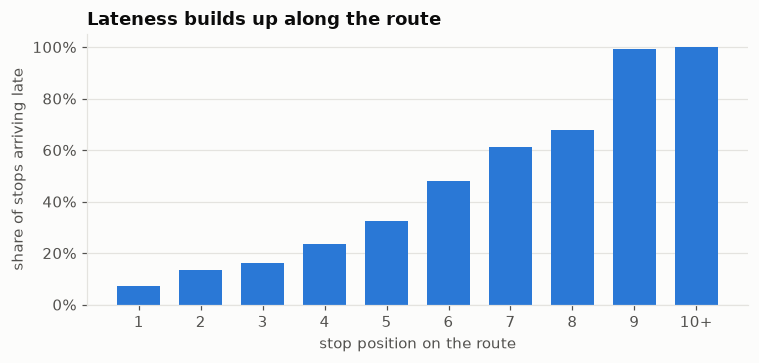

stop,1,2,3,4,5,6,7,8,9,10
mean,0.072,0.135,0.162,0.234,0.323,0.48,0.612,0.678,0.991,1.0
size,25198.000,21371.000,16222.000,12120.000,7464.000,5296.00,2527.000,1110.000,452.000,134.0


In [16]:
by_stop = j.assign(stop=(j.seq + 1).clip(upper=10)).groupby("stop").late.agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(by_stop.index, by_stop["mean"], color=SERIES[0], width=0.7)
ax.set_xticks(by_stop.index, [str(i) if i < 10 else "10+" for i in by_stop.index])
ax.set_xlabel("stop position on the route")
ax.set_ylabel("share of stops arriving late")
ax.set_title("Lateness builds up along the route")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()
by_stop.round(3).T

Lateness is cumulative: every delay at an earlier stop pushes back the later ones. This is the main reason Task 1 will simulate whole routes instead of scoring each stop in isolation.

What slows the trucks down? We compare actual with planned travel time, against monsoon and the daily road disruption index (100 means clear roads).

In [17]:
j = j.merge(road, on=["district", "date"], how="left")
j["travel_ratio"] = j.actual_travel_duration_min / j.planned_travel_duration_min.clip(lower=1)
j["disruption_band"] = pd.cut(j.disruption_index, [0, 60, 80, 95, 100], labels=["below 60", "60 to 80", "80 to 95", "95 to 100"])

pd.concat({
    "by monsoon": j.groupby("monsoon").travel_ratio.median(),
    "by road disruption": j.groupby("disruption_band", observed=True).travel_ratio.median(),
}).round(2).rename("median actual / planned travel").to_frame()

median actual / planned travel
by monsoon         0                                    1.36
                   1                                    1.73
by road disruption below 60                             2.95
                   60 to 80                             2.10
                   80 to 95                             1.60
                   95 to 100                            1.40

In [18]:
first_stop = j[j.seq == 0]
(first_stop.actual_depart_time_min - first_stop.planned_depart_time_min).describe().round(1).rename("depot departure delay (min)").to_frame().T

,count,mean,std,min,25%,50%,75%,max
depot departure delay (min),25198.0,7.7,6.0,0.0,4.0,6.0,10.0,63.0


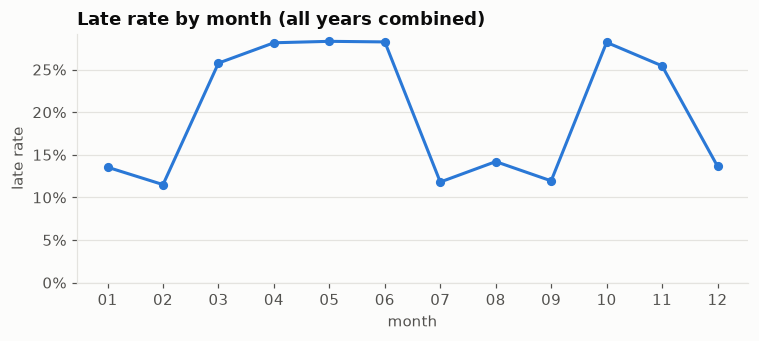

In [19]:
monthly = j.assign(month=j.date.str[5:7]).groupby("month").late.mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(monthly.index, monthly.values, color=SERIES[0], marker="o", markersize=5)
ax.set_ylim(0, None)
ax.set_xlabel("month")
ax.set_ylabel("late rate")
ax.set_title("Late rate by month (all years combined)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

**What stands out**

- Trucks arrive well after their planned times, so today's plans are optimistic.
- Travel slows sharply in the monsoon and on disrupted days, and the trucks leave the depot late too.
- Late rates roughly double in the monsoon and festival months.

`road_conditions.csv` covers the test period as well, so disruption can be used as a feature. Part 5 checks whether a planner would actually know it at the 4 PM cutoff.

### 2.5 Demand over time

Task 2A asks for weekly volume per depot and brand, using ISO weeks from the calendar and counting every order on its order date. The test inputs for Task 1 fill the gap between the end of training and the forecast weeks, so we stack both here.

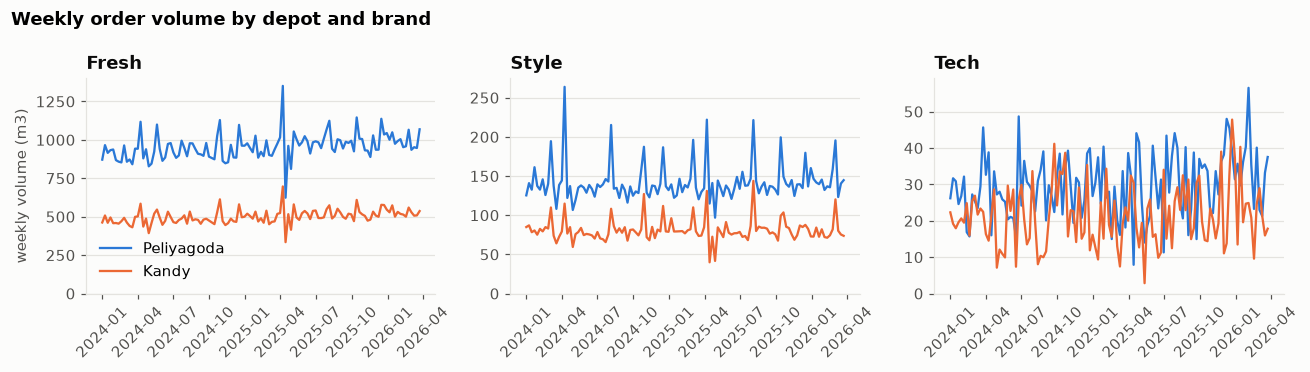

In [20]:
all_orders = pd.concat([orders.assign(source="train"), orders_test.assign(source="test")], ignore_index=True)
all_orders = all_orders.merge(calendar[["date", "iso_year", "iso_week"]], left_on="order_date", right_on="date")

weekly = all_orders.groupby(["depot", "brand", "iso_year", "iso_week"]).order_volume_m3.sum().reset_index()
weekly["week_start"] = pd.to_datetime(weekly.iso_year.astype(str) + "-W" + weekly.iso_week.astype(str).str.zfill(2) + "-1", format="%G-W%V-%u")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for ax, brand in zip(axes, ["Fresh", "Style", "Tech"]):
    for i, depot in enumerate(["Peliyagoda", "Kandy"]):
        s = weekly[(weekly.brand == brand) & (weekly.depot == depot)]
        ax.plot(s.week_start, s.order_volume_m3, color=SERIES[i], linewidth=1.5, label=depot)
    ax.set_title(brand)
    ax.set_ylim(0, None)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("weekly volume (m3)")
axes[0].legend()
fig.suptitle("Weekly order volume by depot and brand", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

The series are steady with sharp spikes and dips. The calendar shows that festivals sit behind most of them, and that festivals fall in different ISO weeks each year:

In [21]:
festival_weeks = (
    calendar.dropna(subset=["festival"])
    .groupby(["festival", "iso_year"]).iso_week.min()
    .unstack("iso_year")
)
festival_weeks.loc[["new_year", "vesak", "poson"]]

iso_year,2024,2025,2026
festival,,,
new_year,15.0,16.0,16.0
vesak,21.0,20.0,18.0
poson,25.0,24.0,22.0


In [22]:
pf = weekly[(weekly.depot == "Peliyagoda") & (weekly.brand == "Fresh")].pivot(index="iso_week", columns="iso_year", values="order_volume_m3")
operating_days = calendar.groupby(["iso_year", "iso_week"]).is_operating.sum().unstack("iso_year")
pd.concat({"Peliyagoda Fresh volume (m3)": pf.loc[13:24].round(0), "operating days": operating_days.loc[13:24]}, axis=1)

Peliyagoda Fresh volume (m3)                 operating days          
iso_year                         2024    2025    2026           2024 2025 2026
iso_week                                                                      
13                              943.0   975.0  1068.0            6.0  6.0  6.0
14                              942.0  1016.0     NaN            6.0  6.0  6.0
15                             1118.0  1351.0     NaN            5.0  6.0  6.0
16                              879.0   623.0     NaN            6.0  4.0  4.0
17                              939.0   961.0     NaN            6.0  6.0  6.0
18                              828.0   811.0     NaN            5.0  5.0  5.0
19                              845.0  1054.0     NaN            6.0  6.0  6.0
20                              923.0  1005.0     NaN            6.0  6.0  6.0
21                             1099.0   963.0     NaN            6.0  6.0  6.0
22                              941.0   984.0     NaN            6.0  6.0  6.0
23                              863.0  1024.0     NaN            6.0  6.0  6.0
24                              885.0   991.0     NaN            6.0  6.0  6.0

New Year falls in week 15 in 2024 but week 16 in 2025 and 2026. The week before a festival spikes and the festival week itself drops, partly because it has fewer operating days. So a "same week last year" forecast puts the peak in the wrong week. Part 7 handles this by forecasting days with calendar features and then adding them up into weeks.

### 2.6 The Task 2B peak day

Scenario S1 is a festival peak at Peliyagoda with some vehicles in the workshop. Here we only size the problem. Part 8 solves it.

In [23]:
s1 = load_raw("task2b_peak_day_scenarios.csv")
s1_fleet = load_raw("task2b_peak_day_fleet.csv").merge(vehicles, on="vehicle_id")

s1_fleet.groupby(["status", "type", "temp"]).agg(
    vehicles=("vehicle_id", "count"), volume_m3=("volume_cap_m3", "sum")
)

vehicles  volume_m3
status      type  temp                        
available   truck ambient        22      656.0
                  reefer          3       79.2
            van   ambient         2       17.0
                  reefer          1        7.0
in_workshop truck ambient         5      132.0
                  reefer          4      114.3
            van   reefer          1        7.0

In [24]:
available = s1_fleet[s1_fleet.status == "available"]
pd.DataFrame({
    "demand m3": s1.groupby("temp_requirement").order_volume_m3.sum(),
    "capacity per trip m3": [
        available.volume_cap_m3.sum(),                                  # ambient can go on any vehicle
        available.loc[available.temp == "reefer", "volume_cap_m3"].sum(),  # chilled needs a reefer
    ],
}, index=["ambient", "chilled"]).round(1)

,demand m3,capacity per trip m3
ambient,228.2,759.2
chilled,181.6,86.2


In [25]:
largest_vehicle = available.volume_cap_m3.max()
s1.loc[s1.order_volume_m3 > largest_vehicle, ["order_ref", "outlet_id", "brand", "district", "order_volume_m3"]].assign(largest_vehicle_m3=largest_vehicle)

,order_ref,outlet_id,brand,district,order_volume_m3,largest_vehicle_m3
78,S1-078,OUT070,Style,Kurunegala,40.66,38.0


In [26]:
s1[["deferred_yesterday", "days_since_last_served"]].value_counts().sort_index().rename("orders").to_frame()

orders
deferred_yesterday days_since_last_served        
0                  1                           47
                   2                           28
1                  2                            3
                   3                            2
                   5                            5

Ambient capacity is plentiful. Chilled is the bottleneck: chilled demand is roughly double the reefer space available per trip, and far districts can only get one trip before 8 AM. One Style order is bigger than any vehicle, so it cannot be served whatever we do. Some outlets were already deferred yesterday, so fairness has to be part of the policy.

### Part 2 summary

| Finding | Where it is used |
|---|---|
| Every dispatched order joins to exactly one route leg, including deferred ones | Part 4 builds labels from the legs |
| Lateness builds up along the route and depends on depot delay, monsoon and road disruption | Part 6 simulates whole routes |
| Today's planned arrival times are optimistic | The "before" baseline every model must beat |
| Festivals move between ISO weeks, and festival weeks have fewer operating days | Part 7 forecasts days, then sums to weeks |
| Test inputs have no `not_run` orders | Part 4 adjusts the weekly totals for the test weeks |
| On the peak day, refrigeration is the bottleneck and one order is larger than any vehicle | Part 8 |

## Part 3. Data quality and cleaning

**Purpose:** check every table against the rules it should follow, explain anything unusual, and save clean, typed tables for the rest of the project.

**Inputs:** the raw data files in `data/raw/`.

**Outputs** (in `data/processed/`):
- `orders.parquet`: train and test orders in one table, with a `split` column
- `legs.parquet`: train and test route legs in one table
- `outlets.parquet`, `vehicles.parquet`, `calendar.parquet`, `road_conditions.parquet`, `traffic_speed.parquet`, `district_travel.parquet`, `service_allowance.parquet`

**Approach:** every rule is written as a check that reports how many rows break it. One summary table shows everything at once, instead of the checks stopping at the first problem. Nothing is dropped silently: each fix or exclusion is stated with its reason.

In [27]:
orders = load_raw("deliveries_train.csv")
legs = load_raw("route_legs_train.csv")
orders_test = load_raw("task1_test_inputs.csv")
legs_test = load_raw("route_legs_test.csv")
outlets = load_raw("outlets.csv")
vehicles = load_raw("vehicles.csv")
calendar = load_raw("calendar.csv")
road = load_raw("road_conditions.csv")
traffic = load_raw("traffic_speed.csv")
district_travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")

### 3.1 Structural checks

Keys must be unique, categories must take only their documented values, and quantities must be positive.

In [28]:
BRANDS = {"Fresh", "Style", "Tech"}
DEPOTS = {"Peliyagoda", "Kandy"}

rows = []
for name, df in [("orders train", orders), ("orders test", orders_test)]:
    rows += [
        ck.unique_key(df, ["delivery_id"], name),
        ck.allowed_values(df, "brand", BRANDS, name),
        ck.allowed_values(df, "depot", DEPOTS, name),
        ck.allowed_values(df, "temp_requirement", {"chilled", "ambient"}, name),
        ck.allowed_values(df, "dispatch_status", {"attempted", "deferred", "not_run"}, name),
        ck.check(f"{name}: units, weight and volume are positive",
                 (df[["order_units", "order_weight_kg", "order_volume_m3"]] <= 0).any(axis=1).sum(), len(df)),
    ]
for name, df in [("legs train", legs), ("legs test", legs_test)]:
    rows += [
        ck.unique_key(df, ["leg_id"], name),
        ck.unique_key(df, ["route_id", "seq"], name),
        ck.in_range(df, "dow", 0, 5, name),
        ck.in_range(df, "monsoon", 0, 1, name),
        ck.check(f"{name}: distance is positive", (df.distance_km <= 0).sum(), len(df)),
    ]
rows += [
    ck.unique_key(outlets, ["outlet_id"], "outlets"),
    ck.unique_key(vehicles, ["vehicle_id"], "vehicles"),
    ck.unique_key(calendar, ["date"], "calendar"),
    ck.unique_key(road, ["district", "date"], "road conditions"),
    ck.check("train and test share no delivery_id", len(set(orders.delivery_id) & set(orders_test.delivery_id)), len(orders_test)),
    ck.check("test and train share no route_id", legs_test.route_id.isin(legs.route_id).sum(), len(legs_test)),
]
ck.report(rows)

,check,passed,failing_rows,total_rows,note
0,orders train: delivery_id is unique,True,0,92307,
1,"orders train: brand in ['Fresh', 'Style', 'Tech']",True,0,92307,
2,"orders train: depot in ['Kandy', 'Peliyagoda']",True,0,92307,
3,"orders train: temp_requirement in ['ambient', 'chilled']",True,0,92307,
4,"orders train: dispatch_status in ['attempted', 'deferred', 'not_run']",True,0,92307,
5,"orders train: units, weight and volume are positive",True,0,92307,
6,orders test: delivery_id is unique,True,0,5014,
7,"orders test: brand in ['Fresh', 'Style', 'Tech']",True,0,5014,
8,"orders test: depot in ['Kandy', 'Peliyagoda']",True,0,5014,
9,"orders test: temp_requirement in ['ambient', 'chilled']",True,0,5014,


Every structural check passes. Day of week never reaches 6 because Waypoint does not deliver on Sundays.

### 3.2 Blanks and cross-table consistency

Orders repeat attributes that also live in the reference tables (an outlet's brand and window, a vehicle's type). If the copies disagreed we would have to pick one, so we check they match.

In [29]:
orders.isna().sum().loc[lambda s: s > 0].rename("blank values").to_frame().assign(
    not_run_orders=(orders.dispatch_status == "not_run").sum()
)

,blank values,not_run_orders
dispatch_date,413,413
route_id,413,413
seq_in_route,413,413
vehicle_id,413,413
vehicle_type,413,413
vehicle_temp,413,413
planned_arrival_time,413,413


The only blanks are the route fields of the 413 `not_run` orders. These orders were never dispatched, so there is nothing to fill. They stay in the data because Task 2A must count every order, but they cannot be used for Task 1 labels.

In [30]:
both = pd.concat([orders, orders_test], ignore_index=True)

with_outlet = both.merge(outlets, on="outlet_id", suffixes=("", "_ref"))
with_vehicle = both.dropna(subset=["vehicle_id"]).merge(vehicles, on="vehicle_id", suffixes=("", "_ref"))

rows = [
    ck.check(f"order {col} matches outlets.csv", (with_outlet[col] != with_outlet[col + "_ref"]).sum(), len(with_outlet))
    for col in ["brand", "district", "depot", "window_open_time", "window_close_time"]
]
rows += [
    ck.check("order vehicle_type matches vehicles.csv", (with_vehicle.vehicle_type != with_vehicle.type).sum(), len(with_vehicle)),
    ck.check("order vehicle_temp matches vehicles.csv", (with_vehicle.vehicle_temp != with_vehicle.temp).sum(), len(with_vehicle)),
    ck.check("vehicle serves its own depot", (with_vehicle.depot != with_vehicle.depot_ref).sum(), len(with_vehicle)),
    ck.check("chilled orders ride on reefers", ((both.temp_requirement == "chilled") & (both.vehicle_temp == "ambient")).sum(), len(both)),
    ck.check("van-only outlets get vans",
             ((with_outlet.parking_constraint == "van_only") & (with_outlet.vehicle_type == "truck")).sum(), len(with_outlet)),
]
mall = outlets[outlets.mall_window.notna()]
rows.append(ck.check("mall window equals the outlet window", (mall.mall_window != mall.window_open_time + "-" + mall.window_close_time).sum(), len(mall)))
rows.append(ck.check("orders fall on operating days",
                     both.merge(calendar, left_on="order_date", right_on="date").is_operating.eq(0).sum(), len(both)))
ck.report(rows)

,check,passed,failing_rows,total_rows,note
0,order brand matches outlets.csv,True,0,97321,
1,order district matches outlets.csv,True,0,97321,
2,order depot matches outlets.csv,True,0,97321,
3,order window_open_time matches outlets.csv,True,0,97321,
4,order window_close_time matches outlets.csv,True,0,97321,
5,order vehicle_type matches vehicles.csv,True,0,96908,
6,order vehicle_temp matches vehicles.csv,True,0,96908,
7,vehicle serves its own depot,True,0,96908,
8,chilled orders ride on reefers,True,0,97321,
9,van-only outlets get vans,True,0,97321,


The copies agree everywhere, and the historical plans respected the operating rules (reefers for chilled, vans for van-only outlets, own depot). For mall outlets, the outlet window already equals the mall window, so the label code needs only one window.

### 3.3 Time consistency on the route legs

Each leg should follow the same logic: leave the previous point, drive, arrive, unload, leave. If these times hang together, we can trust labels built from them.

In [31]:
TIME_COLS = ["planned_depart_time", "planned_arrival_time", "actual_depart_time", "arrival_time", "leave_outlet_time"]
for col in TIME_COLS:
    legs[col + "_min"] = hhmm_to_minutes(legs[col])

legs = legs.sort_values(["route_id", "seq"]).reset_index(drop=True)
by_route = legs.groupby("route_id")
next_depart = by_route.actual_depart_time_min.shift(-1)
prev_outlet = by_route.to_outlet.shift()
gap = legs.arrival_time_min - (legs.actual_depart_time_min + legs.actual_travel_duration_min)

rows = [
    ck.check("routes start at seq 0 from the depot", (legs.loc[legs.seq == 0, "from_point"] != "DEPOT").sum(), (legs.seq == 0).sum()),
    ck.check("each leg starts where the last one ended", (legs.from_point[legs.seq > 0] != prev_outlet[legs.seq > 0]).sum(), (legs.seq > 0).sum()),
    ck.check("one vehicle, date, brand and district per route",
             (by_route[["vehicle_id", "date", "brand", "district"]].nunique() > 1).any(axis=1).sum(), legs.route_id.nunique()),
    ck.check("planned arrival = planned departure + planned travel",
             (legs.planned_arrival_time_min != legs.planned_depart_time_min + legs.planned_travel_duration_min).sum(), len(legs)),
    ck.check("actual arrival = actual departure + travel, within 1 minute", (gap.abs() > 1).sum(), len(legs),
             "differences of exactly 1 minute come from rounding to HH:MM"),
    ck.check("vehicle leaves after it arrives", (legs.leave_outlet_time_min < legs.arrival_time_min).sum(), len(legs)),
    ck.check("next leg departs exactly when the vehicle leaves", (next_depart.notna() & (next_depart != legs.leave_outlet_time_min)).sum(), next_depart.notna().sum()),
    ck.check("all times fall within the same day", (legs[[c + "_min" for c in TIME_COLS]] >= 24 * 60).any(axis=1).sum(), len(legs)),
]
ck.report(rows)

,check,passed,failing_rows,total_rows,note
0,routes start at seq 0 from the depot,True,0,25198,
1,each leg starts where the last one ended,True,0,66696,
2,"one vehicle, date, brand and district per route",True,0,25198,
3,planned arrival = planned departure + planned travel,True,0,91894,
4,"actual arrival = actual departure + travel, within 1 minute",True,0,91894,differences of exactly 1 minute come from rounding to HH:MM
5,vehicle leaves after it arrives,True,0,91894,
6,next leg departs exactly when the vehicle leaves,True,0,66696,
7,all times fall within the same day,True,0,91894,


In [32]:
gap.value_counts().sort_index().rename("legs").rename_axis("arrival minus (departure + travel), minutes").to_frame().T

"arrival minus (departure + travel), minutes",-1.0,0.0,1.0
legs,11518,68820,11556


Every rule holds. The only wrinkle is rounding: times are stored to the minute, so in about a quarter of legs the arrival is one minute off departure plus travel. This means every label we build carries roughly one minute of noise, which is worth remembering when reading model errors.

### 3.4 Things that look odd but are kept

#### 3.4.1 Back-to-back legs to the same outlet

Some routes visit an outlet and then drive "to" the same outlet again.

In [33]:
same_outlet = legs[legs.from_point == legs.to_outlet]
same_outlet_orders = orders.merge(same_outlet[["route_id", "seq"]], left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"])

pd.Series({
    "train legs": len(same_outlet),
    "test legs": (legs_test.from_point == legs_test.to_outlet).sum(),
    "median distance (km)": same_outlet.distance_km.median(),
    "median planned travel (min)": same_outlet.planned_travel_duration_min.median(),
    "share that are chilled orders": (same_outlet_orders.temp_requirement == "chilled").mean().round(3),
})

train legs                       621.00
test legs                         33.00
median distance (km)               4.10
median planned travel (min)        8.00
share that are chilled orders      0.99
dtype: float64

These are almost always the outlet's second (chilled) order on the same reefer. The data still records a few kilometres of travel between them, which cannot happen physically. We keep them as they are, because the test set has the same pattern (33 legs) and the planned times were built the same way. A model trained on the data as recorded will treat them consistently.

#### 3.4.2 Very long stops

A few stops take far longer than usual.

In [34]:
dwell = legs.leave_outlet_time_min - legs.arrival_time_min
legs_brand = legs.brand
dwell.groupby(legs_brand).quantile([0.5, 0.99, 0.999]).unstack().round(0).rename(columns=lambda q: f"p{q * 100:g}")

,p50,p99,p99.9
brand,,,
Fresh,15.0,62.0,100.0
Style,47.0,168.0,268.0
Tech,52.0,195.0,341.0


Long stops are real events (a delayed unload or a queue at a mall bay), not entry errors: every time on those legs is consistent with the rules above. Removing them would teach the model that delays never happen. We keep them in the labels and will use a loss in Part 6 that is not dominated by a handful of extreme values.

#### 3.4.3 Test orders without a `not_run` status

The training data has 413 `not_run` orders (0.45%), spread over 119 days at about 2.5% of each day's orders. The test file has none, most likely because only dispatched orders have outcomes to predict. Part 4 estimates their volume when building the weekly table for Task 2A.

In [35]:
not_run = orders[orders.dispatch_status == "not_run"]
pd.DataFrame({
    "orders": not_run.groupby(["brand", "temp_requirement"]).size(),
    "volume m3": not_run.groupby(["brand", "temp_requirement"]).order_volume_m3.sum().round(1),
})

orders  volume m3
brand temp_requirement                   
Fresh ambient                5       10.4
      chilled              393      643.2
Style ambient                7      120.0
Tech  ambient                8       60.9

### 3.5 Build and save the clean tables

The clean tables keep every original column and add:
- parsed dates
- every clock time also as minutes after midnight (`*_min`), which is what the models need
- a `split` column (`train` or `test`) so train and test share one schema

In [36]:
def add_minutes(df: pd.DataFrame, cols) -> pd.DataFrame:
    return df.assign(**{c + "_min": hhmm_to_minutes(df[c]) for c in cols if c in df})


orders_clean = (
    pd.concat([orders.assign(split="train"), orders_test.assign(split="test")], ignore_index=True)
    .pipe(add_minutes, ["planned_arrival_time", "window_open_time", "window_close_time"])
    .assign(
        order_date=lambda d: pd.to_datetime(d.order_date),
        dispatch_date=lambda d: pd.to_datetime(d.dispatch_date),
        seq_in_route=lambda d: d.seq_in_route.astype("Int64"),
    )
)

legs_clean = (
    pd.concat([load_raw("route_legs_train.csv").assign(split="train"), legs_test.assign(split="test")], ignore_index=True)
    .pipe(add_minutes, TIME_COLS)
    .assign(date=lambda d: pd.to_datetime(d.date))
    .sort_values(["split", "route_id", "seq"], ignore_index=True)
)

outlets_clean = outlets.pipe(add_minutes, ["window_open_time", "window_close_time"])
calendar_clean = calendar.assign(date=pd.to_datetime(calendar.date), festival=calendar.festival.fillna("none"))
road_clean = road.assign(date=pd.to_datetime(road.date))

orders_clean.head(3)

,delivery_id,order_date,dispatch_date,dispatch_status,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,route_id,seq_in_route,vehicle_id,vehicle_type,vehicle_temp,planned_arrival_time,window_open_time,window_close_time,split,planned_arrival_time_min,window_open_time_min,window_close_time_min
0,ORD0000001,2024-01-01,2024-01-01,attempted,OUT001,Fresh,Colombo,Peliyagoda,ambient,8,71.1,0.402,R000015,0,VEH037,van,ambient,05:00,05:00,07:30,train,300.0,300.0,450.0
1,ORD0000002,2024-01-01,2024-01-01,attempted,OUT002,Fresh,Colombo,Peliyagoda,ambient,15,101.0,0.564,R000015,2,VEH037,van,ambient,05:49,05:30,08:00,train,349.0,330.0,480.0
2,ORD0000003,2024-01-01,2024-01-01,attempted,OUT003,Fresh,Colombo,Peliyagoda,ambient,15,91.2,0.552,R000015,1,VEH037,van,ambient,05:25,05:00,07:30,train,325.0,300.0,450.0


In [37]:
tables = {
    "orders": orders_clean,
    "legs": legs_clean,
    "outlets": outlets_clean,
    "vehicles": vehicles,
    "calendar": calendar_clean,
    "road_conditions": road_clean,
    "traffic_speed": traffic,
    "district_travel": district_travel,
    "service_allowance": allowance,
}
for name, df in tables.items():
    save_processed(df, name)

pd.DataFrame({name: df.shape for name, df in tables.items()}, index=["rows", "columns"]).T

,rows,columns
orders,97321,24
legs,96908,28
outlets,120,11
vehicles,60,9
calendar,910,12
road_conditions,10920,3
traffic_speed,576,4
district_travel,12,8
service_allowance,9,3


### Part 3 summary

- Every structural, cross-table and timing rule passes on both train and test.
- Blanks only occur where they should (route fields of `not_run` orders).
- Three quirks are documented and kept on purpose: one-minute rounding noise, back-to-back legs to the same outlet, and rare long stops.
- One gap affects Task 2A: test inputs have no `not_run` orders. Part 4 adjusts for it.

Next: Part 4 builds the labels from these clean tables.

## Part 4. Label construction

**Purpose:** build the targets the models will learn from. Neither Task 1 target is given directly, so we derive them from the route legs. Task 2A also needs a weekly demand table built to Waypoint's counting rules.

**Inputs:** clean tables from Part 3 (`data/processed/`).

**Outputs** (in `data/processed/`):
- `stops.parquet`: one row per dispatched order (train and test) joined to its route leg, with the two Task 1 labels filled in for train
- `weekly_demand.parquet`: weekly total and chilled volume per depot and brand, ready for Task 2A

**The labels in one line each**
- `service_min` = time the vehicle leaves the outlet minus the later of its arrival and the window opening
- `late` = 1 if the vehicle arrives after the window closes, else 0

In [38]:
orders = load_processed("orders")
legs = load_processed("legs")
outlets = load_processed("outlets")
calendar = load_processed("calendar")
allowance = load_processed("service_allowance")

### 4.1 One row per delivered order

Part 2 showed that every dispatched order, deferred ones included, has exactly one route leg. We join on route and stop position, and keep only the leg columns the labels and later features need.

In [39]:
LEG_COLS = [
    "route_id", "seq", "leg_id", "date", "from_point", "distance_km", "dow", "monsoon",
    "planned_depart_time_min", "planned_travel_duration_min", "planned_arrival_time_min",
    "actual_depart_time_min", "actual_travel_duration_min", "arrival_time_min", "leave_outlet_time_min",
]

dispatched = orders[orders.route_id.notna()]
stops = dispatched.merge(
    legs[LEG_COLS], left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
    how="left", validate="one_to_one",
).merge(outlets[["outlet_id", "dock_type", "parking_constraint"]], on="outlet_id", how="left", validate="many_to_one")

stops.groupby("split").size().rename("stops").to_frame()

,stops
split,
test,5014
train,91894


`validate="one_to_one"` makes pandas raise an error if any order matched more than one leg, so the join is checked by construction. The `not_run` orders drop out here because they never had a route. They come back in section 4.5 for the demand table.

### 4.2 Service time label

**Why not simply leave time minus arrival time?** Waypoint's rules say outlets receive goods only within their window and early arrivals wait until it opens. Time spent waiting outside a closed outlet is not handling time. So service starts at whichever comes later: the arrival or the window opening.

```
service_start = max(arrival_time, window_open_time)
service_min   = leave_outlet_time - service_start
wait_min      = service_start - arrival_time      (0 when the vehicle arrives inside the window)
```

In [40]:
train = stops.split == "train"

service_start = np.maximum(stops.arrival_time_min, stops.window_open_time_min)
stops["wait_min"] = (service_start - stops.arrival_time_min).where(train)
stops["service_min"] = (stops.leave_outlet_time_min - service_start).where(train)
stops["dwell_min"] = (stops.leave_outlet_time_min - stops.arrival_time_min).where(train)

stops.loc[train, ["dwell_min", "wait_min", "service_min"]].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
dwell_min,91894.0,19.9,15.7,2.0,11.0,16.0,23.0,428.0
wait_min,91894.0,0.9,5.7,0.0,0.0,0.0,0.0,132.0
service_min,91894.0,19.0,14.9,2.0,11.0,15.0,22.0,428.0


In [41]:
waited = stops.loc[train & (stops.wait_min > 0)]
pd.Series({
    "stops that waited for the window": len(waited),
    "share of all stops": round(len(waited) / train.sum(), 3),
    "median wait when waiting (min)": waited.wait_min.median(),
    "share of waits on the first stop": round((waited.seq == 0).mean(), 3),
})

stops that waited for the window    4023.000
share of all stops                     0.044
median wait when waiting (min)        14.000
share of waits on the first stop       0.730
dtype: float64

Waiting is rare overall but concentrated on first stops, where a truck that left the depot early reaches an outlet before it opens. Using leave minus arrival would have inflated exactly those labels and taught the model that first stops are slow.

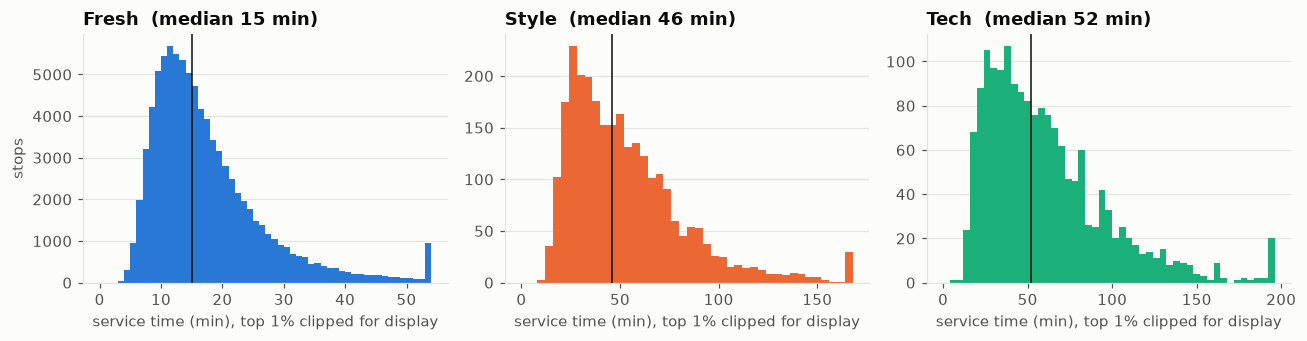

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, brand, color in zip(axes, ["Fresh", "Style", "Tech"], SERIES):
    s = stops.loc[train & (stops.brand == brand), "service_min"]
    cap = s.quantile(0.99)
    width = 1 if brand == "Fresh" else 4  # times are whole minutes, so bins must be too
    ax.hist(s.clip(upper=cap), bins=np.arange(0, cap + width, width), color=color)
    ax.axvline(s.median(), color="#0b0b0b", linewidth=1)
    ax.set_title(f"{brand}  (median {s.median():.0f} min)")
    ax.set_xlabel("service time (min), top 1% clipped for display")
axes[0].set_ylabel("stops")
plt.tight_layout()
plt.show()

In [43]:
stops.loc[train].pivot_table(index="brand", columns="dock_type", values="service_min", aggfunc="median")

dock_type,mall_bay,rear_dock,street
brand,,,
Fresh,NaN,15.0,14.0
Style,61.0,30.0,45.0
Tech,74.0,35.0,67.0


Service time differs a lot by brand and by how goods come off the truck: rear docks are quickest, and mall bays are slowest for Style and Tech. The distributions are right-skewed, with a long tail of slow stops. Those are kept, as explained in Part 3.

### 4.3 Late label

Waypoint defines late as arriving after `window_close_time`. Late deliveries are still made, so this label is about arrival only, not about whether the order was delivered.

```
late = 1 if arrival_time > window_close_time else 0
```

Arriving exactly at closing time counts as on time, because the operating rules say "after".

In [44]:
stops["late"] = (stops.arrival_time_min > stops.window_close_time_min).astype("Int8").where(train)
stops["late_by_min"] = (stops.arrival_time_min - stops.window_close_time_min).clip(lower=0).where(train)

pd.Series({
    "late rate": stops.loc[train, "late"].mean().round(3),
    "arrivals exactly at closing time (counted on time)": int((stops.arrival_time_min == stops.window_close_time_min)[train].sum()),
    "median minutes late, when late": stops.loc[train & (stops.late == 1), "late_by_min"].median(),
})

late rate                                               0.196
arrivals exactly at closing time (counted on time)    279.000
median minutes late, when late                         48.000
dtype: float64

In [45]:
stops.loc[train].groupby(["brand", "depot"]).late.agg(late_rate="mean", stops="size").round(3)

late_rate  stops
brand depot                       
Fresh Kandy           0.202  34039
      Peliyagoda      0.205  53418
Style Kandy           0.035    977
      Peliyagoda      0.066   1756
Tech  Kandy           0.064    593
      Peliyagoda      0.004   1111

About one stop in five arrives late, mostly Fresh, where the window closes around 8 AM and routes are long. Classes are imbalanced but not extreme, so a plain probability model with good calibration is appropriate. No resampling is needed.

### 4.4 Proving the labels

A label is only as good as the times it is built from, so we check the three facts it relies on, plus the basic sanity of the result.

In [46]:
t = stops[train].sort_values(["route_id", "seq"])
next_depart = legs[legs.split == "train"].sort_values(["route_id", "seq"]).groupby("route_id").actual_depart_time_min.shift(-1).to_numpy()
arrival_gap = t.arrival_time_min - (t.actual_depart_time_min + t.actual_travel_duration_min)

proofs = ck.report([
    ck.check("every dispatched train order has exactly one leg", t.leg_id.isna().sum(), len(t)),
    ck.check("leave time equals the next leg's departure", ((next_depart == next_depart) & (next_depart != t.leave_outlet_time_min.to_numpy())).sum(), len(t),
             "so leave_outlet_time is a real event, not an estimate"),
    ck.check("arrival = departure + travel, within 1 minute rounding", (arrival_gap.abs() > 1).sum(), len(t)),
    ck.check("service time is positive", (t.service_min <= 0).sum(), len(t)),
    ck.check("wait is never negative", (t.wait_min < 0).sum(), len(t)),
    ck.check("every train stop has both labels", t[["service_min", "late"]].isna().any(axis=1).sum(), len(t)),
    ck.check("test stops have no labels (no leakage of actuals)", stops.loc[~train, ["service_min", "late"]].notna().any(axis=1).sum(), (~train).sum()),
])
proofs

,check,passed,failing_rows,total_rows,note
0,every dispatched train order has exactly one leg,True,0,91894,
1,leave time equals the next leg's departure,True,0,91894,"so leave_outlet_time is a real event, not an estimate"
2,"arrival = departure + travel, within 1 minute rounding",True,0,91894,
3,service time is positive,True,0,91894,
4,wait is never negative,True,0,91894,
5,every train stop has both labels,True,0,91894,
6,test stops have no labels (no leakage of actuals),True,0,5014,


#### How good is today's planning standard?

Waypoint plans with a fixed allowance per brand and dock type (`service_allowance.csv`). Comparing it with the label gives the baseline our service-time model has to beat.

In [47]:
with_allowance = stops[train].merge(allowance, on=["brand", "dock_type"], how="left", validate="many_to_one")
err = with_allowance.service_min - with_allowance.service_allowance_min

baseline = with_allowance.assign(err=err).groupby("brand").err.agg(
    mae=lambda e: e.abs().mean(), bias="mean", share_over_by_10_min=lambda e: (e > 10).mean()
)
baseline.loc["all"] = [err.abs().mean(), err.mean(), (err > 10).mean()]
baseline.round(2)

,mae,bias,share_over_by_10_min
brand,,,
Fresh,6.73,1.83,0.14
Style,19.62,3.79,0.30
Tech,24.89,11.28,0.40
all,7.45,2.06,0.15


The allowance table is off by several minutes per stop on average and is badly off for Tech, where it also runs too low. This is the "before" number for Task 1.

### 4.5 Weekly demand table for Task 2A

The table follows three rules:
1. Count every order once, including deferred and never-dispatched (`not_run`) orders.
2. Assign each order to the week of its requested order date, not its dispatch date.
3. Group by `iso_year` and `iso_week` from `calendar.csv`.

Training orders cover ISO weeks up to 2026 week 7. The Task 1 test inputs cover weeks 8 to 13 and are the natural source for that gap. Task 2A then forecasts weeks 14 to 23.

In [48]:
orders_wk = orders.merge(calendar[["date", "iso_year", "iso_week"]], left_on="order_date", right_on="date", how="left", validate="many_to_one")
orders_wk["chilled_volume_m3"] = orders_wk.order_volume_m3.where(orders_wk.temp_requirement == "chilled", 0.0)

weekly = (
    orders_wk.groupby(["depot", "brand", "iso_year", "iso_week"])
    .agg(
        total_volume_m3=("order_volume_m3", "sum"),
        chilled_volume_m3=("chilled_volume_m3", "sum"),
        orders=("delivery_id", "size"),
        source=("split", lambda s: "test inputs" if (s == "test").all() else "train"),
    )
    .reset_index()
)
weekly.assign(year_week=weekly.iso_year.astype(str) + "-W" + weekly.iso_week.astype(str).str.zfill(2)).groupby("source").agg(
    series_weeks=("year_week", "size"), first_week=("year_week", "min"), last_week=("year_week", "max")
)

,series_weeks,first_week,last_week
source,,,
test inputs,36,2026-W08,2026-W13
train,666,2024-W01,2026-W07


#### Adjusting the test weeks for missing `not_run` orders

Rule 1 says to count orders that were never dispatched, but the test inputs contain none (Part 3). Leaving this alone would make weeks 8 to 13 look slightly lower than they really were, right where the forecast starts.

We estimate the missing volume from training. For each depot, brand and temperature, we take the volume of `not_run` orders as a share of all other orders, then scale up the test weeks by that share. The adjustment is small, so the raw totals are kept next to the adjusted ones.

In [49]:
hist = orders_wk[orders_wk.split == "train"]
key = ["depot", "brand", "temp_requirement"]
not_run_vol = hist[hist.dispatch_status == "not_run"].groupby(key).order_volume_m3.sum()
other_vol = hist[hist.dispatch_status != "not_run"].groupby(key).order_volume_m3.sum()
uplift = (not_run_vol / other_vol).reindex(other_vol.index, fill_value=0.0).rename("not_run_uplift")

uplift.unstack("temp_requirement").fillna(0).round(4)

temp_requirement  ambient  chilled
depot      brand                  
Kandy      Fresh   0.0003   0.0000
           Style   0.0136   0.0000
           Tech    0.0265   0.0000
Peliyagoda Fresh   0.0000   0.0168
           Style   0.0000   0.0000
           Tech    0.0000   0.0000

`not_run` orders are not spread evenly. Almost all are Peliyagoda chilled Fresh orders, which fits a shortage of refrigerated capacity there, plus a handful of large Style and Tech orders at Kandy. Using each group's long-run share gives the expected missing volume for a typical week, which is the best estimate we have without the actual orders.

In [50]:
test_wk = orders_wk[orders_wk.split == "test"].merge(uplift.reset_index(), on=key, how="left")
test_wk["extra_m3"] = test_wk.order_volume_m3 * test_wk.not_run_uplift
extra = test_wk.groupby(["depot", "brand", "iso_year", "iso_week"]).agg(
    extra_total_m3=("extra_m3", "sum"),
    extra_chilled_m3=("extra_m3", lambda s: s[test_wk.loc[s.index, "temp_requirement"] == "chilled"].sum()),
)

weekly = weekly.merge(extra.reset_index(), on=["depot", "brand", "iso_year", "iso_week"], how="left").fillna({"extra_total_m3": 0.0, "extra_chilled_m3": 0.0})
weekly["total_volume_m3_adj"] = weekly.total_volume_m3 + weekly.extra_total_m3
weekly["chilled_volume_m3_adj"] = weekly.chilled_volume_m3 + weekly.extra_chilled_m3
weekly = weekly.drop(columns=["extra_total_m3", "extra_chilled_m3"])

weekly[weekly.source == "test inputs"].groupby(["depot", "brand"])[["total_volume_m3", "total_volume_m3_adj"]].sum().assign(
    added_pct=lambda d: (d.total_volume_m3_adj / d.total_volume_m3 - 1) * 100
).round(2)

total_volume_m3  total_volume_m3_adj  added_pct
depot      brand                                                 
Kandy      Fresh          3140.23              3140.82       0.02
           Style           505.81               512.67       1.36
           Tech            118.22               121.35       2.65
Peliyagoda Fresh          5926.43              5962.60       0.61
           Style           898.31               898.31       0.00
           Tech            178.33               178.33       0.00

Checks on the finished table: every series has every week with no gaps, Style and Tech have no chilled volume (neither brand carries chilled goods), and the totals reconcile with the raw orders.

In [51]:
weeks_in_calendar = calendar[calendar.date <= orders.order_date.max()].drop_duplicates(["iso_year", "iso_week"]).shape[0]
per_series = weekly.groupby(["depot", "brand"]).size()

ck.report([
    ck.check("every depot and brand has every week", (per_series != weeks_in_calendar).sum(), len(per_series),
             f"{weeks_in_calendar} weeks per series"),
    ck.check("Style and Tech have zero chilled volume", (weekly.loc[weekly.brand != "Fresh", "chilled_volume_m3_adj"] != 0).sum(), (weekly.brand != "Fresh").sum()),
    ck.check("chilled never exceeds total", (weekly.chilled_volume_m3_adj > weekly.total_volume_m3_adj + 1e-9).sum(), len(weekly)),
    ck.check("raw weekly totals add up to the raw orders", int(abs(weekly.total_volume_m3.sum() - orders.order_volume_m3.sum()) > 1e-6), 1),
    ck.check("each order counted once", int(weekly.orders.sum() != len(orders)), 1),
])

,check,passed,failing_rows,total_rows,note
0,every depot and brand has every week,True,0,6,117 weeks per series
1,Style and Tech have zero chilled volume,True,0,468,
2,chilled never exceeds total,True,0,702,
3,raw weekly totals add up to the raw orders,True,0,1,
4,each order counted once,True,0,1,


In [52]:
weekly.tail(6)

,depot,brand,iso_year,iso_week,total_volume_m3,chilled_volume_m3,orders,source,total_volume_m3_adj,chilled_volume_m3_adj
696,Peliyagoda,Tech,2026,8,23.253,0.0,9,test inputs,23.253,0.0
697,Peliyagoda,Tech,2026,9,40.091,0.0,11,test inputs,40.091,0.0
698,Peliyagoda,Tech,2026,10,22.986,0.0,7,test inputs,22.986,0.0
699,Peliyagoda,Tech,2026,11,21.290,0.0,7,test inputs,21.290,0.0
700,Peliyagoda,Tech,2026,12,33.188,0.0,11,test inputs,33.188,0.0
701,Peliyagoda,Tech,2026,13,37.519,0.0,11,test inputs,37.519,0.0


### 4.6 Save and summarise

In [53]:
save_processed(stops, "stops")
save_processed(weekly, "weekly_demand")

pd.DataFrame({
    "rows": [len(stops), len(weekly)],
    "labelled rows": [int(stops.service_min.notna().sum()), len(weekly)],
}, index=["stops", "weekly_demand"])

,rows,labelled rows
stops,96908,91894
weekly_demand,702,702


**Label card**

| Label | Definition | Rows | Key numbers |
|---|---|---|---|
| `service_min` | leave time minus the later of arrival and window opening | every dispatched train order | Fresh median about 15 min, Style and Tech about 45 to 55 |
| `late` | arrival strictly after window close | every dispatched train order | about 20% late overall |
| `total_volume_m3_adj` | weekly order volume by order date and ISO week, test weeks adjusted for missing `not_run` orders | 6 series x every week | target for Task 2A |
| `chilled_volume_m3_adj` | chilled part of the above, 0 for Style and Tech | same | target for Task 2A |

**Decisions made here, and why**
- Waiting for the window to open is excluded from service time, because the operating rules say early arrivals wait.
- Deferred orders keep their labels, because they were really delivered (next day) and have real times.
- Long stops are kept, because they are real and the model must learn that delays happen.
- Test weeks are scaled up slightly for `not_run` orders, because they are real demand that the test inputs leave out.

Next: Part 5 builds features and checks that each one would be known at the 4 PM order cutoff.

## Part 5. Feature engineering

**Purpose:** turn each planned stop into the inputs the Task 1 models will use, and prove that every input is something a planner actually has when the plan is drafted.

**Inputs:** `stops.parquet` from Part 4 and the clean reference tables from Part 3.

**Outputs:**
- `data/processed/task1_features.parquet`: one row per dispatched order (train and test) with all features and, for train, the two labels
- `reports/feature_audit.csv`: every feature, where it comes from and why it is available in time

**The one rule:** Waypoint drafts tomorrow's routes at the 4 PM cutoff. A feature is allowed only if it is known at that moment. That rules out anything measured on the delivery day itself, and even the previous day's results, because those routes may still be on the road at 4 PM.

The feature code lives in `src/xora/features.py` so that Parts 6, 9 and 11 build exactly the same inputs. This part calls it one group at a time and shows what each group adds.

In [54]:
stops = load_processed("stops")
outlets = load_processed("outlets")
vehicles = load_processed("vehicles")
allowance = load_processed("service_allowance")
calendar = load_processed("calendar")
road = load_processed("road_conditions")
traffic = load_processed("traffic_speed")

train = stops.split == "train"
stops.groupby("split").agg(stops=("delivery_id", "size"), first_day=("date", "min"), last_day=("date", "max"))

,stops,first_day,last_day
split,,,
test,5014,2026-02-16,2026-03-28
train,91894,2024-01-01,2026-02-14


### 5.1 Train and test stops

The test stops start two days after training ends, and they carry only planned times. The features below are built the same way for both, so the model never sees anything at training time that it would not have for the test.

### 5.2 Order and vehicle features

What is being delivered, where it goes and what it travels on. All of this is on the order and the drafted plan.

- size of the order: units, weight, volume, and weight per unit (bulky Tech items take longer to move)
- outlet: brand, district, dock type, parking constraint, whether it is a mall with a delivery slot
- vehicle: type, refrigeration and capacity
- `was_deferred`: the order was pushed from the previous day, which the planner knows
- `allowance_min`: today's published allowance for this brand and dock type, the baseline the model has to beat

In [55]:
order_f = fe.order_features(stops, outlets, vehicles, allowance)
print(order_f.shape)
order_f.head(3).T

(96908, 19)


,0,1,2
brand,Fresh,Fresh,Fresh
depot,Peliyagoda,Peliyagoda,Peliyagoda
district,Colombo,Colombo,Colombo
temp_requirement,ambient,ambient,ambient
dock_type,street,street,street
parking_constraint,van_only,van_only,van_only
vehicle_type,van,van,van
vehicle_temp,ambient,ambient,ambient
outlet_id,OUT001,OUT002,OUT003
order_units,8,15,15


### 5.3 Route position features

Part 2 showed that lateness builds up along the route. These features describe where a stop sits in its drafted route and how much room the plan leaves.

- position: stop number, stops before and after, whether the truck comes straight from the same outlet
- load: route volume and weight, and the volume delivered before this stop
- distance and planned travel, for this leg and so far
- timing: planned start, planned arrival, minutes into the route
- window: length, planned slack to closing time, minutes the plan arrives before opening, and the tightest slack still ahead on the route

In [56]:
route_f = fe.route_features(stops)
print(route_f.shape)
route_f.loc[stops.route_id == stops.route_id.iloc[0]].T

(96908, 21)


,0,1,2
seq,0.000,2.000,1.000
is_first_stop,1.000,0.000,0.000
route_n_stops,3.000,3.000,3.000
stops_after,2.000,0.000,1.000
same_outlet_as_previous,0.000,0.000,0.000
route_volume_m3,1.518,1.518,1.518
route_weight_kg,263.300,263.300,263.300
volume_before_m3,0.000,0.954,0.402
route_distance_km,22.100,22.100,22.100
distance_so_far_km,13.700,22.100,18.300


**A check on the plan itself.** The time the plan allows at each stop (the next leg's planned departure minus this arrival) is exactly the published allowance at every stop that has a next leg. So the plan carries no hidden knowledge about service time, and `allowance_min` already captures it. We keep one copy.

In [57]:
s = stops.sort_values(["route_id", "seq"])
planned_stop = s.groupby("route_id").planned_depart_time_min.shift(-1) - s.planned_arrival_time_min_x
has_next = planned_stop.notna()
pd.Series({
    "stops with a next leg": int(has_next.sum()),
    "planned stop time equals the allowance": float((planned_stop[has_next] == order_f.loc[planned_stop[has_next].index, "allowance_min"]).mean()),
})

stops with a next leg                     70329.0
planned stop time equals the allowance        1.0
dtype: float64

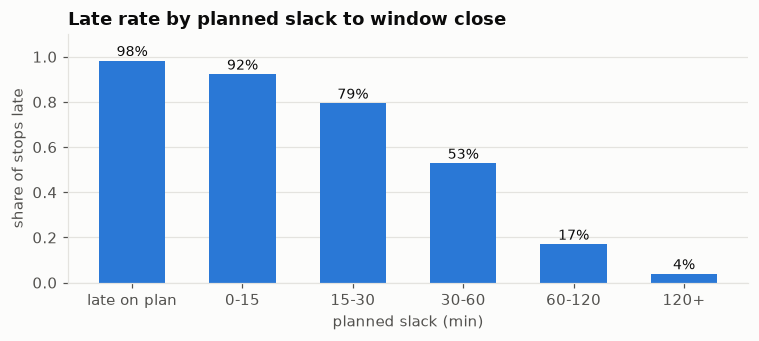

In [58]:
bands = pd.cut(route_f.planned_slack_min, [-np.inf, 0, 15, 30, 60, 120, np.inf],
               labels=["late on plan", "0-15", "15-30", "30-60", "60-120", "120+"])
late_by_band = stops.loc[train].groupby(bands[train], observed=True).late.mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(late_by_band.index.astype(str), late_by_band.values, color=SERIES[0], width=0.6)
for i, v in enumerate(late_by_band.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", color=INK, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title("Late rate by planned slack to window close")
ax.set_xlabel("planned slack (min)")
ax.set_ylabel("share of stops late")
plt.tight_layout()
plt.show()

Planned slack is the single clearest signal for lateness, but even stops with one to two hours of slack are sometimes late. The plan is optimistic, so slack on paper is not slack on the road. Section 5.6 corrects it with history.

### 5.4 Calendar and road conditions

- **Calendar:** day of week, month, payday, public holiday, festival day, festival ramp, monsoon, days until the next festival and a trend counter. The calendar is published well ahead.
- **Road advisory:** `disruption_index` for the district and day. The file covers the test dates, so it behaves like a published road and weather advisory. This is the one borderline input, so Part 6 tests the models with and without it.
- **Typical traffic:** `speed_index` for the district at the planned arrival hour, in or out of monsoon. This is a long-run profile, not a live reading.

Sunday never appears in the data, so a weekend flag would be constant and is left out.

In [59]:
cal_f = fe.calendar_features(stops, calendar)
cond_f = fe.condition_features(stops, route_f, road, traffic)
pd.concat([cal_f, cond_f], axis=1).describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
dow,96908.0,2.52,1.69,0.0,1.0,3.0,4.0,5.0
month,96908.0,6.02,3.57,1.0,3.0,6.0,9.0,12.0
is_payday,96908.0,0.07,0.26,0.0,0.0,0.0,0.0,1.0
is_holiday,96908.0,0.02,0.12,0.0,0.0,0.0,0.0,1.0
monsoon,96908.0,0.48,0.50,0.0,0.0,0.0,1.0,1.0
festival_ramp,96908.0,0.10,0.24,0.0,0.0,0.0,0.0,1.0
is_festival_day,96908.0,0.02,0.12,0.0,0.0,0.0,0.0,1.0
days_to_festival,96908.0,30.81,19.72,0.0,13.0,28.0,49.0,60.0
trend_days,96908.0,408.40,236.82,0.0,204.0,407.0,613.0,817.0
disruption_index,96908.0,92.67,12.82,41.0,91.0,99.0,100.0,100.0


### 5.5 History features

How an outlet, a vehicle or a district has behaved before is strong evidence, but it is also the easiest place to leak the answer. Three rules keep it honest:

1. **Only finished days count.** A result from day D becomes usable on day D + 2. Plans for D are drafted on D-1, when D-1's own routes may still be running.
2. **Small samples lean on their group.** An outlet's average is blended with its brand and dock type average, weighted by how many past stops it has (smoothing of 20 stops). A new outlet starts at the group average instead of an unreliable guess.
3. **The same code serves train and test.** For a test day, the newest usable history is simply the end of training, which is what a planner would have.

The history features:
- `outlet_hist_service_mean`, `outlet_hist_late_rate`, `outlet_hist_stops`
- `group_hist_service_mean` for the brand and dock type
- `district_hist_travel_ratio`: actual over planned travel time, by district and monsoon
- `vehicle_hist_depart_delay`: how late this vehicle usually leaves the depot

In [60]:
hist_f = fe.history_features(stops)
hist_f.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
group_hist_service_mean,96627.0,18.41,8.66,11.50,16.41,16.86,17.13,88.06
outlet_hist_stops,96908.0,548.05,340.97,0.00,242.00,545.00,849.00,1100.00
outlet_hist_service_mean,96627.0,18.41,10.46,7.96,12.72,15.60,21.05,102.52
outlet_hist_late_rate,96627.0,0.19,0.18,0.00,0.04,0.12,0.29,0.78
district_hist_travel_ratio,96361.0,1.71,0.33,1.05,1.42,1.66,1.92,2.70
vehicle_hist_depart_delay,96636.0,7.82,0.36,6.14,7.60,7.78,8.01,10.79


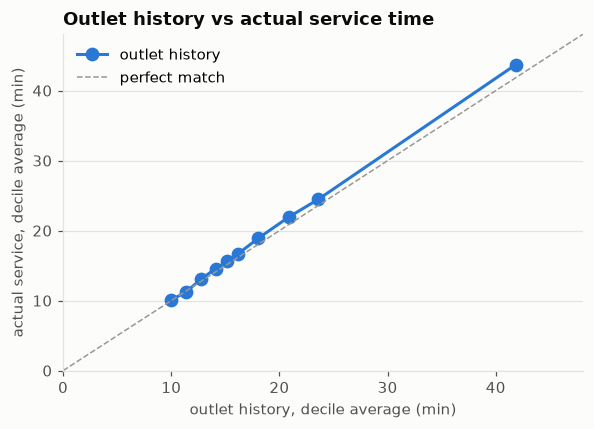

In [61]:
x = hist_f.loc[train, "outlet_hist_service_mean"]
y = stops.loc[train, "service_min"]
deciles = pd.qcut(x, 10, duplicates="drop")
binned = pd.DataFrame({"predicted": x, "actual": y}).groupby(deciles, observed=True).mean()

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(binned.predicted, binned.actual, marker="o", markersize=8, color=SERIES[0], label="outlet history")
lim = [0, binned.max().max() * 1.1]
ax.plot(lim, lim, color="#9a9893", linewidth=1, linestyle="--", label="perfect match")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title("Outlet history vs actual service time")
ax.set_xlabel("outlet history, decile average (min)")
ax.set_ylabel("actual service, decile average (min)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

On its own, an outlet's own past is already a well calibrated guess of its service time: the decile points sit close to the diagonal, slightly above it because service times creep up over time. The model's job is to explain the rest (order size, festivals, paydays, monsoon).

### 5.6 All features together

`build_task1_features` runs the five groups above and adds four combinations of the plan with history:

- `load_share_volume` and `load_share_weight`: how full the vehicle is
- `expected_travel_min`: planned travel scaled by how much slower that district usually runs
- `slack_after_history_min`: planned slack minus the extra travel history predicts so far on the route, minus the vehicle's usual late departure. This is a realistic version of slack.

In [62]:
feats = fe.build_task1_features(stops, outlets, vehicles, allowance, calendar, road, traffic)
print(feats.shape)
blanks = feats.isna().sum()
blanks[blanks > 0].rename("blank rows").to_frame()

(96908, 61)


,blank rows
group_hist_service_mean,281
outlet_hist_service_mean,281
outlet_hist_late_rate,281
district_hist_travel_ratio,547
vehicle_hist_depart_delay,272
expected_travel_min,547
slack_after_history_min,547


The only blanks are history features in the first days of 2024, before any day has finished. LightGBM handles missing values natively, so these rows stay in.

In [63]:
num = feats.select_dtypes("number")
signal = pd.DataFrame({
    "service_min": num[train].corrwith(stops.loc[train, "service_min"], method="spearman"),
    "late": num[train].corrwith(stops.loc[train, "late"].astype(float), method="spearman"),
}).round(3)
signal.reindex(signal.abs().max(axis=1).sort_values(ascending=False).index).head(15)

,service_min,late
outlet_hist_service_mean,0.672,0.052
slack_after_history_min,-0.038,-0.570
order_volume_m3,0.523,0.041
order_weight_kg,0.511,0.044
planned_slack_min,-0.030,-0.494
outlet_hist_late_rate,0.003,0.447
planned_arrival_min,0.213,0.437
planned_hour,0.215,0.417
speed_index,-0.105,-0.401
minutes_into_route,0.001,0.388


Rank correlations on the training stops are a quick, honest first look (models will find interactions these miss):
- Service time is driven by order size and the outlet's own history.
- Lateness is driven by slack, and the history-corrected slack ranks lateness better than slack on paper. This is the simulation idea in miniature: correct the plan with how the road actually behaves.

### 5.7 Proof that no feature peeks at the answer

The rules above are only claims until tested. For a set of delivery days D, we hide every actual time and label from D-1 onward, rebuild all features, and check that the features for day D do not change at all. As a control, hiding from D-2 onward should change them, which shows the test is sensitive enough to catch a leak.

In [64]:
def hide_actuals_from(df, first_hidden_day):
    df = df.copy()
    df.loc[df["date"] >= first_hidden_day, fe.ACTUAL_COLS] = np.nan
    return df

def rebuild(df):
    return fe.build_task1_features(df, outlets, vehicles, allowance, calendar, road, traffic)

test_days = pd.to_datetime(["2024-04-11", "2024-10-16", "2025-04-10", "2025-10-15", "2026-02-14"])
rows = []
for day in test_days:
    on_day = stops["date"] == day
    hidden_d1 = rebuild(hide_actuals_from(stops, day - pd.Timedelta(days=1)))
    hidden_d2 = rebuild(hide_actuals_from(stops, day - pd.Timedelta(days=2)))
    rows.append({
        "delivery day": day.date(),
        "stops": int(on_day.sum()),
        "unchanged with D-1 onward hidden": feats.loc[on_day].equals(hidden_d1.loc[on_day]),
        "changed with D-2 onward hidden": not feats.loc[on_day].equals(hidden_d2.loc[on_day]),
    })
leak_test = pd.DataFrame(rows)
assert leak_test.iloc[:, 2:].all().all()
leak_test

,delivery day,stops,unchanged with D-1 onward hidden,changed with D-2 onward hidden
0,2024-04-11,146,True,True
1,2024-10-16,148,True,True
2,2025-04-10,145,True,True
3,2025-10-15,154,True,True
4,2026-02-14,140,True,True


Every feature for a delivery day is identical whether or not the delivery day and the day before it happened. The control confirms the check would catch a one-day leak. The test days include festival and monsoon peaks and the last training day.

### 5.8 Feature availability audit

One row per feature: where it comes from and why a planner has it at 4 PM on the day before delivery. This table also goes into the preprocessing document.

In [65]:
GROUPS = {
    "Order and vehicle": (order_f.columns, "orders, outlets, vehicles, allowance table", "On the confirmed order and the drafted plan"),
    "Route position": (route_f.columns, "drafted route legs", "Planned times and distances of the drafted route"),
    "Calendar": (cal_f.columns, "calendar", "Published calendar"),
    "Road and traffic": (cond_f.columns, "road conditions, traffic profile", "Published advisory and long-run traffic profile"),
    "History": (hist_f.columns, "past finished stops", "Only days finished at least 2 days before delivery"),
}
audit = pd.DataFrame(
    [{"feature": c, "group": g, "source": src, "available at 4 PM": "yes", "why": why}
     for g, (cols, src, why) in GROUPS.items() for c in cols]
)
combined = [c for c in feats.columns if c not in set(audit.feature)]
audit = pd.concat([audit, pd.DataFrame({
    "feature": combined, "group": "Plan combined with history", "source": "features above",
    "available at 4 PM": "yes", "why": "Built only from the features above",
})], ignore_index=True)
audit.loc[audit.feature == "disruption_index", ["available at 4 PM", "why"]] = [
    "borderline", "Treated as a published advisory; models are tested with and without it"]

assert set(audit.feature) == set(feats.columns) and audit.feature.is_unique
REPORTS.mkdir(parents=True, exist_ok=True)
audit.to_csv(REPORTS / "feature_audit.csv", index=False)
print(f"{len(audit)} features audited")
audit.groupby(["group", "available at 4 PM"]).size().rename("features").to_frame()

61 features audited


features
group                      available at 4 PM          
Calendar                   yes                       9
History                    yes                       6
Order and vehicle          yes                      19
Plan combined with history yes                       4
Road and traffic           borderline                1
                           yes                       1
Route position             yes                      21

### 5.9 Save

The saved table keeps the keys needed to join predictions back (`delivery_id`, route and stop), the split, and the two labels next to the features.

In [66]:
KEYS = ["delivery_id", "split", "date", "route_id", "seq_in_route"]
LABELS = ["service_min", "late"]
task1 = pd.concat([stops[KEYS], feats, stops[LABELS]], axis=1)

assert task1.delivery_id.is_unique
assert task1.loc[task1.split == "test", LABELS].isna().all().all()
assert task1.loc[task1.split == "train", LABELS].notna().all().all()

save_processed(task1, "task1_features")
task1.groupby("split").size().rename("rows").to_frame()

,rows
split,
test,5014
train,91894


### Part 5 summary

- **61 features** in six groups, all available at the 4 PM cutoff. One, the road advisory, is flagged as borderline and will be tested both ways.
- **The plan's stop time is just the allowance table**, so the plan holds no hidden service-time information.
- **History is leak-proof by test**, not just by design: hiding the delivery day and the day before leaves every feature unchanged.
- **Slack corrected by history** ranks lateness better than slack on paper, which supports the route simulation planned for Part 6.

Next, Part 6 trains the Task 1 models on `task1_features.parquet`.

## Part 6. Task 1: service time and late risk

**Purpose:** predict, for every planned stop, how long the handling will take (`pred_service_min`) and how likely the vehicle is to arrive after the window closes (`pred_late_prob`).

**Approach in one paragraph.** Lateness builds up along a route: a slow depot exit, slow roads and long stops earlier on all push back the later stops. So instead of guessing lateness stop by stop, we model the three things that cause it (depot delay, travel slowdown, service time) and replay each drafted route 1,000 times with the real timing rules. The share of runs that arrive after closing is the late risk. A direct LightGBM classifier is trained as a challenger, and the two are compared and blended on a holdout.

**Inputs:** `stops.parquet` and the reference tables; features come from `src/xora/features.py` (Part 5).

**Outputs:**
- `submissions/submission_task1.csv`
- `models/route_simulator.pkl`, `models/late_classifier.pkl` and `models/manifest.json`

In [67]:
stops = load_processed("stops")
tables = dict(outlets=load_processed("outlets"), vehicles=load_processed("vehicles"),
              allowance=load_processed("service_allowance"), calendar=load_processed("calendar"),
              road=load_processed("road_conditions"), traffic=load_processed("traffic_speed"))

def build_frame(stop_table):
    feats = fe.build_task1_features(stop_table, **tables)
    return fe.model_frame(stops, feats)

full = build_frame(stops)
FEATURES = [c for c in full.columns if c not in fe.FRAME_COLS]
print(f"{len(full):,} stops, {len(FEATURES)} features")

96,908 stops, 61 features


### 6.1 A holdout that looks like the test

The test stops (16 Feb to 28 Mar 2026) start right after training ends, and for them the newest history a planner has is from mid February. The holdout copies that situation:

| Window | Dates | Used for |
|---|---|---|
| fit | up to 15 Nov 2025 | training the models |
| validation | 16 Nov to 31 Dec 2025 | early stopping and learning the simulation noise |
| holdout | 1 Jan to 14 Feb 2026 | every number reported below |

For the holdout, features are rebuilt with every actual from 1 January onward hidden, so its history freezes at the end of December, exactly as the test's history freezes in February. Labels stay untouched for scoring.

In [68]:
VAL_START, HOLD_START = pd.Timestamp("2025-11-16"), pd.Timestamp("2026-01-01")

hidden = stops.copy()
hidden.loc[hidden.date >= HOLD_START, fe.ACTUAL_COLS] = np.nan
hold_frame = build_frame(hidden)
label_cols = ["actual_depart_time_min", "actual_travel_duration_min", "service_min", "late"]
hold_frame[label_cols] = full[label_cols]

train = full.split == "train"
fit = full[train & (full.date < VAL_START)]
val = full[train & (full.date >= VAL_START) & (full.date < HOLD_START)]
hold = hold_frame[train & (hold_frame.date >= HOLD_START)]
y_svc, y_late = hold.service_min.to_numpy(), hold.late.astype(int).to_numpy()

pd.DataFrame({w: [len(d), d.date.min().date(), d.date.max().date()] for w, d in
              [("fit", fit), ("validation", val), ("holdout", hold)]},
             index=["stops", "from", "to"]).T

,stops,from,to
fit,81133,2024-01-01,2025-11-15
validation,5300,2025-11-17,2025-12-31
holdout,5461,2026-01-01,2026-02-14


### 6.2 Baselines: how today's planning does

A model only matters if it beats what Waypoint already does.
- **Service time:** the published allowance table, and a smarter baseline that uses each outlet's own history.
- **Late risk:** the overall late rate, and a slack rule that gives each stop the historical late rate of its planned slack band.

In [69]:
def service_scores(pred, y=y_svc):
    err = pred - y
    return {"MAE": np.mean(np.abs(err)), "RMSE": np.sqrt(np.mean(err ** 2)), "bias": np.mean(err)}

def late_scores(p, y=y_late):
    p = np.clip(p, 1e-4, 1 - 1e-4)
    return {"log loss": log_loss(y, p), "Brier": brier_score_loss(y, p), "AUC": roc_auc_score(y, p)}

service_board = pd.DataFrame({
    "allowance table (today)": service_scores(hold.allowance_min.to_numpy()),
    "outlet history": service_scores(hold.outlet_hist_service_mean.fillna(hold.allowance_min).to_numpy()),
}).T

SLACK_BANDS = [-np.inf, 0, 15, 30, 60, 120, np.inf]
band_rate = fit.late.astype(float).groupby(pd.cut(fit.planned_slack_min, SLACK_BANDS), observed=True).mean()
late_board = pd.DataFrame({
    "overall late rate": late_scores(np.full(len(hold), fit.late.astype(float).mean())),
    "planned slack rule": late_scores(pd.cut(hold.planned_slack_min, SLACK_BANDS).map(band_rate).astype(float).to_numpy()),
}).T
display(service_board.round(2))
late_board.round(4)

,MAE,RMSE,bias
allowance table (today),7.09,11.67,-1.56
outlet history,5.51,8.89,0.58


,log loss,Brier,AUC
overall late rate,0.4080,0.1200,0.5000
planned slack rule,0.2867,0.0834,0.8573


The allowance table misses by about 7 minutes per stop on the holdout. Slack on paper already separates late from on-time stops quite well (AUC 0.86), which is the bar for the late models.

### 6.3 Service time: which loss to train on

The scoring metric for service time is not stated, so we don't guess. We train the same model three ways and keep the one that is safest whichever metric is used:
- **median** (L1 loss): best if scored on MAE
- **mean** (L2 loss): best if scored on RMSE
- **Huber**: a compromise between the two

For each, regret is how much worse it is than the best of the three on each metric. We keep the model with the smallest worst-case regret.

In [70]:
objectives = {"median": dict(objective="l1"), "mean": dict(objective="l2"),
              "Huber": dict(objective="huber", alpha=5.0)}
service_models, rows = {}, {}
for name, params in objectives.items():
    m = _fit_lgb(fit[FEATURES], fit.service_min, val[FEATURES], val.service_min, **params)
    service_models[name] = m
    rows[name] = service_scores(np.clip(m.predict(hold[FEATURES]), 1, None))

loss_table = pd.DataFrame(rows).T[["MAE", "RMSE", "bias"]]
for metric in ["MAE", "RMSE"]:
    loss_table[f"{metric} regret"] = loss_table[metric] / loss_table[metric].min() - 1
loss_table["worst regret"] = loss_table[["MAE regret", "RMSE regret"]].max(axis=1)
CHOSEN = loss_table["worst regret"].idxmin()
print("chosen:", CHOSEN)
loss_table.style.format({c: "{:.2%}" for c in loss_table.columns if "regret" in c} | {"MAE": "{:.3f}", "RMSE": "{:.3f}", "bias": "{:.3f}"})

chosen: mean


,MAE,RMSE,bias,MAE regret,RMSE regret,worst regret
median,3.900,6.510,-0.333,0.00%,3.32%,3.32%
mean,3.920,6.301,0.228,0.52%,0.00%,0.52%
Huber,3.915,6.629,-0.272,0.37%,5.20%,5.20%


All three cut the allowance table's error roughly in half. The median model wins MAE by a hair but gives up several percent on RMSE, because it ignores how long the slow stops run. The mean model is within half a percent of the best MAE and is best on RMSE, so it has the smallest worst-case regret and is the one we keep.

### 6.4 The other two components: travel and depot delay

- **Travel slowdown:** the log of actual over planned travel time for each leg, from district, hour, monsoon, road advisory, festival timing and leg length.
- **Depot delay:** how many minutes after the planned time the vehicle actually leaves, from depot, vehicle, start time, load and calendar.

Both are fitted inside the simulator alongside the chosen service model.

In [71]:
sim = RouteSimulator(service_features=FEATURES, service_objective=CHOSEN).fit(fit, val)

travel_true = np.log(hold.actual_travel_duration_min / hold.planned_travel_min.clip(lower=1))
travel_pred = sim.travel_model.predict(hold[sim.travel_features])
first = hold[hold.seq == 0]
delay_true = first.actual_depart_time_min - first.planned_depart_time_min
delay_pred = sim.delay_model.predict(first[sim.delay_features])

ratio_true, ratio_pred = np.exp(travel_true), np.exp(travel_pred)
pd.DataFrame({
    "travel ratio, MAE": [np.mean(np.abs(ratio_true - 1)), np.mean(np.abs(ratio_true - hold.district_hist_travel_ratio)), np.mean(np.abs(ratio_true - ratio_pred))],
    "depot delay, MAE (min)": [np.mean(np.abs(delay_true)), np.mean(np.abs(delay_true - first.vehicle_hist_depart_delay)), np.mean(np.abs(delay_true - delay_pred))],
}, index=["plan as given", "history average", "component model"]).round(3)

,"travel ratio, MAE","depot delay, MAE (min)"
plan as given,0.487,7.654
history average,0.339,4.468
component model,0.215,4.267


The plan assumes roads run at planned speed, and they almost never do. The travel model cuts the travel error well below both the plan and the district average. Depot delay is mostly random (a few minutes either way), so the model improves only a little on each vehicle's own average. That is fine: the simulation samples that randomness rather than pretending to predict it.

### 6.5 Route simulation

The simulator learns its noise from the validation window, which the models never trained on:
- **service:** the spread of actual over predicted, per brand
- **travel:** a shared part per route (a slow day slows every leg) plus a part per leg
- **depot delay:** its leftover spread

It then replays every holdout route 1,000 times.

In [72]:
sim.learn_noise(val)
sim_hold = sim.simulate(hold)
p_sim = sim_hold.sim_late_prob.to_numpy()
late_board.loc["route simulation"] = late_scores(p_sim)
late_board.round(4)

,log loss,Brier,AUC
overall late rate,0.4080,0.1200,0.5000
planned slack rule,0.2867,0.0834,0.8573
route simulation,0.1432,0.0429,0.9703


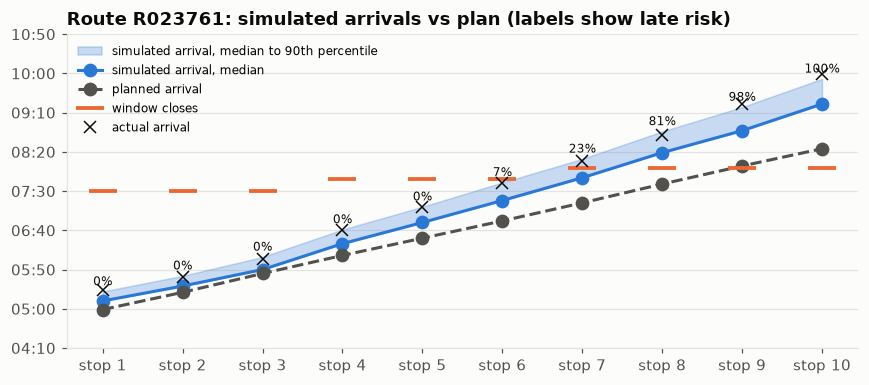

In [73]:
# One busy holdout route, stop by stop
rid = hold.groupby("route_id").size().sort_values().index[-1]
r = hold[hold.route_id == rid].sort_values("seq")
o = sim_hold.set_index("delivery_id").loc[r.delivery_id]
x = np.arange(len(r))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.fill_between(x, o.arrival_p50_min, o.arrival_p90_min, color=SERIES[0], alpha=0.25, label="simulated arrival, median to 90th percentile")
ax.plot(x, o.arrival_p50_min, color=SERIES[0], marker="o", markersize=8, label="simulated arrival, median")
ax.plot(x, r.planned_arrival_min, color=INK_SOFT, linestyle="--", marker="o", markersize=8, label="planned arrival")
ax.plot(x, r.window_close_time_min, color=SERIES[1], marker="_", markersize=18, linestyle="none", markeredgewidth=2.5, label="window closes")
actual_arrival = r.actual_depart_time_min + r.actual_travel_duration_min
ax.plot(x, actual_arrival, color=INK, marker="x", markersize=8, linestyle="none", label="actual arrival")
for i, p in enumerate(o.sim_late_prob):
    ax.text(i, o.arrival_p90_min.iloc[i] + 8, f"{p:.0%}", ha="center", fontsize=8, color=INK)
ax.set_xticks(x, [f"stop {i + 1}" for i in x])
ax.set_yticks(ax.get_yticks(), [f"{int(t // 60):02d}:{int(t % 60):02d}" for t in ax.get_yticks()])
ax.set_title(f"Route {rid}: simulated arrivals vs plan (labels show late risk)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The planned arrivals (dashed) fall further behind reality at every stop. The simulated band follows the actual arrivals much more closely, which land inside it or just above it. The late risk rises along the route for the same reason real lateness does.

### 6.6 Challenger, blend and calibration

The challenger is a LightGBM classifier trained directly on the late label with the same features (including the history-corrected slack). We compare it with the simulation and with a plain 50/50 average of the two. An average needs no fitting, so it cannot overfit the holdout.

We also test isotonic calibration, cross-fitted on alternating holdout weeks so it is never scored on the weeks it learned from.

In [74]:
def fit_classifier(cols):
    return lgb.LGBMClassifier(n_estimators=4000, **LGB_PARAMS).fit(
        fit[cols], fit.late.astype(int), eval_X=(val[cols],), eval_y=(val.late.astype(int),),
        callbacks=[lgb.early_stopping(200, verbose=False)])

def blend(p_a, p_b):
    # Never fully certain: a 0 or 1 that turns out wrong costs too much under log loss
    return np.clip((p_a + p_b) / 2, 0.002, 0.998)

clf = fit_classifier(FEATURES)
p_clf = clf.predict_proba(hold[FEATURES])[:, 1]
p_blend = blend(p_sim, p_clf)
late_board.loc["direct classifier"] = late_scores(p_clf)
late_board.loc["blend (50/50)"] = late_scores(p_blend)

week_parity = hold.date.dt.isocalendar().week.to_numpy() % 2
def cross_fit_isotonic(p):
    out = np.empty_like(p)
    for k in (0, 1):
        iso = IsotonicRegression(out_of_bounds="clip", y_min=1e-4, y_max=1 - 1e-4)
        iso.fit(p[week_parity != k], y_late[week_parity != k])
        out[week_parity == k] = iso.predict(p[week_parity == k])
    return out
late_board.loc["blend + isotonic"] = late_scores(cross_fit_isotonic(p_blend))
late_board.round(4)

,log loss,Brier,AUC
overall late rate,0.4080,0.1200,0.5000
planned slack rule,0.2867,0.0834,0.8573
route simulation,0.1432,0.0429,0.9703
direct classifier,0.1381,0.0429,0.9736
blend (50/50),0.1360,0.0415,0.9745
blend + isotonic,0.1379,0.0419,0.9729


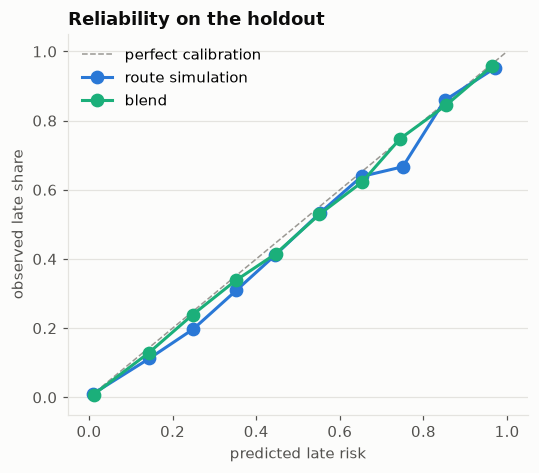

In [75]:
bins = np.linspace(0, 1, 11)
fig, ax = plt.subplots(figsize=(5, 4.4))
ax.plot([0, 1], [0, 1], color="#9a9893", linestyle="--", linewidth=1, label="perfect calibration")
for (name, p), color in zip([("route simulation", p_sim), ("blend", p_blend)], [SERIES[0], SERIES[2]]):
    idx = np.digitize(p, bins[1:-1])
    rel = pd.DataFrame({"pred": p, "obs": y_late, "bin": idx}).groupby("bin").mean()
    ax.plot(rel.pred, rel.obs, marker="o", markersize=8, color=color, label=name)
ax.set_xlabel("predicted late risk")
ax.set_ylabel("observed late share")
ax.set_title("Reliability on the holdout")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

- The simulation alone beats the slack rule by a wide margin (log loss halves) and is well calibrated, without ever being trained on the late label.
- The classifier is slightly sharper, and the blend is best on every metric. Their errors differ enough that averaging helps.
- Isotonic calibration makes things slightly worse because the blend is already calibrated, so it is not used.

We submit the blend.

### 6.7 Is the road advisory needed?

`disruption_index` was the one borderline feature in the audit. We retrain everything without it and compare. We keep it only if it clearly helps (more than 2% better log loss and MAE no worse).

In [76]:
NO_ROAD = [c for c in FEATURES if c != "disruption_index"]
sim_nr = RouteSimulator(service_features=NO_ROAD, service_objective=CHOSEN,
                        travel_features=[c for c in TRAVEL_FEATURES if c != "disruption_index"]).fit(fit, val).learn_noise(val)
clf_nr = fit_classifier(NO_ROAD)
p_blend_nr = blend(sim_nr.simulate(hold).sim_late_prob.to_numpy(), clf_nr.predict_proba(hold[NO_ROAD])[:, 1])

road_test = pd.DataFrame({
    "with road advisory": {**late_scores(p_blend), "service MAE": service_scores(sim.predict_service(hold))["MAE"]},
    "without": {**late_scores(p_blend_nr), "service MAE": service_scores(sim_nr.predict_service(hold))["MAE"]},
}).T
gain = 1 - road_test.loc["with road advisory", "log loss"] / road_test.loc["without", "log loss"]
KEEP_ROAD = gain > 0.02 and road_test.loc["with road advisory", "service MAE"] <= road_test.loc["without", "service MAE"] + 0.01
print(f"log loss gain from the advisory: {gain:.1%}  ->  keep it: {KEEP_ROAD}")
road_test.round(4)

log loss gain from the advisory: 21.8%  ->  keep it: True


,log loss,Brier,AUC,service MAE
with road advisory,0.1360,0.0415,0.9745,3.9205
without,0.1739,0.0521,0.9566,3.9793


The decision above is made by the rule, not by hand. If the advisory is kept, the deployment depends on Waypoint receiving the district road advisory by 4 PM, and this is written into the model card.

### 6.8 Where the models are strong and weak

Average scores can hide weak spots. We break the holdout down by brand for service time and by stop position for late risk.

In [77]:
best_sim, best_clf = (sim, clf) if KEEP_ROAD else (sim_nr, clf_nr)
best_feats = FEATURES if KEEP_ROAD else NO_ROAD
hold_pred_svc = best_sim.predict_service(hold)
hold_pred_late = p_blend if KEEP_ROAD else p_blend_nr

seg = hold.assign(pred=hold_pred_svc, p=hold_pred_late, err=np.abs(hold_pred_svc - y_svc),
                  allow_err=np.abs(hold.allowance_min - y_svc))
by_brand = seg.groupby("brand", observed=True).agg(stops=("err", "size"), model_MAE=("err", "mean"), allowance_MAE=("allow_err", "mean"))
by_brand["error cut"] = 1 - by_brand.model_MAE / by_brand.allowance_MAE

pos = pd.cut(seg.seq, [-1, 0, 2, 4, 6, 10], labels=["1st", "2nd-3rd", "4th-5th", "6th-7th", "8th+"])
by_pos = seg.groupby(pos, observed=True).apply(
    lambda g: pd.Series({"stops": len(g), "late share": g.late.mean(), "mean predicted": g.p.mean(),
                         "AUC": roc_auc_score(g.late.astype(int), g.p) if g.late.nunique() > 1 else np.nan}))
display(by_brand.style.format({"model_MAE": "{:.2f}", "allowance_MAE": "{:.2f}", "error cut": "{:.0%}"}))
by_pos.round(3)

,stops,model_MAE,allowance_MAE,error cut
brand,,,,
Fresh,5190,3.49,6.34,45%
Style,167,10.03,15.89,37%
Tech,104,15.62,30.05,48%


,stops,late share,mean predicted,AUC
seq,,,,
1st,1509.0,0.054,0.051,0.971
2nd-3rd,2254.0,0.096,0.098,0.975
4th-5th,1197.0,0.162,0.185,0.964
6th-7th,432.0,0.426,0.433,0.958
8th+,69.0,0.739,0.729,0.980


- The biggest gain is on Tech, where the allowance table is furthest off.
- Predicted and observed late shares match at every stop position, from the first stop to the last. So the risk is right where dispatchers will act on it, not just on average.

### 6.9 Why a stop is predicted slow or late

LightGBM can split each prediction into one contribution per feature (SHAP values). Averaged over the holdout, they show what drives each model. For a single stop, the largest contributions become the plain-language reason line used in Part 9.

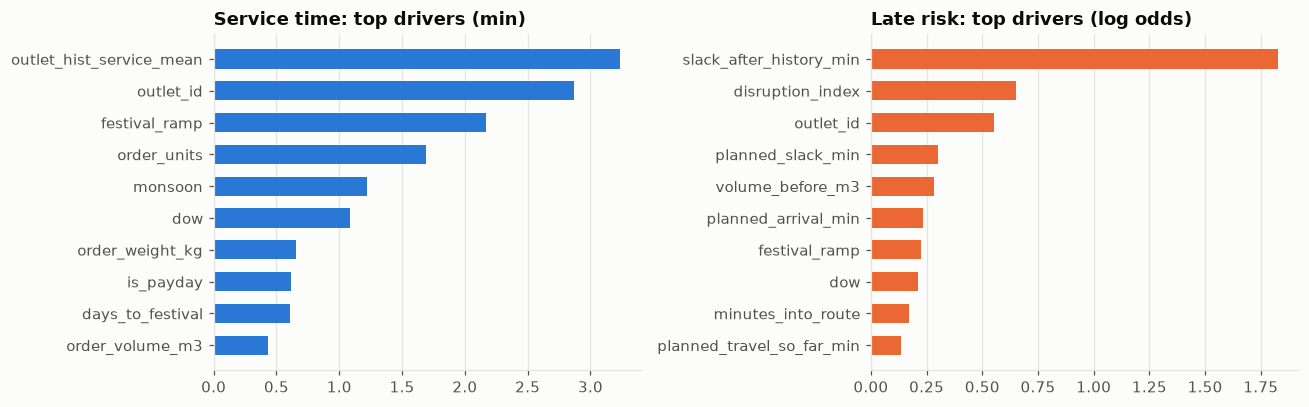

In [78]:
def mean_abs_contrib(model, X):
    contrib = model.predict(X, pred_contrib=True)[:, :-1]  # last column is the base value
    return pd.Series(np.abs(contrib).mean(axis=0), index=X.columns)

top_svc = mean_abs_contrib(best_sim.service_model, hold[best_feats]).nlargest(10)
top_late = mean_abs_contrib(best_clf, hold[best_feats]).nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, s, title, color in [(axes[0], top_svc, "Service time: top drivers (min)", SERIES[0]),
                            (axes[1], top_late, "Late risk: top drivers (log odds)", SERIES[1])]:
    s = s.iloc[::-1]
    ax.barh(s.index, s.values, color=color, height=0.6)
    ax.set_title(title)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [79]:
# The reason line for the riskiest stop in the holdout
i = int(np.argmax(hold_pred_late))
row = hold.iloc[[i]][best_feats]
contrib = pd.Series(best_clf.predict(row, pred_contrib=True)[0, :-1], index=best_feats)
top = contrib.nlargest(3)
print(f"{hold.delivery_id.iloc[i]}: late risk {hold_pred_late[i]:.0%}")
for f, v in top.items():
    print(f"  {f} = {row[f].iloc[0]}  (pushes risk up by {v:.2f} log odds)")

ORD0086861: late risk 100%
  slack_after_history_min = -95.02399624510186  (pushes risk up by 4.42 log odds)
  volume_before_m3 = 12.823  (pushes risk up by 1.36 log odds)
  planned_slack_min = -24.0  (pushes risk up by 1.30 log odds)


Service time is driven mostly by the outlet itself (its history and identity), festival timing and order size. Late risk is driven above all by the slack left after correcting for how the roads usually behave, then by the road advisory and the outlet. Both match what Parts 2 and 5 found, which is a good sign the models learned the operation and not noise.

### 6.10 Final models and Task 1 predictions

For the test, every component is refit on all training stops with the number of trees chosen above. The simulation noise is taken from the holdout errors, because the holdout had frozen history just like the test. The classifier is refit the same way, and the blend is applied to the test stops.

In [80]:
all_train = full[train]
test = full[full.split == "test"]

final_sim = RouteSimulator(service_features=best_sim.service_features, service_objective=CHOSEN,
                           travel_features=best_sim.travel_features, delay_features=best_sim.delay_features)
final_sim.service_model, final_sim.travel_model, final_sim.delay_model = best_sim.service_model, best_sim.travel_model, best_sim.delay_model
final_sim.learn_noise(hold)          # noise from the frozen-history holdout
final_sim.refit(all_train)           # then refit the models on everything

final_clf = lgb.LGBMClassifier(**{**best_clf.get_params(), "n_estimators": int(best_clf.best_iteration_ * 1.1)})
final_clf.fit(all_train[best_feats], all_train.late.astype(int))

test_sim = final_sim.simulate(test)
test_pred = pd.DataFrame({
    "delivery_id": test.delivery_id.to_numpy(),
    "pred_service_min": test_sim.pred_service_min.round(2).to_numpy(),
    "pred_late_prob": blend(test_sim.sim_late_prob.to_numpy(), final_clf.predict_proba(test[best_feats])[:, 1]).round(4),
})
test_pred.describe().round(3)

,pred_service_min,pred_late_prob
count,5014.000,5014.000
mean,18.671,0.220
std,11.962,0.347
min,5.690,0.002
25%,12.070,0.002
50%,15.880,0.012
75%,21.070,0.304
max,141.320,0.998


In [81]:
template = pd.read_csv(raw_file("submission_task1.csv"))
submission = template[["delivery_id"]].merge(test_pred, on="delivery_id", how="left", validate="one_to_one")

checks = {
    "same ids in the same order as the template": submission.delivery_id.equals(template.delivery_id),
    "columns match the template": list(submission.columns) == list(template.columns),
    "no blanks": bool(submission.notna().all().all()),
    "service time is positive": bool((submission.pred_service_min > 0).all()),
    "late probability within 0 to 1": bool(submission.pred_late_prob.between(0, 1).all()),
}
assert all(checks.values()), checks
SUBMISSIONS.mkdir(exist_ok=True)
submission.to_csv(SUBMISSIONS / "submission_task1.csv", index=False)
pd.Series(checks, name="passed").to_frame()

,passed
same ids in the same order as the template,True
columns match the template,True
no blanks,True
service time is positive,True
late probability within 0 to 1,True


In [82]:
# The test period (16 Feb to 28 Mar) is seasonally different from the holdout, so
# compare it with the same weeks in earlier years as well
def same_weeks(year):
    t = full[train & full.date.between(f"{year}-02-16", f"{year}-03-28")]
    return [t.service_min.mean(), t.late.mean()]

compare = pd.DataFrame({
    "holdout actual": [y_svc.mean(), y_late.mean()],
    "holdout predicted": [hold_pred_svc.mean(), hold_pred_late.mean()],
    "same weeks 2024 actual": same_weeks(2024),
    "same weeks 2025 actual": same_weeks(2025),
    "test predicted": [submission.pred_service_min.mean(), submission.pred_late_prob.mean()],
}, index=["mean service time (min)", "late share"])
compare.round(3)

,holdout actual,holdout predicted,same weeks 2024 actual,same weeks 2025 actual,test predicted
mean service time (min),18.556,18.784,17.001,17.831,18.671
late share,0.133,0.138,0.204,0.214,0.220


The test predicts more lateness than the holdout (about 22% vs 13%). That is not drift: the same weeks in 2024 and 2025 also ran about 20 to 21% late, because March brings the monsoon. The models picked up the seasonal pattern rather than copying the most recent level.

In [83]:
MODELS.mkdir(exist_ok=True)
joblib.dump(final_sim, MODELS / "route_simulator.pkl")
joblib.dump(final_clf, MODELS / "late_classifier.pkl")

manifest_path = MODELS / "manifest.json"
manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
manifest["task1"] = {
    "files": ["route_simulator.pkl", "late_classifier.pkl"],
    "features": best_feats,
    "service_objective": CHOSEN,
    "late_risk": "average of route simulation and direct classifier",
    "road_advisory_used": bool(KEEP_ROAD),
    "simulation_runs": final_sim.n_sims,
    "seed": SEED,
    "trained_on": f"{all_train.date.min().date()} to {all_train.date.max().date()}",
    "holdout": {"service": service_scores(hold_pred_svc), "late": late_scores(hold_pred_late),
                "allowance_table_MAE": float(service_board.loc["allowance table (today)", "MAE"])},
    "versions": {"lightgbm": lgb.__version__, "pandas": pd.__version__, "numpy": np.__version__},
}
manifest_path.write_text(json.dumps(manifest, indent=2, default=float))
print(json.dumps(manifest["task1"]["holdout"], indent=2, default=lambda v: round(float(v), 4)))

{
  "service": {
    "MAE": 3.9204903561678157,
    "RMSE": 6.301428166279436,
    "bias": 0.22840507355538572
  },
  "late": {
    "log loss": 0.1360045606922078,
    "Brier": 0.0415076360685099,
    "AUC": 0.9744605589580251
  },
  "allowance_table_MAE": 7.086614173228346
}


### Part 6 summary

| | Today | Our model | Change |
|---|---|---|---|
| Service time error per stop (MAE, holdout) | allowance table | mean-loss LightGBM | about half the error |
| Late risk (log loss, holdout) | planned slack rule | simulation + classifier blend | less than half |

- **One consistent story:** the late risk comes from replaying the same service and travel predictions along each route, so the two Task 1 outputs agree with each other.
- **Metric-safe choice:** the mean model was picked by worst-case regret across MAE and RMSE, not by guessing the metric.
- **Calibrated without tuning:** the blend matches observed late shares at every stop position, so a 30% risk really means about 3 in 10.
- **Ready for operations:** each stop gets an arrival band and a reason line, which Part 9 turns into plain-language outputs for dispatchers and drivers.

Exact numbers are in the tables above and in `models/manifest.json`.

## Part 7. Task 2A: weekly demand forecast

**Purpose:** forecast total and chilled volume (m3) for each depot and brand for ISO weeks 14 to 23 of 2026. These are the weeks around New Year, Vesak and Poson, when reefer and truck capacity is tightest.

**The trap.** Festivals move between ISO weeks every year (Part 2). Vesak was week 21 in 2024, week 20 in 2025 and is week 18 in 2026. Any method that copies "the same week last year" puts the festival spike in the wrong week.

**Our approach.** Forecast each day, then add the days up into ISO weeks. A daily model learns "the days before a festival are busy and the festival day is closed", so the weekly totals follow the 2026 calendar on their own. Two daily models are blended:
- a readable per-series regression on log volume with a growth trend and calendar effects
- one LightGBM across all series that learns the calendar shape on top of that trend

**Inputs:** clean orders (train and Task 1 test inputs), the calendar and the `not_run` uplift from Part 4.

**Outputs:** `submissions/submission_task2a.csv`, `data/processed/task2a_forecast.parquet` with P10/P50/P90 ranges, and saved models in `models/`.

In [84]:
orders = load_processed("orders")
calendar = load_processed("calendar")
weekly_table = load_processed("weekly_demand")

### 7.1 Daily demand panel

The counting rules match Part 4's weekly table:
- every order counts once on its order date, including deferred and `not_run` orders
- weeks come from the calendar's `iso_year` and `iso_week`
- weeks 8 to 13 of 2026 come from the Task 1 test inputs, which leave out `not_run` orders, so they get the same small uplift as in Part 4

Days with no orders are filled with zero, so Style and Tech, which do not order every day, are not overstated. Chilled is forecast only for Fresh; Style and Tech carry no chilled goods.

In [85]:
test_weeks = weekly_table[weekly_table.source == "test inputs"]
uplift = test_weeks.assign(
    factor_total=(test_weeks.total_volume_m3_adj / test_weeks.total_volume_m3).fillna(1.0),
    factor_chilled=(test_weeks.chilled_volume_m3_adj / test_weeks.chilled_volume_m3).fillna(1.0),
)[["depot", "brand", "iso_year", "iso_week", "factor_total", "factor_chilled"]]

panel = fc.daily_panel(orders, calendar, uplift)
weekly = fc.to_weeks(panel, ["y"])

# The daily panel must add back up to Part 4's weekly table exactly
check = weekly.pivot_table(index=["depot", "brand", "iso_year", "iso_week"], columns="measure", values="y").fillna(0)
ref = weekly_table.set_index(["depot", "brand", "iso_year", "iso_week"])[["total_volume_m3_adj", "chilled_volume_m3_adj"]]
gap = (check[["total", "chilled"]].to_numpy() - ref.loc[check.index].to_numpy())
print(f"largest gap against the weekly table: {np.abs(gap).max():.6f} m3")
panel.groupby(fc.SERIES_KEYS, observed=True).agg(days=("y", "size"), mean_daily_m3=("y", "mean"), last_day=("date", "max"))

largest gap against the weekly table: 0.000000 m3


days  mean_daily_m3   last_day
depot      brand measure                                
Kandy      Fresh chilled   818      26.004836 2026-03-28
                 total     818      71.553423 2026-03-28
           Style total     818      11.584805 2026-03-28
           Tech  total     818       3.035246 2026-03-28
Peliyagoda Fresh chilled   818      50.387904 2026-03-28
                 total     818     136.754166 2026-03-28
           Style total     818      20.263391 2026-03-28
           Tech  total     818       4.258793 2026-03-28

### 7.2 Why "same week last year" fails

Peliyagoda Fresh is the largest series. Plotting each year against its ISO week shows the problem: the busy week before New Year and the dip in the festival week itself sit in different weeks every year.

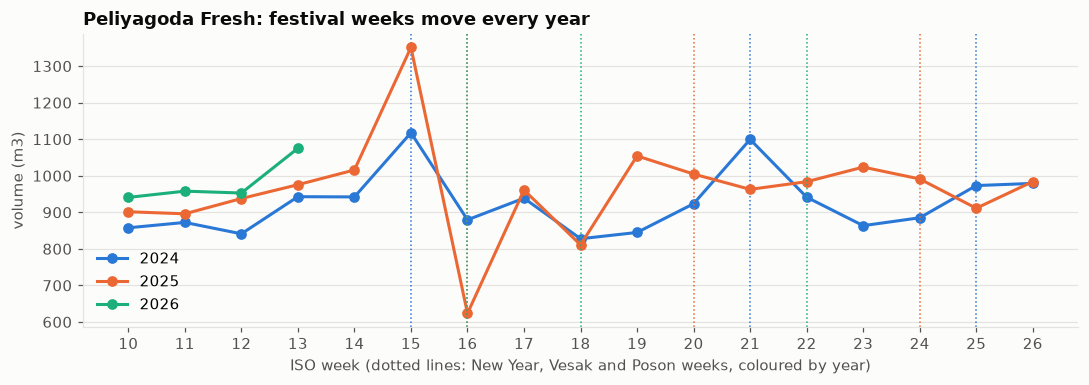

In [86]:
pf = weekly[(weekly.depot == "Peliyagoda") & (weekly.brand == "Fresh") & (weekly.measure == "total")]
fest_weeks = calendar[calendar.festival.isin(["new_year", "vesak", "poson"])][["iso_year", "iso_week", "festival"]]

fig, ax = plt.subplots(figsize=(10, 3.6))
for (year, g), color in zip(pf.groupby("iso_year"), SERIES):
    g = g[g.iso_week.between(10, 26)]
    ax.plot(g.iso_week, g.y, marker="o", markersize=6, color=color, label=str(year))
    for _, f in fest_weeks[fest_weeks.iso_year == year].iterrows():
        if 10 <= f.iso_week <= 26:
            ax.axvline(f.iso_week, color=color, linewidth=1, linestyle=":")
ax.set_xticks(range(10, 27))
ax.set_xlabel("ISO week (dotted lines: New Year, Vesak and Poson weeks, coloured by year)")
ax.set_ylabel("volume (m3)")
ax.set_title("Peliyagoda Fresh: festival weeks move every year")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

The 2026 lines stop at week 13 because that is where the forecast begins. New Year falls in week 15 in 2024 but week 16 in 2025 and 2026, and Vesak moves from week 21 to 20 to 18. A weekly model keyed on the week number would put each spike and dip in the wrong place.

### 7.3 The two daily models

**Regression (readable).** For each series, log daily volume is regressed on:
- a growth trend
- day of week and month
- festival ramp, payday, holiday and monsoon flags
- dummies for the 10 days before and 4 days after a festival

It is fitted on operating days only, because non-operating days are zero by definition. A small ridge penalty keeps the many calendar effects stable.

**Calendar LightGBM.** One model across all eight series learns the remaining calendar shape on top of the regression's growth trend: which festival is coming, how many days away it is, the day of year and so on. Trees cannot extrapolate a trend, so the trend comes from the regression and LightGBM only learns the shape around it.

In [87]:
reg_full = fc.TrendRegression().fit(panel)
growth = pd.Series({k: np.expm1(b[1]) for k, b in reg_full.coef.items()}, name="growth per year")
growth.index = growth.index.set_names(fc.SERIES_KEYS)
growth.to_frame().style.format("{:+.1%}")

The fitted growth rates match what Part 2 found: a few percent a year for Fresh, and faster but noisier growth for Tech.

### 7.4 Backtests

Each backtest pretends to stand at a past Monday, trains only on data before it, and forecasts the next 10 weeks, the same shape as the real task. Six origins cover a full year, including the April festival window of 2025, which is the closest match to the real forecast.

Compared methods:
- **same week last year** (seasonal naive): the usual shortcut
- **recent average:** the mean of the last 8 weeks
- **regression**, **calendar LightGBM**, and a 50/50 **blend** of the two

Metrics, on weekly totals:
- **WAPE:** total absolute error over total volume, so big series count more, as they do for fleet planning
- **vs last year:** total absolute error divided by that of "same week last year" on the same weeks. Below 1 beats the shortcut.
- **bias:** whether a method runs high or low

In [88]:
ORIGINS = pd.to_datetime(["2025-01-06", "2025-03-31", "2025-06-30", "2025-09-29", "2025-12-01", "2026-01-19"])
HORIZON = pd.Timedelta(weeks=10)
METHODS = ["same week last year", "recent average", "regression", "calendar LightGBM", "blend"]

def backtest(origin):
    past = panel[panel.date < origin]
    future = panel[(panel.date >= origin) & (panel.date < origin + HORIZON)].copy()
    future["regression"] = fc.TrendRegression().fit(past).predict(future)
    future["calendar LightGBM"] = fc.CalendarGBM().fit(past).predict(future)
    wk = fc.to_weeks(future, ["y", "regression", "calendar LightGBM"])
    wk["blend"] = (wk["regression"] + wk["calendar LightGBM"]) / 2

    past_wk = fc.to_weeks(past, ["y"])
    last_year = past_wk.assign(iso_year=past_wk.iso_year + 1).rename(columns={"y": "same week last year"})
    wk = wk.merge(last_year, on=fc.SERIES_KEYS + ["iso_year", "iso_week"], how="left").fillna({"same week last year": 0})
    recent = past_wk.groupby(fc.SERIES_KEYS, observed=True).tail(8).groupby(fc.SERIES_KEYS, observed=True).y.mean()
    wk = wk.merge(recent.rename("recent average"), on=fc.SERIES_KEYS)

    wk["origin"] = origin.date()
    wk["horizon_week"] = wk.groupby(fc.SERIES_KEYS, observed=True).cumcount() + 1
    return wk

bt = pd.concat([backtest(o) for o in ORIGINS], ignore_index=True)

def scores(df):
    out = {}
    for m in METHODS:
        err = df[m] - df.y
        out[(m, "WAPE")] = err.abs().sum() / df.y.sum()
        out[(m, "vs last year")] = err.abs().sum() / (df["same week last year"] - df.y).abs().sum()
        out[(m, "bias")] = err.sum() / df.y.sum()
    return pd.Series(out)

overall = bt.groupby("measure").apply(scores).T.unstack(level=1)
overall.style.format({c: "{:.2f}" if c[1] == "vs last year" else "{:.1%}" for c in overall.columns})

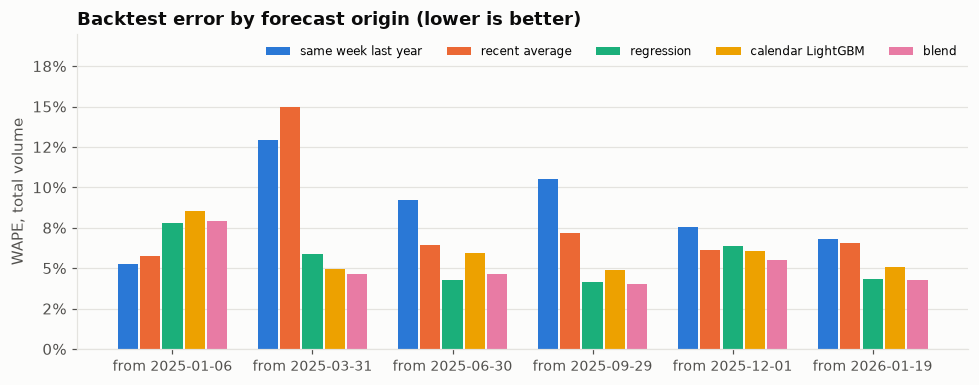

In [89]:
wape_by_origin = bt[bt.measure == "total"].groupby("origin").apply(
    lambda g: pd.Series({m: (g[m] - g.y).abs().sum() / g.y.sum() for m in METHODS}))

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(wape_by_origin))
width = 0.16
for i, (m, color) in enumerate(zip(METHODS, SERIES)):
    ax.bar(x + (i - 2) * width, wape_by_origin[m], width=width * 0.9, color=color, label=m)
ax.set_xticks(x, [f"from {o}" for o in wape_by_origin.index], fontsize=9)
ax.set_ylabel("WAPE, total volume")
ax.set_title("Backtest error by forecast origin (lower is better)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(0, wape_by_origin.to_numpy().max() * 1.3)
ax.legend(ncol=5, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

- **Same week last year is worst exactly where it matters.** In the April festival window (origin 31 March 2025) its error is about three times the blend's, because New Year and Vesak moved weeks.
- **The blend is best overall** for both total and chilled volume, and its bias is close to zero.
- The first origin (January 2025) has only one year of history, so the calendar effects are not settled yet and the simple shortcut wins there. From the April 2025 origin onward, with more history, the blend wins every time.

### 7.5 Error by brand and forecast ranges

Fresh dominates total volume, so the overall WAPE mostly reflects Fresh. Style and Tech are small and lumpy, so their percentage errors are naturally larger. They also matter less for truck and reefer planning.

For planning we also need a range, not just one number. From the backtests we take the spread of actual over forecast per brand, and set P10 and P90 bands from it. To check the bands honestly, each origin's band is built only from the other five origins (leave one out).

In [90]:
blend_err = bt.assign(abs_err=(bt.blend - bt.y).abs())
by_brand = blend_err.groupby(["brand", "measure"]).agg(weekly_volume=("y", "mean"), WAPE=("abs_err", "sum"))
by_brand["WAPE"] = by_brand.WAPE / blend_err.groupby(["brand", "measure"]).y.sum()
display(by_brand.style.format({"weekly_volume": "{:.1f}", "WAPE": "{:.1%}"}))

bt["ratio"] = (bt.y / bt.blend.replace(0, np.nan)).clip(0, 5)
coverage = []
for o in bt.origin.unique():
    rest, this = bt[bt.origin != o], bt[bt.origin == o]
    q = rest.groupby(["brand", "measure"]).ratio.quantile([0.1, 0.9]).unstack()
    t = this.join(q, on=["brand", "measure"])
    coverage.append(((t.y >= t.blend * t[0.1]) & (t.y <= t.blend * t[0.9])).mean())
print(f"share of weeks inside the P10 to P90 band, leave one origin out: {np.mean(coverage):.0%} (target 80%)")

share of weeks inside the P10 to P90 band, leave one origin out: 76% (target 80%)


Checked on origins it never saw, the band holds about three quarters of weeks against an 80% target, so it is slightly narrow. Planners should read P90 as a likely upper level, not a hard ceiling. Tech is the hardest series (around a third error week to week) because its orders are few and lumpy, but it is also the smallest, at under 30 m3 a week per depot.

### 7.6 Final forecast for 2026 weeks 14 to 23

Both models are refit on all data up to 28 March 2026 and run day by day from 30 March to 7 June. The days are added up into ISO weeks, and the P10 and P90 bands come from all six backtests.

In [91]:
FORECAST_START, FORECAST_END = pd.Timestamp("2026-03-30"), pd.Timestamp("2026-06-07")
final_reg = fc.TrendRegression().fit(panel)
final_gbm = fc.CalendarGBM().fit(panel)

future = fc.future_panel(panel, calendar, FORECAST_START, FORECAST_END)
future["regression"] = final_reg.predict(future)
future["calendar LightGBM"] = final_gbm.predict(future)
fcst = fc.to_weeks(future, ["regression", "calendar LightGBM"])
fcst["p50"] = (fcst["regression"] + fcst["calendar LightGBM"]) / 2

bands = bt.groupby(["brand", "measure"]).ratio.quantile([0.1, 0.9]).unstack()
fcst = fcst.join(bands, on=["brand", "measure"])
fcst["p10"], fcst["p90"] = fcst.p50 * fcst[0.1], fcst.p50 * fcst[0.9]
fcst = fcst.drop(columns=[0.1, 0.9])
assert fcst.groupby(fc.SERIES_KEYS).size().eq(10).all()
fcst.pivot_table(index=["iso_year", "iso_week"], columns=["depot", "brand", "measure"], values="p50").round(0)

depot               Kandy                    Peliyagoda                     
brand               Fresh        Style  Tech      Fresh          Style  Tech
measure           chilled  total total total    chilled   total  total total
iso_year iso_week                                                           
2026     14         204.0  554.0  81.0  21.0      396.0  1075.0  144.0  36.0
         15         255.0  693.0  98.0  21.0      489.0  1337.0  174.0  36.0
         16         142.0  376.0  52.0  17.0      258.0   699.0  122.0  19.0
         17         215.0  584.0  83.0  23.0      418.0  1135.0  148.0  36.0
         18         201.0  547.0  93.0  18.0      405.0  1053.0  113.0  18.0
         19         196.0  524.0  75.0  14.0      377.0   999.0  133.0  20.0
         20         195.0  524.0  76.0  15.0      374.0  1003.0  136.0  22.0
         21         202.0  546.0  80.0  18.0      385.0  1037.0  137.0  27.0
         22         245.0  657.0  90.0  16.0      475.0  1272.0  149.0  28.0
         23         194.0  520.0  74.0  15.0      370.0   995.0  130.0  29.0

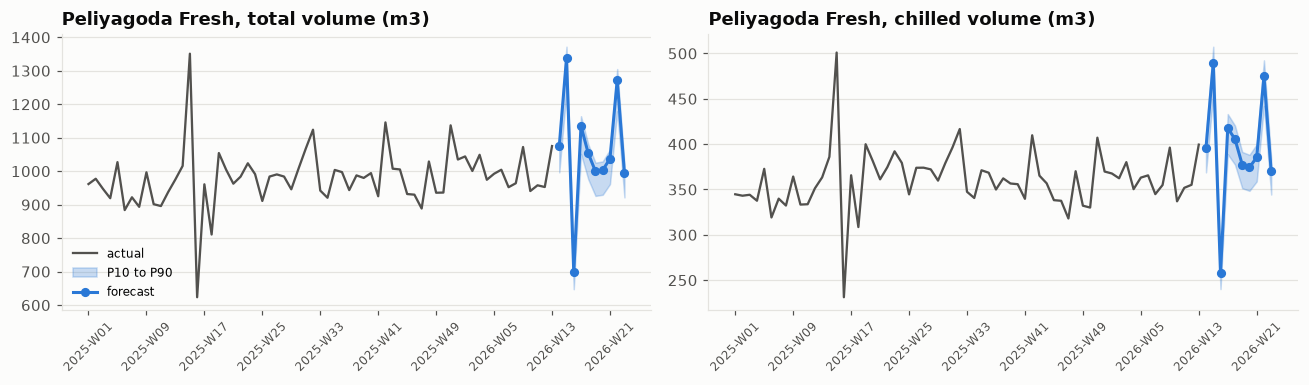

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=False)
for ax, (depot, brand, measure) in zip(axes, [("Peliyagoda", "Fresh", "total"), ("Peliyagoda", "Fresh", "chilled")]):
    hist = weekly[(weekly.depot == depot) & (weekly.brand == brand) & (weekly.measure == measure)]
    hist = hist[(hist.iso_year == 2025) | ((hist.iso_year == 2026))]
    f = fcst[(fcst.depot == depot) & (fcst.brand == brand) & (fcst.measure == measure)]
    xh = np.arange(len(hist)); xf = np.arange(len(hist), len(hist) + len(f))
    ax.plot(xh, hist.y, color=INK_SOFT, linewidth=1.5, label="actual")
    ax.fill_between(xf, f.p10, f.p90, color=SERIES[0], alpha=0.25, label="P10 to P90")
    ax.plot(xf, f.p50, color=SERIES[0], marker="o", markersize=5, label="forecast")
    ticks = list(range(0, len(hist) + len(f), 8))
    labels = [f"{y}-W{w:02d}" for y, w in pd.concat([hist, f])[["iso_year", "iso_week"]].to_numpy()]
    ax.set_xticks(ticks, [labels[i] for i in ticks], fontsize=8, rotation=45)
    ax.set_title(f"{depot} {brand}, {measure} volume (m3)")
axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

The forecast repeats the shape of the 2025 festival season, but on the 2026 calendar. The busy run-up to New Year lands in week 15 and the dip in week 16, which has only four operating days. Vesak and Poson carry their pre-festival lift in their new weeks, 18 and 22.

In [93]:
template = pd.read_csv(raw_file("submission_task2a.csv"))
inputs = pd.read_csv(raw_file("task2a_test_inputs.csv"))
wide = fcst.pivot_table(index=["depot", "brand", "iso_year", "iso_week"], columns="measure", values="p50").reset_index()
sub = inputs.merge(wide, on=["depot", "brand", "iso_year", "iso_week"], how="left", validate="one_to_one")
sub["pred_total_volume_m3"] = sub["total"].round(3)
sub["pred_chilled_volume_m3"] = np.where(sub.brand == "Fresh", np.minimum(sub["chilled"].fillna(0), sub["total"]), 0.0).round(3)
submission = template[["row_id"]].merge(sub[["row_id", "pred_total_volume_m3", "pred_chilled_volume_m3"]], on="row_id", how="left")

checks = {
    "same row ids in the same order as the template": submission.row_id.equals(template.row_id),
    "columns match the template": list(submission.columns) == list(template.columns),
    "no blanks": bool(submission.notna().all().all()),
    "volumes are positive": bool((submission.pred_total_volume_m3 > 0).all()),
    "chilled is 0 for Style and Tech": bool((sub.loc[sub.brand != "Fresh", "pred_chilled_volume_m3"] == 0).all()),
    "chilled never exceeds total": bool((submission.pred_chilled_volume_m3 <= submission.pred_total_volume_m3).all()),
}
assert all(checks.values()), checks
SUBMISSIONS.mkdir(exist_ok=True)
submission.to_csv(SUBMISSIONS / "submission_task2a.csv", index=False)
pd.Series(checks, name="passed").to_frame()

,passed
same row ids in the same order as the template,True
columns match the template,True
no blanks,True
volumes are positive,True
chilled is 0 for Style and Tech,True
chilled never exceeds total,True


In [94]:
save_processed(fcst, "task2a_forecast")

MODELS.mkdir(exist_ok=True)
joblib.dump(final_reg, MODELS / "demand_regression.pkl")
joblib.dump(final_gbm, MODELS / "demand_calendar_gbm.pkl")

manifest_path = MODELS / "manifest.json"
manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
manifest["task2a"] = {
    "files": ["demand_regression.pkl", "demand_calendar_gbm.pkl"],
    "method": "daily forecasts added up into ISO weeks; 50/50 blend of the two models",
    "trained_on": f"{panel.date.min().date()} to {panel.date.max().date()}",
    "forecast_days": f"{FORECAST_START.date()} to {FORECAST_END.date()}",
    "backtest_origins": [str(o.date()) for o in ORIGINS],
    "backtest_blend": {m: {k: float(overall.loc["blend", (m, k)]) for k in ["WAPE", "vs last year", "bias"]} for m in ["total", "chilled"]},
    "interval_coverage_leave_one_out": float(np.mean(coverage)),
    "seed": fc.SEED,
    "versions": {"lightgbm": lgb.__version__, "pandas": pd.__version__, "numpy": np.__version__},
}
manifest_path.write_text(json.dumps(manifest, indent=2))
manifest["task2a"]["backtest_blend"]

{'total': {'WAPE': 0.051628969086188074,
  'vs last year': 0.5914691290883674,
  'bias': 0.0059133382430254355},
 'chilled': {'WAPE': 0.03618647177657156,
  'vs last year': 0.4625501628207903,
  'bias': 0.015612788430270983}}

### Part 7 summary

- **Forecast days, report weeks.** Festival effects are learned per day, so the 2026 weekly totals follow the 2026 calendar instead of copying last year's weeks.
- **Backtested like the real task:** six 10-week forecasts over a full year, including the April festival window. The blend beats "same week last year" overall and by a wide margin around the festivals.
- **Honest ranges:** P10 to P90 bands, checked on backtests they were not built from, cover about three quarters of weeks.
- **Rules respected:** every order counted once by order date, weeks from the calendar, chilled is 0 for Style and Tech and never above total.

Part 9 turns the chilled forecast and its P90 into a weekly reefer outlook for planners.

## Part 8. Task 2B: peak-day fleet allocation

**Purpose:** plan scenario S1, a peak day at Peliyagoda just before a festival with ten vehicles in the workshop. Every order is either served on a named vehicle and trip, or deferred with a reason.

**Approach in one paragraph.** The plan is found by an optimiser, not by hand. It follows Waypoint's operating rules exactly and chooses between valid plans by a fixed order of priorities, agreed with the business before any numbers were run. Each priority is solved to its best value and locked in before the next one is looked at, so nothing lower down can buy itself a better score by giving up something more important. We then prove which deferrals were forced and which were choices, put a price on each choice, replay the plan on the clock against store windows, and test what each workshop repair would be worth.

**Inputs:** the S1 orders and fleet status, `vehicles.csv`, `district_travel.csv`, `service_allowance.csv`, and the route history from Part 4 for the clock check.

**Outputs:**
- `submissions/submission_task2b.csv`, checked with Waypoint's allocation checker
- `data/processed/task2b_plan.parquet` and `task2b_timeline.parquet` for Part 9
- the numbers behind the one-page policy in `docs/task2b_policy.md`

In [95]:
scenarios = load_raw("task2b_peak_day_scenarios.csv")
fleet = load_raw("task2b_peak_day_fleet.csv")
vehicles = load_raw("vehicles.csv")
travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")

prob = al.load_problem(scenarios, fleet, vehicles, travel, allowance, scenario="S1")
orders, avail = prob.orders.reset_index(drop=True), prob.vehicles.reset_index(drop=True)
print(f"{len(orders)} orders, {orders.order_volume_m3.sum():.1f} m3, all for {orders.depot.unique()[0]}")
print(f"{len(avail)} vehicles available, {(fleet.status != 'available').sum()} in the workshop")

85 orders, 409.9 m3, all for Peliyagoda
28 vehicles available, 10 in the workshop


### 8.1 The day at a glance

The question is not whether the fleet has enough space overall. It is whether it has the right kind of space in the right place: chilled goods can only ride on a reefer, a trip can only serve one brand in one district, and the pre-dawn Fresh window is only 270 minutes long.

In [96]:
v = avail.assign(kind=np.where(avail.temp == "reefer", "reefer", "ambient") + " " + avail.type)
fleet_view = v.groupby("kind").agg(vehicles=("vehicle_id", "size"), m3_per_trip=("volume_cap_m3", "sum"))
workshop = fleet[fleet.status != "available"].merge(vehicles, on="vehicle_id")
fleet_view["in_workshop"] = workshop.assign(kind=np.where(workshop.temp == "reefer", "reefer", "ambient") + " " + workshop.type
                                            ).groupby("kind").size().reindex(fleet_view.index).fillna(0).astype(int)

demand = orders.assign(kind=orders.brand + " " + orders.temp_requirement).groupby("kind").agg(
    orders=("order_ref", "size"), m3=("order_volume_m3", "sum"), kg=("order_weight_kg", "sum"))
display(fleet_view.round(1), demand.round(1))

,vehicles,m3_per_trip,in_workshop
kind,,,
ambient truck,22,656.0,5
ambient van,2,17.0,0
reefer truck,3,79.2,4
reefer van,1,7.0,1


,orders,m3,kg
kind,,,
Fresh ambient,49,133.0,24838.4
Fresh chilled,26,181.6,32780.4
Style ambient,5,77.2,4878.3
Tech ambient,5,18.1,5642.3


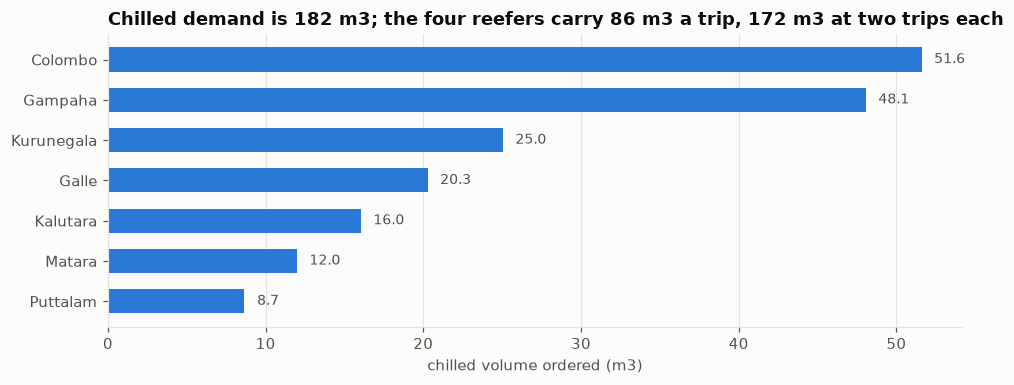

In [97]:
reefer_cap = avail.loc[avail.temp == "reefer", "volume_cap_m3"].sum()
chilled = orders[orders.temp_requirement == "chilled"]
by_district = chilled.groupby("district").order_volume_m3.sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(by_district.index, by_district.values, color=SERIES[0], height=0.6)
for y, val in enumerate(by_district.values):
    ax.text(val + 0.8, y, f"{val:.1f}", va="center", color=INK_SOFT, fontsize=9)
ax.set_xlabel("chilled volume ordered (m3)")
ax.set_title(f"Chilled demand is {chilled.order_volume_m3.sum():.0f} m3; the four reefers carry {reefer_cap:.0f} m3 a trip, {2 * reefer_cap:.0f} m3 at two trips each")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Two facts set up the whole day:
- **Ambient space is plentiful.** 22 ambient trucks and two ambient vans are free, far more than the ambient orders need.
- **Chilled space is not.** Four of the seven reefer trucks and the second reefer van are in the workshop. Even if every remaining reefer ran two full trips, it could not carry all the chilled orders, and far districts like Galle, Matara and Puttalam take most of a reefer's 270 pre-dawn minutes on their own.

So the real decisions of the day are about the reefers.

### 8.2 Deferrals that no plan can avoid

Before optimising anything, we check which orders cannot be served by any vehicle at all, whatever else happens. An order is impossible when no available vehicle may carry it (depot, reefer and van rules) or when it is bigger than every such vehicle, since orders cannot be split.

In [98]:
def best_vehicle(order):
    ok = [veh for _, veh in prob.vehicles.iterrows() if veh.depot == order.depot
          and (order.temp_requirement != "chilled" or veh.temp == "reefer")
          and (order.parking_constraint != "van_only" or veh.type == "van")]
    return max(ok, key=lambda veh: veh.volume_cap_m3) if ok else None

impossible = []
for _, o in orders.iterrows():
    if not any(prob.can_carry(o, veh) for _, veh in prob.vehicles.iterrows()):
        veh = best_vehicle(o)
        impossible.append({"order_ref": o.order_ref, "outlet_id": o.outlet_id, "brand": o.brand, "district": o.district,
                           "order_m3": o.order_volume_m3, "order_kg": o.order_weight_kg,
                           "largest_allowed_vehicle": veh.vehicle_id, "its_m3": veh.volume_cap_m3, "its_kg": veh.weight_cap_kg})
pd.DataFrame(impossible)

,order_ref,outlet_id,brand,district,order_m3,order_kg,largest_allowed_vehicle,its_m3,its_kg
0,S1-078,OUT070,Style,Kurunegala,40.66,2561.6,VEH011,38.0,7200


Only one order is impossible: **S1-078**, a 40.7 m3 Style order for OUT070 in Kurunegala. The biggest vehicle in the fleet holds 38 m3 and Waypoint does not split orders, so it is deferred whatever we do. The fix is commercial, not operational: ask the outlet to split it into two orders for two days, or send it as two orders tomorrow.

Every other deferral below is a choice the plan makes, and section 8.5 puts a price on each one.

### 8.3 The optimiser

**Decisions.** For every order, vehicle and trip (1 or 2) there is a yes or no: does this order ride on this trip? For every trip there is a choice of one brand and district, or none.

**Rules, all hard constraints:**
- each order rides at most once and is never split
- a trip carries one brand in one district
- chilled orders only on reefers, `van_only` outlets only by van, vehicles only serve their own depot
- volume and weight within the vehicle's caps on every trip
- at most two trips per vehicle; planned minutes (drive out, hops between stops, handling allowance) within 270 for Fresh trips and 480 for Style and Tech trips, per vehicle

**Priorities, in order:**

| # | Priority | Why it comes here |
|---|---|---|
| 1 | Serve orders that were deferred yesterday | an outlet should never miss two days in a row |
| 2 | Serve chilled volume | it spoils, and only reefers can carry it |
| 3 | Serve Fresh ambient volume | Fresh shelves must be stocked before 8 AM |
| 4 | Serve the most volume overall | Style and Tech can wait a day more easily than Fresh |
| 5 | Run the fewest second pre-dawn trips | a vehicle that drives back and reloads rarely makes the 8 AM opening (section 8.6) |
| 6 | Drive the fewest kilometres | cheapest plan among equally good ones |

**One refinement to priority 2.** Many chilled plans are almost tied, and the one with the very most volume is not always the one that reaches the most stores. So the chilled step may give up at most 1% of the best chilled volume, uses that room to get chilled orders to as many stores as possible, and then wins back as much chilled volume as it can while still reaching those stores. Section 8.3.1 shows what this buys.

**How it is solved.** Chilled orders compete only for the four reefers, so we solve in two stages. Stage 1 packs the chilled orders onto the reefers. Stage 2 keeps those reefer loads and plans every other order on the whole fleet, topping up reefer trips with ambient orders where there is room. This is exact for priorities 1 to 4 as long as stage 2 serves every ambient order, which we check below. Both stages are mixed integer programmes solved with CBC through PuLP.

In [99]:
plan, achieved = al.plan_day(prob, time_limit=120)

steps = pd.DataFrame([(name, label, achieved["stage2"][name], achieved["proven"]["stage2"][name])
                      for name, _, label, _ in al.PRIORITIES], columns=["step", "meaning", "plan value", "proven best"])
steps

,step,meaning,plan value,proven best
0,repeat_deferrals_served,orders deferred yesterday that are served today,10.000,True
1,chilled_m3,chilled volume served (m3),132.586,True
2,chilled_orders,outlets that get their chilled order,18.000,True
3,chilled_m3_for_those_outlets,"chilled volume served, reaching those outlets (m3)",132.586,True
4,fresh_ambient_m3,Fresh ambient volume served (m3),132.968,True
5,total_m3,total volume served (m3),320.161,True
6,second_fresh_trips,vehicles running a second pre-dawn Fresh trip,4.000,True
7,trip_km,"kilometres driven, depot and back",4218.000,False


In [100]:
ambient = plan[plan.temp_requirement == "ambient"]
unserved_ambient = ambient[(ambient.decision == "deferred") & ~ambient.order_ref.isin([r["order_ref"] for r in impossible])]
print("ambient orders left unserved that some vehicle could carry:", len(unserved_ambient))
assert unserved_ambient.empty, "stage 2 left ambient work behind, so the two-stage solve is no longer exact"

ambient orders left unserved that some vehicle could carry: 0


Every ambient order that fits on any vehicle is served, so the two-stage solve loses nothing on priorities 1 to 4, and all of them are proven best. The only second pre-dawn trips left are the four reefers', which the chilled priority needs. The kilometre step stops on its time limit, so the distance is a good plan rather than a proven minimum; it never trades away anything above it.

#### 8.3.1 Why the 1% matters

The same stage 1 solved with no slack on chilled volume shows what the refinement changes.

In [101]:
reefer_prob = prob.subset(lambda o: o.temp_requirement == "chilled", lambda v: v.temp == "reefer")
strict_priorities = [(n, s, l, 0.0) for n, s, l, _ in al.REEFER_PRIORITIES]
strict, strict_got = al.AllocationModel(reefer_prob).solve(strict_priorities)
ours = plan[plan.temp_requirement == "chilled"]

def chilled_summary(p):
    served = p[p.decision == "served"]
    return {"chilled m3 served": round(served.order_volume_m3.sum(), 3),
            "outlets that get chilled": served.outlet_id.nunique(),
            "reefer km for the chilled loads": int(al.trip_table(served, prob).km.sum()),
            "districts with no chilled delivery": ", ".join(sorted(set(p.district) - set(served.district))) or "none"}

pd.DataFrame({"strict volume first": chilled_summary(strict), "with the 1% refinement": chilled_summary(ours)})

,strict volume first,with the 1% refinement
chilled m3 served,132.8,132.6
outlets that get chilled,17,18
reefer km for the chilled loads,1130,1138
districts with no chilled delivery,Kurunegala,Kurunegala


For a quarter of a cubic metre of chilled goods, about 0.2% of what the reefers carry, the refined plan gets chilled goods to one more store. Setting the slack to zero gives back the strict plan with no other change, so the business can choose.

### 8.4 The plan

One row per trip. The trip numbers here are the optimiser's; section 8.6 renumbers them so trip 1 is always the one that leaves first.

In [102]:
trips = al.trip_table(plan, prob)
show = trips.assign(volume_fill=(trips.volume_fill * 100).round(0).astype(int).astype(str) + "%",
                    weight_fill=(trips.weight_fill * 100).round(0).astype(int).astype(str) + "%")
show[["vehicle_id", "trip_id", "type", "temp", "brand", "district", "orders", "chilled_orders",
      "volume_m3", "volume_fill", "weight_fill", "planned_min", "km"]].round(1)

,vehicle_id,trip_id,type,temp,brand,district,orders,chilled_orders,volume_m3,volume_fill,weight_fill,planned_min,km
0,VEH003,1,truck,reefer,Fresh,Gampaha,2,2,21.8,83%,73%,76,63.0
1,VEH003,2,truck,reefer,Fresh,Puttalam,1,1,8.7,33%,29%,188,260.0
2,VEH006,1,truck,reefer,Fresh,Colombo,4,4,32.8,98%,82%,109,36.0
3,VEH006,2,truck,reefer,Fresh,Gampaha,4,4,26.2,79%,69%,125,77.0
4,VEH007,1,truck,reefer,Fresh,Galle,1,1,16.5,85%,76%,118,240.0
5,VEH007,2,truck,reefer,Fresh,Kalutara,3,3,16.0,83%,81%,134,114.0
6,VEH008,1,truck,ambient,Fresh,Gampaha,6,0,19.7,89%,96%,173,91.0
7,VEH008,2,truck,ambient,Tech,Matara,1,0,1.6,7%,13%,180,320.0
8,VEH009,1,truck,ambient,Fresh,Galle,6,0,15.3,51%,47%,242,290.0
9,VEH011,1,truck,ambient,Fresh,Colombo,9,0,31.4,83%,83%,226,56.0


In [103]:
served = plan[plan.decision == "served"]
summary = pd.DataFrame({
    "orders": plan.groupby("temp_requirement").order_ref.size(),
    "served": served.groupby("temp_requirement").order_ref.size(),
    "m3 ordered": plan.groupby("temp_requirement").order_volume_m3.sum(),
    "m3 served": served.groupby("temp_requirement").order_volume_m3.sum(),
})
summary.loc["all"] = summary.sum()
summary["share of m3 served"] = (summary["m3 served"] / summary["m3 ordered"] * 100).round(1).astype(str) + "%"
print(f"{len(trips)} trips on {trips.vehicle_id.nunique()} vehicles, {trips.km.sum():.0f} km")
summary.round(1)

24 trips on 17 vehicles, 4218 km


,orders,served,m3 ordered,m3 served,share of m3 served
temp_requirement,,,,,
ambient,59.0,58.0,228.2,187.6,82.2%
chilled,26.0,18.0,181.6,132.6,73.0%
all,85.0,76.0,409.9,320.2,78.1%


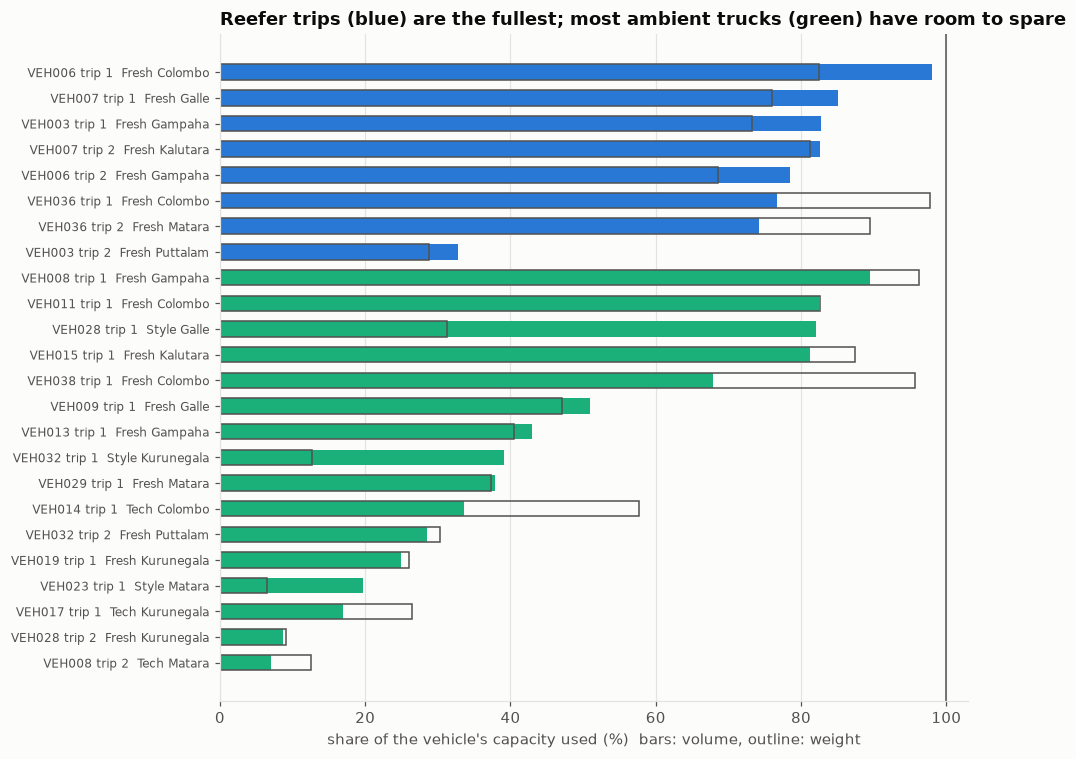

In [104]:
t = trips.sort_values(["temp", "volume_fill"])
labels = t.vehicle_id + " trip " + t.trip_id.astype(str) + "  " + t.brand + " " + t.district
colors = np.where(t.temp == "reefer", SERIES[0], SERIES[2])

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(labels, t.volume_fill * 100, color=colors, height=0.6)
ax.barh(labels, t.weight_fill * 100, color="none", edgecolor=INK_SOFT, height=0.6, linewidth=1)
ax.axvline(100, color=INK_SOFT, linewidth=1)
ax.set_xlabel("share of the vehicle's capacity used (%)  bars: volume, outline: weight")
ax.set_title("Reefer trips (blue) are the fullest; most ambient trucks (green) have room to spare")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

### 8.5 Every deferral, explained

Each deferred order gets a reason code and, where it was a choice, a price. The price comes from re-solving stage 1 with that one order forced onto a reefer and every chilled priority still in place: how many fewer stores would get their chilled goods, and how much chilled volume would change.

| Code | Meaning |
|---|---|
| `TOO_BIG_FOR_ANY_VEHICLE` | bigger than every vehicle allowed to carry it; unavoidable |
| `REEFER_CAPACITY` | chilled space is the binding limit; serving it pushes out other chilled volume |

In [105]:
base_chilled = ours.loc[ours.decision == "served", "order_volume_m3"].sum()
base_outlets = ours.loc[ours.decision == "served", "outlet_id"].nunique()
chilled_steps = [p for p in al.REEFER_PRIORITIES if p[0] != "trip_km"]
rows = []
for _, o in plan[plan.decision == "deferred"].iterrows():
    row = {"order_ref": o.order_ref, "outlet_id": o.outlet_id, "brand": o.brand, "district": o.district,
           "temp": o.temp_requirement, "m3": o.order_volume_m3, "days_since_served": o.days_since_last_served}
    if o.order_ref in [r["order_ref"] for r in impossible]:
        row.update(reason="TOO_BIG_FOR_ANY_VEHICLE")
    else:
        forced, _ = al.AllocationModel(reefer_prob).solve(chilled_steps, force={o.order_ref: 1})
        fs = forced[forced.decision == "served"]
        row.update(reason="REEFER_CAPACITY",
                   chilled_stores_change_if_served=fs.outlet_id.nunique() - base_outlets,
                   chilled_m3_change_if_served=round(fs.order_volume_m3.sum() - base_chilled, 2))
    rows.append(row)
deferrals = pd.DataFrame(rows).sort_values(["reason", "chilled_m3_change_if_served"], ascending=[True, False])
deferrals.round(2)

,order_ref,outlet_id,brand,district,temp,m3,days_since_served,reason,chilled_stores_change_if_served,chilled_m3_change_if_served
2,S1-021,OUT013,Fresh,Colombo,chilled,9.90,1,REEFER_CAPACITY,0.0,-0.19
3,S1-056,OUT053,Fresh,Galle,chilled,3.75,2,REEFER_CAPACITY,0.0,-0.54
5,S1-071,OUT065,Fresh,Kurunegala,chilled,12.04,1,REEFER_CAPACITY,0.0,-0.96
6,S1-073,OUT066,Fresh,Kurunegala,chilled,5.77,1,REEFER_CAPACITY,0.0,-0.96
7,S1-075,OUT067,Fresh,Kurunegala,chilled,7.24,2,REEFER_CAPACITY,0.0,-0.96
0,S1-003,OUT002,Fresh,Colombo,chilled,1.84,1,REEFER_CAPACITY,1.0,-1.63
1,S1-005,OUT003,Fresh,Colombo,chilled,1.72,2,REEFER_CAPACITY,1.0,-1.63
4,S1-064,OUT060,Fresh,Matara,chilled,6.78,1,REEFER_CAPACITY,0.0,-8.95
8,S1-078,OUT070,Style,Kurunegala,ambient,40.66,2,TOO_BIG_FOR_ANY_VEHICLE,NaN,NaN


How to read the price. Serving a deferred chilled order always pushes other chilled goods off a reefer, so every swap costs chilled volume. Most swaps keep the same number of stores and cost under 1 m3; the Matara order would cost about 9 m3. The two `van_only` Colombo stores are the exception: serving one of them would reach one more store, but only by giving up 1.6 m3, more than the 1% the policy allows, because the single reefer van has to drop a bigger order to carry it. When a store manager pushes back, this table is the dispatcher's answer: the swap is possible, and here is what it costs.

None of the deferred orders were also deferred yesterday, so priority 1 holds in full: all ten repeat deferrals ride today. Every order deferred today becomes a priority 1 order tomorrow.

### 8.6 Will it arrive on time?

The planning standard counts minutes but does not look at the clock. It leaves out the drive back to the depot between two trips, and it ignores store opening times, so a truck that reaches a store at 04:10 when it opens at 05:30 simply waits. We replay every vehicle's day on the clock:
- Fresh trips start from 03:30, Style and Tech trips from 07:30
- a vehicle leaves no earlier than it needs to reach its first store as it opens
- stops are visited in the order with the fewest late arrivals
- a second trip in the same window loads only after the first one drives back
- when a vehicle has two trips in one window, both orders are tried and the better one is kept

We replay twice: once on the planning standard (free-flow drive times, handling exactly as allowed) and once on a **typical day**, using the median drive-time and handling ratios and the median depot delay from the route history, the same history the Task 1 models learned from.

In [106]:
history = load_processed("stops")
history = history[history.service_min.notna()].merge(load_processed("service_allowance"), on=["brand", "dock_type"])
travel_ratio = (history.actual_travel_duration_min / history.planned_travel_duration_min.clip(lower=1)
                ).groupby([history.brand, history.district]).median().to_dict()
service_ratio = (history.service_min / history.service_allowance_min).groupby([history.brand, history.dock_type]).median().to_dict()
first_legs = history[history.seq == 0]
depart_delay = float((first_legs.actual_depart_time_min - first_legs.planned_depart_time_min).median())

tl_standard = al.timeline(plan, prob)
tl_typical = al.timeline(plan, prob, travel_ratio=travel_ratio, service_ratio=service_ratio, depart_delay=depart_delay)
pd.DataFrame({
    "late stops": [tl_standard.late.sum(), tl_typical.late.sum()],
    "late chilled stops": [(tl_standard.late & (tl_standard.temp_requirement == "chilled")).sum(),
                           (tl_typical.late & (tl_typical.temp_requirement == "chilled")).sum()],
    "served stops": [len(tl_standard), len(tl_typical)],
}, index=["planning standard", "typical day"])

,late stops,late chilled stops,served stops
planning standard,5,5,76
typical day,11,7,76


In [107]:
cols = ["vehicle_id", "run", "brand", "district", "order_ref", "outlet_id", "temp_requirement",
        "depart", "arrive", "window_open_time", "window_close_time", "late_by_min"]
tl_standard.loc[tl_standard.late, cols].round(0)

,vehicle_id,run,brand,district,order_ref,outlet_id,temp_requirement,depart,arrive,window_open_time,window_close_time,late_by_min
2,VEH003,2,Fresh,Puttalam,S1-083,OUT074,chilled,05:23,08:16,05:30,08:00,16.0
9,VEH006,2,Fresh,Gampaha,S1-033,OUT029,chilled,06:49,08:14,05:30,08:00,14.0
10,VEH006,2,Fresh,Gampaha,S1-031,OUT028,chilled,06:49,08:38,03:00,08:00,38.0
14,VEH007,2,Fresh,Galle,S1-058,OUT054,chilled,07:14,08:57,05:00,07:30,87.0
70,VEH036,2,Fresh,Matara,S1-067,OUT062,chilled,06:10,08:27,05:30,08:00,27.0


On the standard itself, the late stops all sit on **second pre-dawn trips**. The standard lets each reefer run two trips in the 270 minutes, but once the drive back and the store opening times are counted, the second trip reaches some of its stores after 08:00. Spare ambient trucks never run a second pre-dawn trip, which is what priority 5 is for. On a typical day, with real drive times about 30 to 70% above free flow, more stops slip.

This does not change the plan, which follows Waypoint's planning standard. It changes what the dispatcher does with it:
- the late stops are known the evening before, so their store managers can be told to expect a late morning delivery and plan staff for it
- the drivers of second trips get the clock times from this replay, not the planning minutes
- these stops are exactly the ones the Task 1 late-risk model should watch on the day

The plan's trip numbers now follow the run order from the replay, so trip 1 is always the one that leaves first.

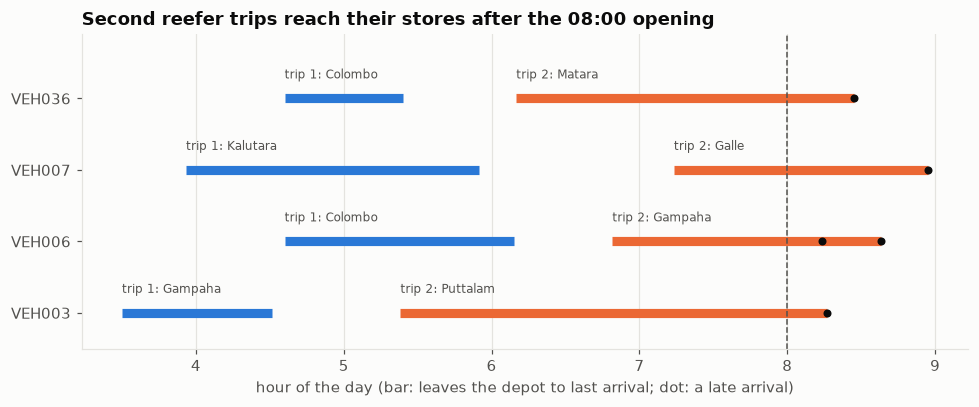

In [108]:
plan = al.renumber_trips(plan, tl_standard)
tl_standard = al.timeline(plan, prob)
trips = al.trip_table(plan, prob)

reefers = tl_standard[tl_standard.vehicle_id.isin(avail.loc[avail.temp == "reefer", "vehicle_id"])]
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, (vid, g) in enumerate(reefers.groupby("vehicle_id")):
    for run, r in g.groupby("run"):
        start, end = r.depart_min.min() / 60, r.arrive_min.max() / 60
        ax.plot([start, end], [i, i], color=SERIES[run - 1], linewidth=6, solid_capstyle="butt")
        ax.text(start, i + 0.28, f"trip {run}: {r.district.iloc[0]}", fontsize=8, color=INK_SOFT)
    late = g[g.late]
    ax.scatter(late.arrive_min / 60, [i] * len(late), color=INK, zorder=3, s=18)
ax.axvline(8, color=INK_SOFT, linewidth=1, linestyle="--")
ax.set_ylim(-0.5, reefers.vehicle_id.nunique() - 0.1)
ax.set_yticks(range(reefers.vehicle_id.nunique()), sorted(reefers.vehicle_id.unique()))
ax.set_xlabel("hour of the day (bar: leaves the depot to last arrival; dot: a late arrival)")
ax.set_title("Second reefer trips reach their stores after the 08:00 opening")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### 8.7 What a workshop repair is worth

Five reefers are in the workshop: four trucks and one van. If the workshop can return one of them for the morning run, which should it be? We re-solve stage 1 with each one added back. Only stage 1 is needed, because ambient work is already fully served.

In [109]:
workshop_reefers = workshop.loc[workshop.temp == "reefer", "vehicle_id"].tolist()
repair = []
for vid in workshop_reefers:
    p2 = al.load_problem(scenarios, fleet, vehicles, travel, allowance, scenario="S1", extra_vehicles=[vid])
    r2 = p2.subset(lambda o: o.temp_requirement == "chilled", lambda v: v.temp == "reefer")
    pl2, _ = al.AllocationModel(r2).solve(al.REEFER_PRIORITIES)
    s2 = pl2[pl2.decision == "served"]
    veh = vehicles.set_index("vehicle_id").loc[vid]
    repair.append({"vehicle_id": vid, "type": veh.type, "m3": veh.volume_cap_m3,
                   "extra chilled m3": round(s2.order_volume_m3.sum() - base_chilled, 1),
                   "extra outlets with chilled": s2.outlet_id.nunique() - ours[ours.decision == "served"].outlet_id.nunique()})
repair = pd.DataFrame(repair).sort_values("extra chilled m3", ascending=False)
repair

,vehicle_id,type,m3,extra chilled m3,extra outlets with chilled
2,VEH004,truck,33.4,35.3,5
3,VEH005,truck,33.4,35.3,5
0,VEH001,truck,26.4,34.8,5
1,VEH002,truck,21.1,33.3,5
4,VEH035,van,7.0,9.6,2


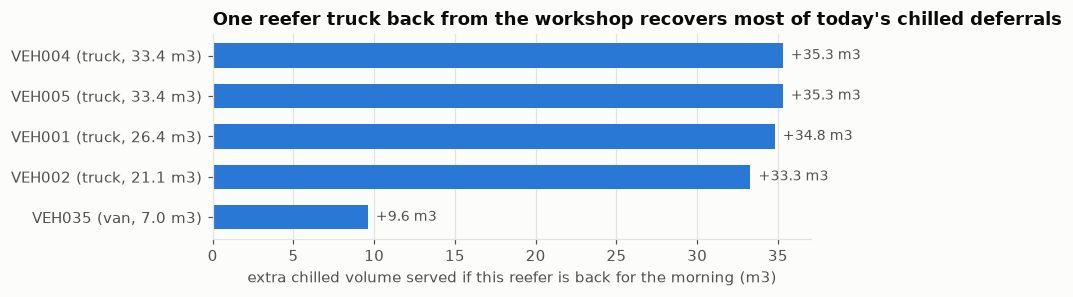

In [110]:
fig, ax = plt.subplots(figsize=(8, 2.8))
r = repair.sort_values("extra chilled m3")
ax.barh(r.vehicle_id + " (" + r.type + ", " + r.m3.astype(str) + " m3)", r["extra chilled m3"], color=SERIES[0], height=0.6)
for y, val in enumerate(r["extra chilled m3"]):
    ax.text(val + 0.5, y, f"+{val:.1f} m3", va="center", color=INK_SOFT, fontsize=9)
ax.set_xlabel("extra chilled volume served if this reefer is back for the morning (m3)")
ax.set_title("One reefer truck back from the workshop recovers most of today's chilled deferrals")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Any one of the large reefer trucks recovers most of the chilled volume deferred today. The reefer van is worth much less in volume, but it is the only way to reach the `van_only` outlets with chilled goods, so it matters for those three stores. This is the ranking to give the workshop on a peak day: large reefer trucks first, then the reefer van.

### 8.8 Write and check the submission

The submission is checked with Waypoint's own allocation checker, `check_allocation.py`, exactly as shipped.

In [111]:
submission = al.to_submission(plan, scenario="S1")
template = load_raw("submission_task2b.csv")
assert list(submission.columns) == list(template.columns)
assert set(submission.order_ref) == set(template.order_ref)
SUBMISSIONS.mkdir(exist_ok=True)
path = SUBMISSIONS / "submission_task2b.csv"
submission.to_csv(path, index=False)

result = subprocess.run([sys.executable, "check_allocation.py", str(path)], cwd=REPO_ROOT, capture_output=True, text=True)
print(result.stdout)
assert result.returncode == 0
submission.decision.value_counts()

FEASIBILITY: PASSED - every rule satisfied.



decision
served      76
deferred     9
Name: count, dtype: int64

In [112]:
save_processed(plan, "task2b_plan")
save_processed(tl_standard, "task2b_timeline")
save_processed(deferrals, "task2b_deferrals")

### Part 8 summary

- **Feasible:** the plan passes Waypoint's allocation checker. 76 of 85 orders ride on 24 trips.
- **Priority 1 holds in full:** all ten orders deferred yesterday are served today.
- **Chilled is the bottleneck, and the plan is proven best on it:** no valid plan serves more than about 133 m3 of the 182 m3 ordered with four reefers in the workshop. We serve 132.6 m3, giving up 0.25 m3 to reach one more store.
- **All Fresh ambient and all servable Style and Tech orders ride today.**
- **One deferral is unavoidable** (S1-078, bigger than any truck). The other eight are chilled orders, each priced by who would lose out if it were served instead.
- **The clock check** finds the second pre-dawn reefer trips that will reach stores after opening, so the dispatcher can warn those stores the evening before.
- **Repair ranking:** one large reefer truck back from the workshop recovers most of today's chilled deferrals.

Part 9 turns this plan into plain instructions for the dispatcher, loaders, drivers and store managers.

## Part 9. The decision layer

**Purpose:** turn the model outputs from Parts 6 to 8 into what each person at Waypoint actually needs to act on. The dispatcher, loaders, drivers and store managers are not data people. A late probability of 0.63 or a forecast error of 7% means nothing to a driver at 3 AM.

**Rules every output follows:**
- **Clock times, not probabilities.** "Arrives 06:10 to 06:40", not "P(late) = 0.31".
- **Ranges, not single numbers**, so nobody is misled by false precision.
- **A traffic light always comes with an action.**
- **One reason line**, taken from the features that pushed the risk up the most.

**Who gets what:**

| Role | When | Output | Section |
|---|---|---|---|
| Dispatcher | after the 4 PM cutoff | risk board: every route with red, amber and green stops, a reason and a suggested fix | 9.2 |
| Driver | before leaving the depot | run sheet: windows, arrival ranges, unloading minutes, risky stops | 9.3 |
| Store manager | the evening before | a short message with the arrival range | 3, 4 |
| Dispatcher | on a peak day | deferral list with reasons, and a notice for each store | 9.4 |
| Loader | before loading | load order per trip, chilled section, how full the vehicle is | 9.4 |
| Fleet manager | weekly | reefer outlook for the next 10 weeks, and when to book reefer maintenance | 9.5 |

**Inputs:** the saved Task 1 models, the Task 1 and 2A predictions, and the Task 2B plan from Part 8.

**Outputs:** sample sheets and messages in `reports/decision_layer/`, ready to show the people who would use them.

In [113]:
OUT = REPORTS / "decision_layer"
OUT.mkdir(parents=True, exist_ok=True)
LIGHTS = {"red": "#f6d5cf", "amber": "#fbe8c0", "green": "#d6efe2"}

def paint(df, col="light"):
    return df.style.apply(lambda r: [f"background-color: {LIGHTS.get(r[col], '')}"] * len(r), axis=1).hide(axis="index")

### 9.1 Rebuild the Task 1 view of the test period

The saved models are reloaded exactly as Part 11 reloads them. The route simulator gives each stop an arrival range (the middle and the slow end of 1,000 replays), the submission gives the late risk, and the challenger classifier splits each stop's risk into one contribution per feature, which becomes the reason line.

**Thresholds.** Part 6 showed the late-risk blend is calibrated on the holdout: across risk bands, the share of stops that ran late matched the predicted risk. So the lights can be set in plain terms:
- **red** at 50% or more: at least half of stops like this run late
- **amber** from 25%: about one in three or four
- **green** below 25%

In [114]:
stops = load_processed("stops")
tables = dict(outlets=load_processed("outlets"), vehicles=load_processed("vehicles"),
              allowance=load_processed("service_allowance"), calendar=load_processed("calendar"),
              road=load_processed("road_conditions"), traffic=load_processed("traffic_speed"))
full = fe.model_frame(stops, fe.build_task1_features(stops, **tables))
test = full[full.split == "test"]

simulator = joblib.load(MODELS / "route_simulator.pkl")
classifier = joblib.load(MODELS / "late_classifier.pkl")
task1 = pd.read_csv(SUBMISSIONS / "submission_task1.csv")

bands = simulator.simulate(test)[["delivery_id", "arrival_p50_min", "arrival_p90_min"]]
test = test.merge(task1, on="delivery_id").merge(bands, on="delivery_id")
feats = classifier.feature_name_
contrib = pd.DataFrame(classifier.booster_.predict(test[feats], pred_contrib=True)[:, :-1], columns=feats, index=test.index)

test["light"] = test.pred_late_prob.map(dl.light)
test["reason"] = [dl.reason_line(test.loc[i], contrib.loc[i]) if test.at[i, "light"] != "green" else ""
                  for i in test.index]
test["arrives"] = [dl.arrival_range(a, b) for a, b in zip(test.arrival_p50_min, test.arrival_p90_min)]

share = test.light.value_counts().reindex(["green", "amber", "red"])
pd.DataFrame({"stops": share, "share": (share / len(test) * 100).round(1).astype(str) + "%",
              "expected late": test.groupby("light").pred_late_prob.sum().reindex(share.index).round(0)})

,stops,share,expected late
light,,,
green,3658,73.0%,96.0
amber,307,6.1%,108.0
red,1049,20.9%,899.0


Across the six test weeks about one stop in five is red, and the red stops carry most of the expected late arrivals. That is the point of the board: the dispatcher looks at a fifth of the stops and finds most of the trouble.

### 9.2 Dispatcher: the risk board

The board is built at the 4 PM cutoff for the next day's draft routes. We show the riskiest test day, 7 March 2026, a monsoon Saturday.

One row per route, worst first, with a suggested fix that depends on where the red stops sit:
- red from the first stop: the whole route starts behind, so **leave earlier**
- red only further down: **split the route** before the first red stop, or move those stops to the front

In [115]:
DAY = test.groupby("date").pred_late_prob.mean().idxmax()
day = test[test.date == DAY].sort_values(["route_id", "seq"])

board = []
for rid, g in day.groupby("route_id"):
    worst = g.loc[g.pred_late_prob.idxmax()]
    board.append({"route": rid, "depot": g.depot.iloc[0], "brand": g.brand.iloc[0], "district": g.district.iloc[0],
                  "stops": len(g), "red": int((g.light == "red").sum()), "amber": int((g.light == "amber").sum()),
                  "leaves": dl.clock(g.route_start_min.iloc[0]),
                  "worst stop": f"stop {int(worst.seq) + 1} ({worst.outlet_id})" if worst.light != "green" else "",
                  "why": worst.reason, "suggested fix": dl.route_fix(g)})
board = pd.DataFrame(board)
board["light"] = np.where(board.red > 0, "red", np.where(board.amber > 0, "amber", "green"))
board = board.sort_values(["red", "amber"], ascending=False)
board.to_csv(OUT / "dispatcher_risk_board.csv", index=False)
print(f"{DAY.date()}: {len(board)} routes, {(board.light == 'red').sum()} with at least one red stop")
paint(board.head(12))

2026-03-07: 36 routes, 25 with at least one red stop


route,depot,brand,district,stops,red,amber,leaves,worst stop,why,suggested fix,light
R025904,Peliyagoda,Fresh,Colombo,8,5,0,05:01,stop 7 (OUT011),about 87 min past the cut-off once usual traffic is counted; the plan leaves 13 min before the cut-off,"split the route after stop 3, or move the red stops to the front",red
R025878,Peliyagoda,Fresh,Kurunegala,4,4,0,02:00,stop 4 (OUT069),"road advisory for Kurunegala (46, 100 = clear); about 16 min past the cut-off once usual traffic is counted",leave earlier: the route is at risk from its first stop,red
R025895,Peliyagoda,Fresh,Kurunegala,4,4,0,03:34,stop 3 (OUT068),"road advisory for Kurunegala (46, 100 = clear); about 71 min past the cut-off once usual traffic is counted",leave earlier: the route is at risk from its first stop,red
R025874,Kandy,Fresh,Kandy,6,3,1,05:22,stop 6 (OUT081),"about 46 min past the cut-off once usual traffic is counted; road advisory for Kandy (59, 100 = clear)","split the route after stop 3, or move the red stops to the front",red
R025886,Peliyagoda,Fresh,Colombo,7,3,0,04:39,stop 7 (OUT014),about 57 min past the cut-off once usual traffic is counted; OUT014 is often slow to receive,"split the route after stop 4, or move the red stops to the front",red
R025888,Peliyagoda,Fresh,Colombo,3,3,0,06:40,stop 2 (OUT003),about 51 min past the cut-off once usual traffic is counted; planned to arrive after the cut-off,leave earlier: the route is at risk from its first stop,red
R025900,Kandy,Fresh,Kegalle,4,3,0,05:32,stop 4 (OUT119),about 101 min past the cut-off once usual traffic is counted; the plan leaves 5 min before the cut-off,"split the route after stop 1, or move the red stops to the front",red
R025901,Peliyagoda,Fresh,Gampaha,5,3,0,05:02,stop 5 (OUT031),"about 17 min past the cut-off once usual traffic is counted; road advisory for Gampaha (61, 100 = clear)","split the route after stop 2, or move the red stops to the front",red
R025897,Kandy,Fresh,Nuwara Eliya,5,2,1,03:23,stop 5 (OUT107),about 195 min past the cut-off once usual traffic is counted; OUT107 is often slow to receive,"split the route after stop 3, or move the red stops to the front",red
R025899,Peliyagoda,Fresh,Kalutara,7,2,1,03:43,stop 7 (OUT045),about 86 min past the cut-off once usual traffic is counted; OUT045 is often slow to receive,"split the route after stop 5, or move the red stops to the front",red


Each line is something the dispatcher can do before the trucks leave. Reading the reasons down the board, the same few causes come up again and again: a route that is already behind once the usual traffic is counted, and road advisories on the day. Those are exactly the drivers Part 6 found.

### 9.3 Driver run sheet and store messages

The driver of the riskiest route gets a run sheet on their phone before leaving the depot, so it works without signal. Each store on the route gets a message the evening before.

In [116]:
ROUTE = board.route.iloc[0]
r = day[day.route_id == ROUTE].sort_values("seq")
run_sheet = pd.DataFrame({
    "stop": r.seq.astype(int) + 1, "outlet": r.outlet_id,
    "window": [f"{dl.clock(a)} to {dl.clock(b)}" for a, b in zip(r.window_open_time_min, r.window_close_time_min)],
    "planned": r.planned_arrival_min.map(dl.clock), "likely arrival": r.arrives,
    "unloading": [f"about {5 * max(1, round(m / 5))} min" for m in r.pred_service_min],
    "light": r.light,
    "note": np.where(r.light == "red", "likely late: call the store before you set off for it",
                     np.where(r.light == "amber", "call ahead if you are running behind", "")),
})
run_sheet.to_csv(OUT / f"driver_run_sheet_{ROUTE}.csv", index=False)
print(f"Route {ROUTE}, {r.brand.iloc[0]} {r.district.iloc[0]}, leaves the depot {dl.clock(r.route_start_min.iloc[0])}")
paint(run_sheet)

Route R025904, Fresh Colombo, leaves the depot 05:01


stop,outlet,window,planned,likely arrival,unloading,light,note
1,OUT008,05:00 to 07:30,05:26,06:00 to 06:15,about 10 min,green,
2,OUT010,05:00 to 07:30,05:48,06:25 to 06:45,about 20 min,green,
3,OUT013,05:00 to 07:30,06:12,07:15 to 07:40,about 15 min,green,
4,OUT005,04:00 to 07:45,06:36,08:00 to 08:30,about 20 min,red,likely late: call the store before you set off for it
5,OUT006,03:00 to 08:00,06:59,08:50 to 09:25,about 25 min,red,likely late: call the store before you set off for it
6,OUT007,05:30 to 08:00,07:23,09:40 to 10:20,about 30 min,red,likely late: call the store before you set off for it
7,OUT011,03:00 to 08:00,07:47,10:35 to 11:20,about 25 min,red,likely late: call the store before you set off for it
8,OUT012,05:30 to 08:00,08:10,11:25 to 12:15,about 20 min,red,likely late: call the store before you set off for it


In [117]:
messages = pd.DataFrame({"outlet": r.outlet_id, "light": r.light, "message": [dl.store_message(x) for x in r.itertuples()]})
messages.to_csv(OUT / f"store_messages_{ROUTE}.csv", index=False)
paint(messages)

outlet,light,message
OUT008,green,"Your Fresh delivery arrives 06:00 to 06:15, usually on time."
OUT010,green,"Your Fresh delivery arrives 06:25 to 06:45, usually on time."
OUT013,green,"Your Fresh delivery arrives 07:15 to 07:40, usually on time."
OUT005,red,"Your Fresh delivery is planned for 08:00 to 08:30. It may arrive after your 07:45 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT006,red,"Your Fresh delivery is planned for 08:50 to 09:25. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT007,red,"Your Fresh delivery is planned for 09:40 to 10:20. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT011,red,"Your Fresh delivery is planned for 10:35 to 11:20. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."
OUT012,red,"Your Fresh delivery is planned for 11:25 to 12:15. It may arrive after your 08:00 cut-off, so the driver will call you on the way. Please keep the receiving bay free."


The planned arrival times on this route are the ones Waypoint uses today. The likely arrival ranges are what the route simulation expects once depot delay, real drive times and real unloading times are counted. The gap between the two columns is the reason the route is red.

### 9.4 Peak day: deferrals, loading and early warnings

Part 8 planned scenario S1. Here the plan becomes four things people use:
- the dispatcher's deferral list, with a reason and a price for each deferred order
- a notice for every store whose order moves to tomorrow
- a loading sheet for every trip
- a warning for the stores the clock check found will be reached after opening

In [118]:
plan = load_processed("task2b_plan")
timeline = load_processed("task2b_timeline")
deferrals = load_processed("task2b_deferrals")
prob = al.load_problem(load_raw("task2b_peak_day_scenarios.csv"), load_raw("task2b_peak_day_fleet.csv"),
                       load_raw("vehicles.csv"), load_raw("district_travel.csv"), load_raw("service_allowance.csv"))
trips = al.trip_table(plan, prob)

d = deferrals.merge(plan[["order_ref", "order_volume_m3", "temp_requirement"]], on="order_ref", suffixes=("", "_plan"))
def why(x):
    if x.reason == "TOO_BIG_FOR_ANY_VEHICLE":
        return f"unavoidable: {x.order_volume_m3:.1f} m3 is bigger than the largest truck (38 m3); ask the store to split it"
    swap = f"serving it instead costs {-x.chilled_m3_change_if_served:.1f} m3 of other chilled goods"
    if x.chilled_stores_change_if_served > 0:
        swap += f", though it would reach {int(x.chilled_stores_change_if_served)} more store"
    return f"reefers full: {swap}"
deferral_list = pd.DataFrame({"order": d.order_ref, "outlet": d.outlet_id, "goods": d.brand + " " + d.temp,
                              "m3": d.m3.round(1), "days since served": d.days_since_served, "why": [why(x) for x in d.itertuples()],
                              "tomorrow": "priority 1"})
deferral_list.to_csv(OUT / "peak_day_deferral_list.csv", index=False)
deferral_list

,order,outlet,goods,m3,days since served,why,tomorrow
0,S1-021,OUT013,Fresh chilled,9.9,1,reefers full: serving it instead costs 0.2 m3 of other chilled goods,priority 1
1,S1-056,OUT053,Fresh chilled,3.8,2,reefers full: serving it instead costs 0.5 m3 of other chilled goods,priority 1
2,S1-071,OUT065,Fresh chilled,12.0,1,reefers full: serving it instead costs 1.0 m3 of other chilled goods,priority 1
3,S1-073,OUT066,Fresh chilled,5.8,1,reefers full: serving it instead costs 1.0 m3 of other chilled goods,priority 1
4,S1-075,OUT067,Fresh chilled,7.2,2,reefers full: serving it instead costs 1.0 m3 of other chilled goods,priority 1
5,S1-003,OUT002,Fresh chilled,1.8,1,"reefers full: serving it instead costs 1.6 m3 of other chilled goods, though it would reach 1 more store",priority 1
6,S1-005,OUT003,Fresh chilled,1.7,2,"reefers full: serving it instead costs 1.6 m3 of other chilled goods, though it would reach 1 more store",priority 1
7,S1-064,OUT060,Fresh chilled,6.8,1,reefers full: serving it instead costs 8.9 m3 of other chilled goods,priority 1
8,S1-078,OUT070,Style ambient,40.7,2,unavoidable: 40.7 m3 is bigger than the largest truck (38 m3); ask the store to split it,priority 1


In [119]:
notices = d.assign(order_volume_m3=d.m3)
notices = pd.DataFrame({"outlet": d.outlet_id, "message": [dl.deferral_message(x) for x in notices.itertuples()]})
notices.to_csv(OUT / "peak_day_store_notices.csv", index=False)
notices

,outlet,message
0,OUT013,Your chilled order (S1-021) moves to tomorrow because our refrigerated trucks are short today with several...
1,OUT053,Your chilled order (S1-056) moves to tomorrow because our refrigerated trucks are short today with several...
2,OUT065,Your chilled order (S1-071) moves to tomorrow because our refrigerated trucks are short today with several...
3,OUT066,Your chilled order (S1-073) moves to tomorrow because our refrigerated trucks are short today with several...
4,OUT067,Your chilled order (S1-075) moves to tomorrow because our refrigerated trucks are short today with several...
5,OUT002,Your chilled order (S1-003) moves to tomorrow because our refrigerated trucks are short today with several...
6,OUT003,Your chilled order (S1-005) moves to tomorrow because our refrigerated trucks are short today with several...
7,OUT060,Your chilled order (S1-064) moves to tomorrow because our refrigerated trucks are short today with several...
8,OUT070,Your Style order (S1-078) moves to tomorrow because at 40.7 m3 it is bigger than any single truck can carr...


The loading sheet lists each trip's orders in reverse stop order, so the first delivery is nearest the doors. Chilled orders are marked for the cold section, and any trip loaded to 90% or more of its volume or weight gets a reminder to count every case, because there is no room to fix a mistake once the doors close.

In [120]:
sheet = dl.loading_sheet(plan, timeline, trips)
sheet.to_csv(OUT / "peak_day_loading_sheets.csv", index=False)
FIRST_TRIP = trips.sort_values("volume_fill", ascending=False).iloc[0]
sheet[(sheet.vehicle_id == FIRST_TRIP.vehicle_id) & (sheet.trip_id == FIRST_TRIP.trip_id)]

,vehicle_id,trip_id,load_order,stop_no,order_ref,outlet_id,section,order_volume_m3,order_weight_kg,trip_fill,check
3,VEH006,1,1,4,S1-012,OUT007,chilled,11.722,1991.0,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors
4,VEH006,1,2,3,S1-016,OUT009,chilled,6.944,1241.3,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors
5,VEH006,1,3,2,S1-009,OUT005,chilled,10.090,1696.6,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors
6,VEH006,1,4,1,S1-014,OUT008,chilled,4.003,713.9,"32.8 of 33.4 m3, 5643 of 6840 kg",count every case before closing the doors


In [121]:
late = timeline[timeline.late].merge(plan[["order_ref", "window_close_time"]], on="order_ref", suffixes=("", "_p"))
warnings = pd.DataFrame({
    "vehicle": late.vehicle_id, "trip": late.run, "outlet": late.outlet_id, "goods": late.brand + " " + late.temp_requirement,
    "arrives about": late.arrive, "cut-off": late.window_close_time,
    "message": [f"Tomorrow's {g} delivery comes on the truck's second run and should reach you around {a}, after your {c} cut-off. "
                f"Please have someone ready to receive it."
                for g, a, c in zip(late.brand + " " + late.temp_requirement, late.arrive, late.window_close_time)],
})
warnings.to_csv(OUT / "peak_day_late_warnings.csv", index=False)
warnings

,vehicle,trip,outlet,goods,arrives about,cut-off,message
0,VEH003,2,OUT074,Fresh chilled,08:16,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:16, after..."
1,VEH006,2,OUT029,Fresh chilled,08:14,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:14, after..."
2,VEH006,2,OUT028,Fresh chilled,08:38,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:38, after..."
3,VEH007,2,OUT054,Fresh chilled,08:57,07:30,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:57, after..."
4,VEH036,2,OUT062,Fresh chilled,08:27,08:00,"Tomorrow's Fresh chilled delivery comes on the truck's second run and should reach you around 08:27, after..."


### 9.5 Fleet manager: the weekly reefer outlook

The Task 2A forecast says how much chilled volume each depot will need each week. The fleet manager needs that in terms they can plan with: chilled volume per operating day, how many reefer trips that means at the depot's usual load, and how it compares with the busiest days the depot has actually handled in the route history.

The P90 forecast drives the decision, because running out of reefers costs far more than having one spare:
- **red** when the busy end of a day is above the depot's 95th percentile day: no reefer maintenance that week, and line up second trips or a hired reefer
- **amber** above the 90th percentile day: book maintenance in another week
- **green** otherwise: a good week for reefer maintenance

In [122]:
delivered = stops[stops.service_min.notna()]
daily_history = delivered.groupby(["depot", "date"]).apply(lambda g: pd.Series({
    "chilled_m3": g.loc[g.temp_requirement == "chilled", "order_volume_m3"].sum(),
    "reefer_trips": g.loc[g.vehicle_temp == "reefer", "route_id"].nunique()})).reset_index()

outlook = dl.reefer_outlook(load_processed("task2a_forecast"), tables["calendar"], daily_history)
outlook.to_csv(OUT / "weekly_reefer_outlook.csv", index=False)
show = outlook.assign(
    week=outlook.iso_week, light=outlook.status,
    **{"chilled m3 a day": [f"{a:.0f} to {b:.0f}" for a, b in zip(outlook.m3_per_day_p50, outlook.m3_per_day_p90)],
       "reefer trips a day": [f"{a:.0f} to {b:.0f}" for a, b in zip(outlook.trips_per_day_p50, outlook.trips_per_day_p90)],
       "busiest days so far": [f"{a:.0f} to {b:.0f}" for a, b in zip(outlook.busy_day_p90, outlook.busy_day_p95)]})
paint(show[["depot", "week", "operating_days", "chilled m3 a day", "reefer trips a day", "busiest days so far", "light", "advice"]])

depot,week,operating_days,chilled m3 a day,reefer trips a day,busiest days so far,light,advice
Kandy,14,6,34 to 35,7 to 8,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,15,6,43 to 44,9 to 9,37 to 40,red,"busier than 95% of days this depot has run: no reefer maintenance, line up second trips or a hired reefer"
Kandy,16,4,35 to 37,8 to 8,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,17,6,36 to 37,8 to 8,37 to 40,amber,busier than 9 days in 10: book reefer maintenance in another week
Kandy,18,5,40 to 42,9 to 9,37 to 40,red,"busier than 95% of days this depot has run: no reefer maintenance, line up second trips or a hired reefer"
Kandy,19,6,33 to 34,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,20,6,33 to 34,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,21,6,34 to 35,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance
Kandy,22,6,41 to 42,9 to 9,37 to 40,red,"busier than 95% of days this depot has run: no reefer maintenance, line up second trips or a hired reefer"
Kandy,23,6,32 to 33,7 to 7,37 to 40,green,a normal load: a good week for reefer maintenance


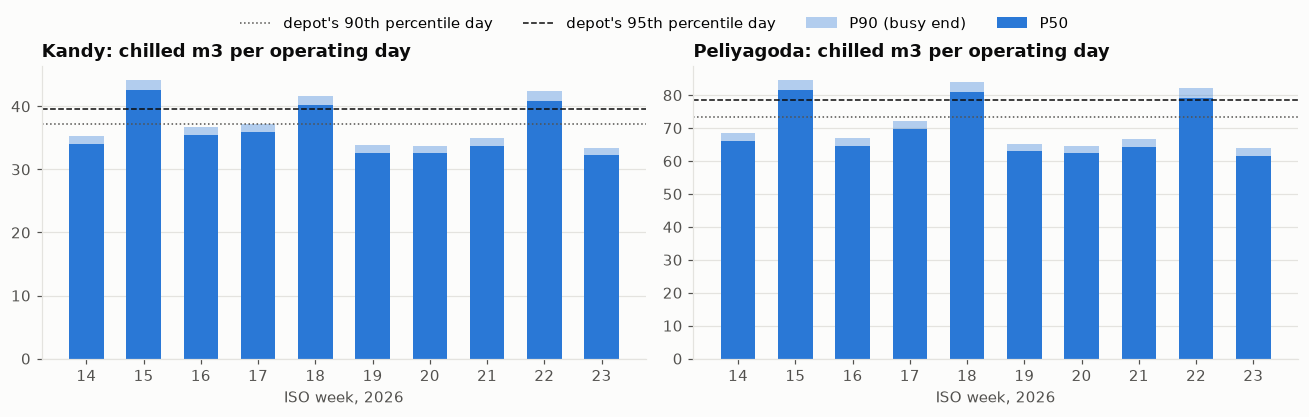

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (depot, g) in zip(axes, outlook.groupby("depot")):
    ax.bar(g.iso_week, g.m3_per_day_p90, color=SERIES[0], alpha=0.35, width=0.6, label="P90 (busy end)")
    ax.bar(g.iso_week, g.m3_per_day_p50, color=SERIES[0], width=0.6, label="P50")
    ax.axhline(g.busy_day_p90.iloc[0], color=INK_SOFT, linewidth=1, linestyle=":", label="depot's 90th percentile day")
    ax.axhline(g.busy_day_p95.iloc[0], color=INK, linewidth=1, linestyle="--", label="depot's 95th percentile day")
    ax.set_title(f"{depot}: chilled m3 per operating day")
    ax.set_xlabel("ISO week, 2026")
    ax.set_xticks(g.iso_week)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.06))
plt.tight_layout(); plt.show()

Three weeks stand out at both depots: week 15 before New Year, week 18 with Vesak and week 22 with Poson. In each, the busy end of a day is above all but the busiest 5% of days the depot has handled, so no reefer should go into the workshop then. The weeks around them, including the short festival week 16, carry normal loads and are the natural window for reefer maintenance. This is scenario S1 seen weeks ahead: a peak day with reefers in the workshop is exactly what Part 8 had to plan around.

### Part 9 summary

- **Every model output now ends in an action.** Late risk becomes a red, amber or green light with a reason and a fix; arrival bands become clock ranges; the peak-day plan becomes loading sheets, deferral notices and early warnings; the demand forecast becomes a reefer maintenance calendar.
- **The thresholds mean something.** Because the late-risk blend is calibrated, red means at least half of such stops run late.
- **Reasons come from the model, in plain words.** Each red stop's reason line is built from the features that pushed its risk up the most.
- **All sample outputs are saved** in `reports/decision_layer/` as CSV files, ready for the dispatcher screen, loader tablets, driver phones and store messaging.

Part 10 sets out how Waypoint would run all of this, and Part 11 reloads the saved models to prove they reproduce the submissions.

## Part 10. Deployment, impact and limits

### 10.1 How Waypoint would run this

Nothing here needs a real-time system. Waypoint plans once a day at the 4 PM cutoff and reviews capacity weekly, so three scheduled jobs on one small server are enough:

| Job | When | What it does | Runtime |
|---|---|---|---|
| Daily risk run | 4 PM, after the cutoff | scores tomorrow's draft routes with the Task 1 models and writes arrival ranges, lights and reasons to the planning database | seconds |
| Peak-day planner | on demand, when orders exceed capacity | runs the Task 2B optimiser and returns the allocation, deferral prices and late warnings | minutes |
| Weekly outlook | Monday morning | refits the Task 2A models with last week's orders and publishes the 10-week volume and reefer outlook | minutes |

The outputs reach people where they already work: the dispatcher's planning screen, a loading sheet on the loader's tablet, a run sheet downloaded to the driver's phone before leaving the depot (so it works without signal), and an SMS or WhatsApp message to each store manager.

**Keeping it honest.** Every morning the job compares yesterday's predictions with what actually happened: service time error, calibration of the late risk (do 30% stops run late 3 times in 10?), and forecast error per week. Models are retrained monthly, or sooner when an error drifts past its threshold. Every model file is versioned and listed in `models/manifest.json` with its training window, seed and holdout scores, so any prediction can be traced back to the model that made it.

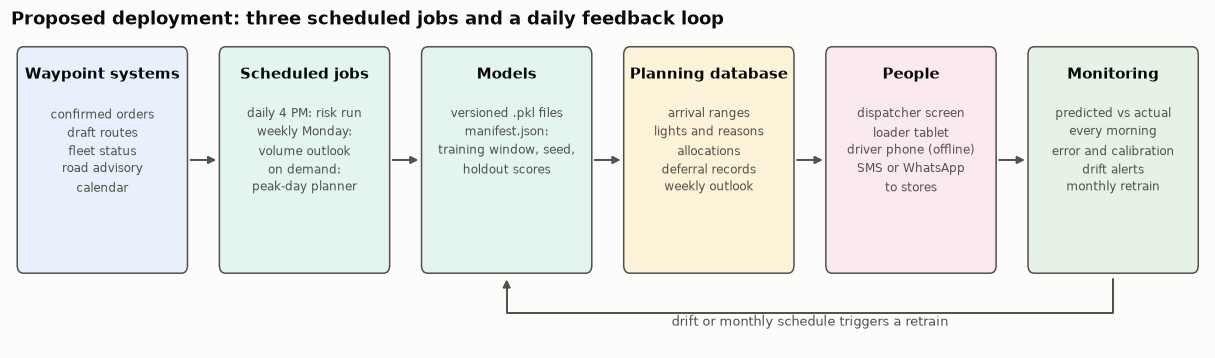

In [124]:
deployment = flow([
    ("Waypoint systems", ["confirmed orders", "draft routes", "fleet status", "road advisory", "calendar"], LIGHT[0]),
    ("Scheduled jobs", ["daily 4 PM: risk run", "weekly Monday:", "volume outlook", "on demand:", "peak-day planner"], LIGHT[2]),
    ("Models", ["versioned .pkl files", "manifest.json:", "training window, seed,", "holdout scores"], LIGHT[2]),
    ("Planning database", ["arrival ranges", "lights and reasons", "allocations", "deferral records", "weekly outlook"], LIGHT[3]),
    ("People", ["dispatcher screen", "loader tablet", "driver phone (offline)", "SMS or WhatsApp", "to stores"], LIGHT[4]),
    ("Monitoring", ["predicted vs actual", "every morning", "error and calibration", "drift alerts", "monthly retrain"], LIGHT[5]),
], figsize=(14, 3.7), title="Proposed deployment: three scheduled jobs and a daily feedback loop",
   loop=(5, 2, "drift or monthly schedule triggers a retrain"))
deployment.savefig(REPO_ROOT / "docs" / "figures" / "architecture_deployment.png", dpi=160, bbox_inches="tight")
plt.show()

### 10.2 What it is worth to Waypoint

- **Better routes before the trucks leave.** Today's allowance table misses each stop's handling time by about 7 minutes; ours misses by about 4. The dispatcher's board points at a fifth of stops that hold most of the expected late arrivals, each with a reason and a fix, the evening before.
- **No more surprises in festival weeks.** The forecast puts the New Year, Vesak and Poson peaks in their 2026 weeks, where copying last year would not. The reefer outlook flags weeks 15, 18 and 22 at both depots as the weeks when no reefer should be in the workshop.
- **A defensible peak-day plan.** Every deferral has a reason code and a price. No store misses two days in a row, and the plan proves no other valid plan serves more chilled goods. When a store manager asks why, the dispatcher has an answer, not an apology.
- **Fewer wasted trips.** The workshop repair ranking says which reefer to release first: one large reefer truck recovers about 35 m3 of chilled goods on a day like S1.

### 10.3 Limits, stated plainly

- **The planning standard is optimistic.** Waypoint's free-flow drive times leave out the drive back between trips and store opening times. Our Task 2B plan follows the standard, as required, but the clock replay in Part 8 shows five stops that a second reefer run would reach after opening. We flag them rather than hide them.
- **Late risk is only as good as the advisory.** The road disruption index is the strongest single signal after slack. If Waypoint stops receiving it before the cutoff, the late-risk models must be refit without it (Part 6 shows the cost).
- **Forecast ranges are a little narrow.** The P10 to P90 bands cover about 76% of backtest weeks against a target of 80%, so the reefer outlook already plans on the P90.
- **Test labels were hidden.** All accuracy figures come from a holdout built to look like the test period, with history frozen the same way. They are honest estimates, not test scores.

## Part 11. Reload the saved models and run inference

This is the check a deployment would run. Everything below starts from the files in `models/` and the raw test inputs, not from variables earlier in this notebook. It runs Task 1 and Task 2A inference, prints sample inputs next to their predictions, and confirms the predictions match the submission files exactly. It then recomputes the results-at-a-glance table.

In [125]:
manifest = json.loads((MODELS / "manifest.json").read_text())
print("Model files:", {task: info["files"] for task, info in manifest.items()})

# Task 1: rebuild the cutoff-time features for the test stops and replay every route
stops_t1 = load_processed("stops")
ref = dict(outlets=load_processed("outlets"), vehicles=load_processed("vehicles"), allowance=load_processed("service_allowance"),
           calendar=load_processed("calendar"), road=load_processed("road_conditions"), traffic=load_processed("traffic_speed"))
frame = fe.model_frame(stops_t1, fe.build_task1_features(stops_t1, **ref))
test_stops = frame[frame.split == "test"]

simulator = joblib.load(MODELS / manifest["task1"]["files"][0])
classifier = joblib.load(MODELS / manifest["task1"]["files"][1])
replay = simulator.simulate(test_stops)
p_clf = classifier.predict_proba(test_stops[classifier.feature_name_])[:, 1]
task1_pred = pd.DataFrame({
    "delivery_id": test_stops.delivery_id.to_numpy(),
    "pred_service_min": replay.pred_service_min.round(2).to_numpy(),
    "pred_late_prob": np.clip((replay.sim_late_prob.to_numpy() + p_clf) / 2, 0.002, 0.998).round(4),
})

task1_inputs = load_raw("task1_test_inputs.csv")
sample = task1_inputs.sample(5, random_state=SEED).merge(task1_pred, on="delivery_id")
print("\nTask 1: sample test inputs and predictions")
display(sample[["delivery_id", "outlet_id", "brand", "district", "temp_requirement", "order_volume_m3",
                "window_open_time", "window_close_time", "pred_service_min", "pred_late_prob"]])

submitted = pd.read_csv(SUBMISSIONS / "submission_task1.csv").merge(task1_pred, on="delivery_id", suffixes=("_file", "_now"))
print(f"Task 1 rows: {len(submitted):,}. Largest difference from submission_task1.csv: "
      f"service {np.abs(submitted.pred_service_min_file - submitted.pred_service_min_now).max():.3f} min, "
      f"late risk {np.abs(submitted.pred_late_prob_file - submitted.pred_late_prob_now).max():.4f}")

Model files: {'task1': ['route_simulator.pkl', 'late_classifier.pkl'], 'task2a': ['demand_regression.pkl', 'demand_calendar_gbm.pkl']}



Task 1: sample test inputs and predictions


,delivery_id,outlet_id,brand,district,temp_requirement,order_volume_m3,window_open_time,window_close_time,pred_service_min,pred_late_prob
0,ORD0097205,OUT002,Fresh,Colombo,ambient,0.675,05:30,08:00,12.55,0.9409
1,ORD0093336,OUT050,Fresh,Galle,ambient,2.078,05:30,08:00,10.87,0.0040
2,ORD0095518,OUT117,Fresh,Kegalle,ambient,3.477,04:00,07:45,21.54,0.7879
3,ORD0095218,OUT105,Fresh,Nuwara Eliya,chilled,0.821,05:00,07:30,8.21,0.0160
4,ORD0096725,OUT069,Fresh,Kurunegala,ambient,1.775,05:30,08:00,12.35,0.1707


Task 1 rows: 5,014. Largest difference from submission_task1.csv: service 0.000 min, late risk 0.0000


In [126]:
# Task 2A: forecast every day from 30 March to 7 June 2026, then add the days up into ISO weeks
reg = joblib.load(MODELS / manifest["task2a"]["files"][0])
gbm = joblib.load(MODELS / manifest["task2a"]["files"][1])
inputs_2a = load_raw("task2a_test_inputs.csv")
series = pd.DataFrame([(d, b, m) for d, b in inputs_2a[["depot", "brand"]].drop_duplicates().itertuples(index=False)
                       for m in (["total", "chilled"] if b == "Fresh" else ["total"])], columns=fc.SERIES_KEYS)
start, end = manifest["task2a"]["forecast_days"].split(" to ")
days = fc.future_panel(series, load_processed("calendar"), pd.Timestamp(start), pd.Timestamp(end))
days["p50"] = (reg.predict(days) + gbm.predict(days)) / 2
weeks = fc.to_weeks(days, ["p50"]).pivot_table(index=["depot", "brand", "iso_year", "iso_week"], columns="measure", values="p50").reset_index()

pred_2a = inputs_2a.merge(weeks, on=["depot", "brand", "iso_year", "iso_week"], how="left")
pred_2a["pred_total_volume_m3"] = pred_2a["total"].round(3)
pred_2a["pred_chilled_volume_m3"] = np.where(pred_2a.brand == "Fresh", np.minimum(pred_2a["chilled"].fillna(0), pred_2a["total"]), 0.0).round(3)
print("Task 2A: sample test inputs and predictions")
display(pred_2a.sample(5, random_state=SEED)[["row_id", "depot", "brand", "iso_year", "iso_week",
                                              "pred_total_volume_m3", "pred_chilled_volume_m3"]])

file_2a = pd.read_csv(SUBMISSIONS / "submission_task2a.csv").merge(pred_2a, on="row_id", suffixes=("_file", "_now"))
print(f"Task 2A rows: {len(file_2a)}. Largest difference from submission_task2a.csv: "
      f"total {np.abs(file_2a.pred_total_volume_m3_file - file_2a.pred_total_volume_m3_now).max():.3f} m3, "
      f"chilled {np.abs(file_2a.pred_chilled_volume_m3_file - file_2a.pred_chilled_volume_m3_now).max():.3f} m3")

Task 2A: sample test inputs and predictions


,row_id,depot,brand,iso_year,iso_week,pred_total_volume_m3,pred_chilled_volume_m3
0,W0000,Kandy,Fresh,2026,14,554.478,204.367
5,W0005,Peliyagoda,Tech,2026,14,35.538,0.000
36,W0036,Kandy,Fresh,2026,20,524.455,195.337
45,W0045,Peliyagoda,Fresh,2026,21,1037.420,385.474
13,W0013,Kandy,Style,2026,16,52.470,0.000


Task 2A rows: 60. Largest difference from submission_task2a.csv: total 0.000 m3, chilled 0.000 m3


In [127]:
# Task 2B: the submitted plan, checked once more with Waypoint's own checker
check = subprocess.run([sys.executable, "check_allocation.py", str(SUBMISSIONS / "submission_task2b.csv")],
                       cwd=REPO_ROOT, capture_output=True, text=True)
print(check.stdout.strip())

plan_2b = load_processed("task2b_plan")
served_2b = plan_2b[plan_2b.decision == "served"]
board_2b = load_processed("task2b_deferrals")

FEASIBILITY: PASSED - every rule satisfied.


In [128]:
# The results-at-a-glance table, recomputed from the saved files
t1, t2 = manifest["task1"]["holdout"], manifest["task2a"]["backtest_blend"]
chilled_served = served_2b.loc[served_2b.temp_requirement == "chilled", "order_volume_m3"].sum()
lights = pd.read_csv(SUBMISSIONS / "submission_task1.csv").pred_late_prob.map(dl.light)
p_late = pd.read_csv(SUBMISSIONS / "submission_task1.csv").pred_late_prob
glance = pd.DataFrame([
    ("Task 1", "service time error a stop (min)", f"{t1['allowance_table_MAE']:.1f}", f"{t1['service']['MAE']:.1f}"),
    ("Task 1", "late risk log loss / AUC", "0.287 / 0.86", f"{t1['late']['log loss']:.3f} / {t1['late']['AUC']:.2f}"),
    ("Task 2A", "weekly error, total / chilled", "", f"{t2['total']['WAPE']:.1%} / {t2['chilled']['WAPE']:.1%}"),
    ("Task 2A", "error compared with last year's pattern", "100%", f"{t2['total']['vs last year']:.0%} / {t2['chilled']['vs last year']:.0%}"),
    ("Task 2B", "orders served", "", f"{len(served_2b)} of {len(plan_2b)}"),
    ("Task 2B", "repeat deferrals served", "", f"{int(served_2b.deferred_yesterday.sum())} of {int(plan_2b.deferred_yesterday.sum())}"),
    ("Task 2B", "chilled m3 served", "", f"{chilled_served:.1f}"),
    ("People", "red stops / their share of expected late arrivals", "",
     f"{(lights == 'red').mean():.0%} / {p_late[lights == 'red'].sum() / p_late.sum():.0%}"),
], columns=["task", "measure", "Waypoint today", "ours"])
glance

,task,measure,Waypoint today,ours
0,Task 1,service time error a stop (min),7.1,3.9
1,Task 1,late risk log loss / AUC,0.287 / 0.86,0.136 / 0.97
2,Task 2A,"weekly error, total / chilled",,5.2% / 3.6%
3,Task 2A,error compared with last year's pattern,100%,59% / 46%
4,Task 2B,orders served,,76 of 85
5,Task 2B,repeat deferrals served,,10 of 10
6,Task 2B,chilled m3 served,,132.6
7,People,red stops / their share of expected late arrivals,,21% / 82%


The saved models reproduce both submission files from the raw test inputs, the Task 2B file passes Waypoint's checker, and every headline number at the top of this notebook comes back from the saved files. Everything is in place to hand over.